In [24]:
import scipy.io
import io

from data_loader import DataLoader

import numpy as np
from utils import *
from matplotlib import pyplot as plt
import numpy.random as rng
import pandas as pd

import os
import math

In [25]:
home_dir = os.path.abspath(os.path.curdir)
data_dir = os.path.join(home_dir, '..', 'Data')
ultralight = os.path.join(data_dir, 'GG-Dataset-Tulio-Ultralight')

print(os.path.abspath(home_dir))
print(os.path.abspath(data_dir))
print(os.path.abspath(ultralight))

/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/GG-Dataset-Tulio-Ultralight


In [26]:
def load_data(rats):
    return DataLoader(data_dir, 'Hpc', rats=[rats])
    
rats = ['Rat08', 'Rat09', 'Rat10', 'Rat11']
rat_id = 2
rat = rats[rat_id] 
area ='all'

#load data
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat10/Rat10-20140704/Rat10-20140704-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat10/Rat10-20140704/Rat10-20140704-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


**Preprocessing functions**

In [27]:
def session_variable(session_idx):
    sessions_data = list(data.events[rat].keys())
    sessions_spks = list(spks[rat].keys()) 

    sessions = np.intersect1d(sessions_spks, sessions_data)
    sessions.sort()
    session = sessions[session_idx]

    session_neurons = spks[rat][session][area]
    neuron_ids = list(spks[rat][session][area].keys())
    n_neurons = len(neuron_ids)

    begin_run_i = int(list(data.events[rat][session]['cat']['data']).index('beginning run'))
    end_run_i = int(list(data.events[rat][session]['cat']['data']).index('end run'))

    begin_run_t = int(list(data.events[rat][session]['cat']['ts'])[begin_run_i])
    end_run_t = int(list(data.events[rat][session]['cat']['ts'])[end_run_i])
    
    return neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t

In [28]:
def position_variable(session):
    x = data.position[rat][session]['x']
    y = data.position[rat][session]['y']
    time_location = data.position[rat][session]['Time']

    # location_run_idx = [index for index, t in enumerate(time_location) if t > begin_run_t and t < end_run_t]

    # x_run = x[location_run_idx[0]:location_run_idx[-1]]
    # y_run = y[location_run_idx[0]:location_run_idx[-1]]
    run_indices = (time_location >= begin_run_t) & (time_location <= end_run_t)
    x_run = x[run_indices]
    y_run = y[run_indices]
    time_run = time_location[run_indices]

    # Find the puff events and location
    puff_events_ = data.events[rat][session]['puf']['ts']
    puff_events = []
    
    # Make sure the puff events are an int format (some sessions consist of strings)
    if isinstance(list(puff_events_)[0], str):
        for t in np.array(puff_events_):
            puff_events.append(float(t[:14]))
    else:
        puff_events = puff_events_

    # Filter puff events to run session
    puff_events = [t for t in puff_events if t > begin_run_t and t < end_run_t]
    
    
    puff_x_location = [x_run[np.absolute(time_location-i).argmin()] for i in puff_events]
    puff_y_location = [y_run[np.absolute(time_location-i).argmin()] for i in puff_events]

    # Find the mean of the puff location
    x_mean = np.mean(puff_x_location)

    return x, y, time_location, x_run, y_run, time_run, puff_events, puff_x_location, puff_y_location, x_mean

In [29]:
def preprocess_rewards(left_reward_ts_, right_reward_ts_, begin_run_t, end_run_t, time_run):
    def process_timestamps(raw_ts):
        """
        Process and filter timestamps, keeping the indices of the rewards within the time_loc range.
        """
        processed_ts_with_indices = []
        # Ensure all timestamps are floats
        if isinstance(raw_ts[0], str):
            raw_ts = [float(t[:14]) for t in raw_ts]
        
        # Keep timestamps within the time range
        for reward_ts in raw_ts:
            if begin_run_t <= reward_ts <= end_run_t:
                # Find the index of the time_loc closest to the reward timestamp
                closest_idx = np.abs(time_run - reward_ts).argmin()
                processed_ts_with_indices.append((reward_ts, closest_idx))  # Tuple of (reward timestamp, index in time_loc)
        
        return processed_ts_with_indices

    # Process left and right reward timestamps
    left_reward_ts = process_timestamps(left_reward_ts_)
    right_reward_ts = process_timestamps(right_reward_ts_)

    return left_reward_ts, right_reward_ts

In [30]:
def get_test_and_train_runs(safe_runs_matrix):
    train_runs = []
    test_runs = []
    
    for i, val in enumerate (safe_runs_matrix):
        if i % 2:
            train_runs.append(safe_runs_matrix[i])
        else :
            test_runs.append(safe_runs_matrix[i])
        train_runs_matrix = np.array(train_runs)
        test_runs_matrix = np.array(test_runs)
    return train_runs_matrix, test_runs_matrix

**First try at looping**

In [31]:
%run Preprocessing_Track_Data_Functions.ipynb
%run MI_Analysis_and_Sequence_Function.ipynb

In [14]:
sessions = spks[rats[rat_id]].keys() #get the keys of the dictionary spks
content = spks[rats[rat_id]].values() #values of the dictionary spks
# print(sessions)


sessions_data = list(data.events[rat].keys())
sessions_spks = list(spks[rat].keys()) 

sessions = np.intersect1d(sessions_spks, sessions_data)

In [32]:
spk_sessions = list(spks[rats[rat_id]].keys()) #get the keys of the dictionary spks
data_sessions = list(data.events[rat].keys())
union_sessions = list(set(spk_sessions) | set(data_sessions))
print(len(union_sessions))

15


In [128]:
# Initialize an empty list to store matrices
session_matrices = []
valid_sessions = np.zeros(len(sessions))
session_attributes = []
n_iterations= 500
n_neurons_session = []

In [135]:
def plot_safe_runs_with_middle(safe_runs_with_middle, x_run, time_run):
    left_reward_x = get_x_values_from_idx(x_run, safe_runs_with_middle[:, 1])
    right_reward_x = get_x_values_from_idx(x_run, safe_runs_with_middle[:, 5])
    middle_x = calculate_middle_x(left_reward_x, right_reward_x)
    #plot the left, right and middle points
    plt.scatter(safe_runs_with_middle[:, 0], left_reward_x, color='green', label="Left Reward", zorder=5)
    plt.scatter(safe_runs_with_middle[:, 4], right_reward_x, color='red', label="Right Reward", zorder=5)
    plt.scatter(safe_runs_with_middle[:, 2], middle_x, color='orange', label="Middle of track", zorder=5)
    #plot airpuffs as a check
    # plt.scatter(puff_ts, puff_x_location, color='yellow', s=50, label="Airpuff Events")

    for i,val in enumerate(safe_runs_with_middle):
        start_idx = safe_runs_with_middle[i][1]
        end_idx = safe_runs_with_middle[i][5]
        plt.plot(time_run[start_idx: end_idx], x_run.iloc[start_idx:end_idx], color='blue', alpha=0.6, lw=2)

    plt.title('X-Location Over Time with Safe Reward Intervals and Middle of the Track')
    plt.xlabel('Time (ms)')
    plt.ylabel('X-Location')
    plt.legend(bbox_to_anchor =(0.8, -0.13), ncol = 2)


In [136]:
session_data_rat10_middle_split= {}
for i in range(2,11):
    # Initialize variables for session
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    n_neurons_session.append(n_neurons)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_middle = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_middle = safe_runs_with_middle(safe_runs_without_middle, x_run)
    plot_safe_runs_with_middle(safe_runs_WITH_middle, x_run, time_run)
    if session == 'Rat10-20140622':
        plt.savefig('Example_track.svg')
    plt.close()
    session_matrices.append(safe_runs_WITH_middle)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_middle)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat10_middle_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }

for i in range(13,15):
    # Initialize variables for session
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_middle = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_middle = safe_runs_with_middle(safe_runs_without_middle, x_run)
    # plot_safe_runs_with_middle(safe_runs_WITH_middle, x_run, time_run)
    session_matrices.append(safe_runs_WITH_middle)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_middle)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat10_middle_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }

Rat10-20140622
Rat10-20140624
Rat10-20140626
Rat10-20140627
Rat10-20140628
Rat10-20140629
Rat10-20140701
Rat10-20140702
Rat10-20140703
Rat10-20140707
Rat10-20140708


In [138]:

with open("rat10_session_data_middle.pkl", "wb") as pkl_file:
    pickle.dump(session_data_rat10_middle_split, pkl_file)

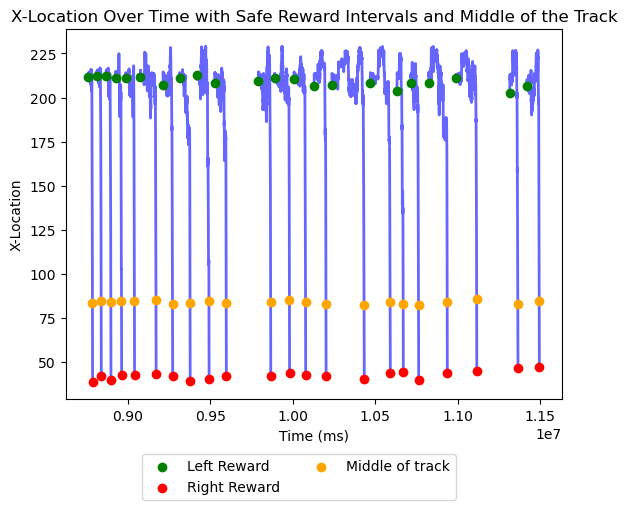

Rat10-20140622


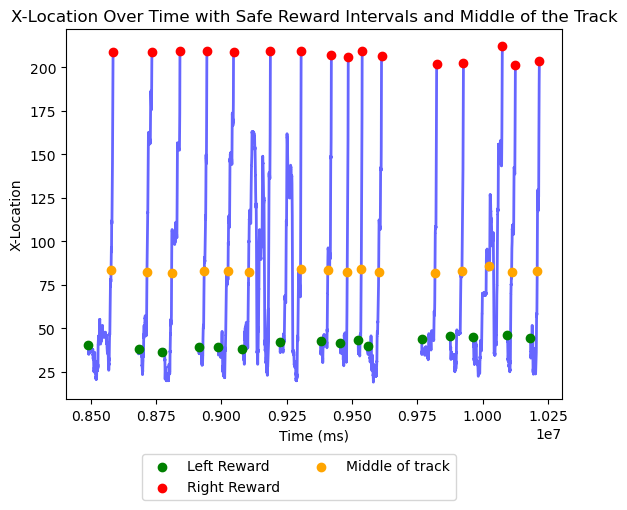

Rat10-20140624


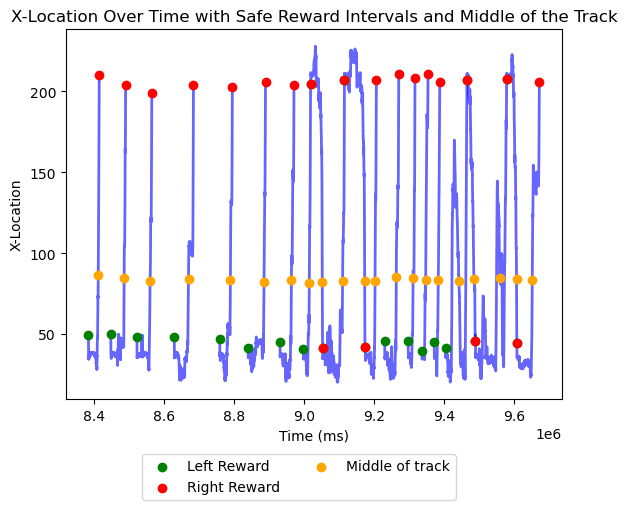

Rat10-20140626


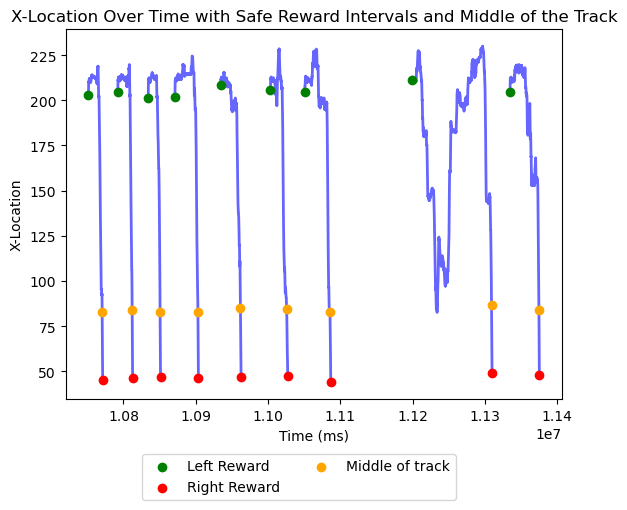

Rat10-20140627


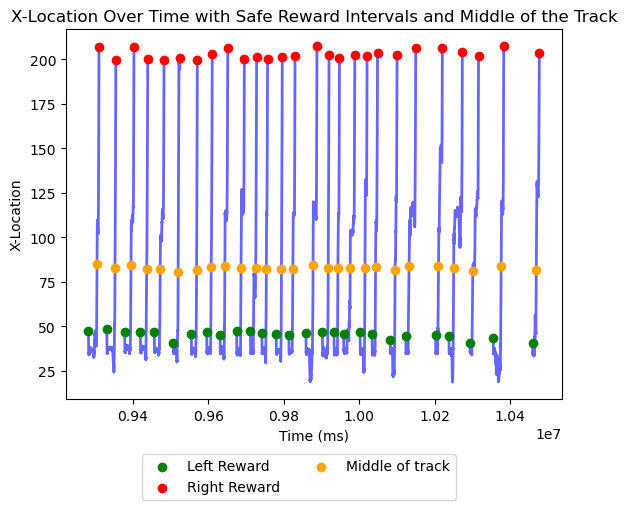

Rat10-20140628


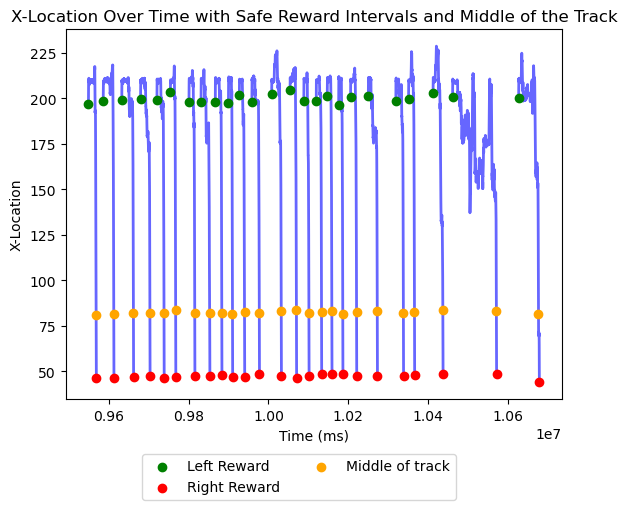

Rat10-20140629


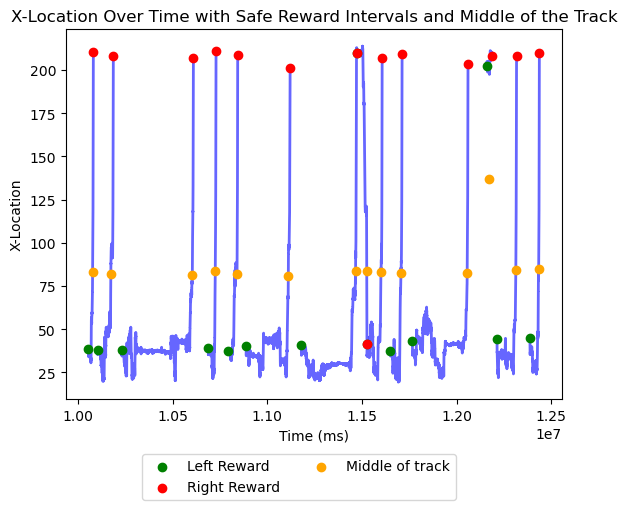

Rat10-20140701


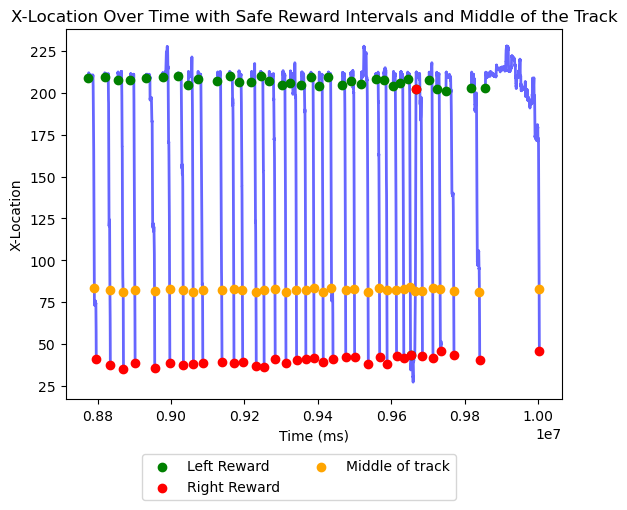

Rat10-20140702


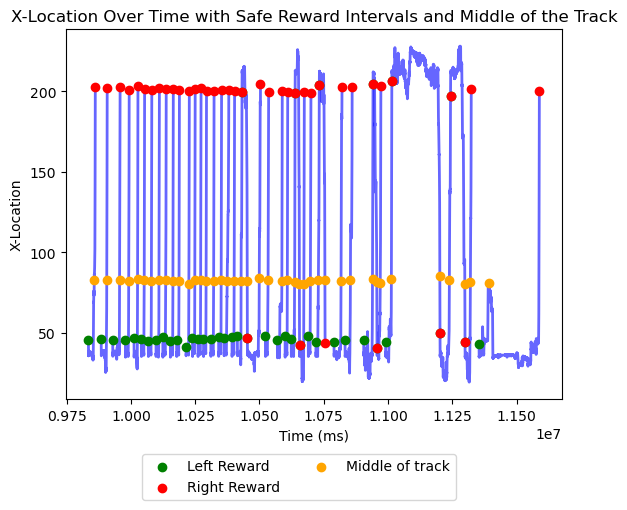

Rat10-20140703


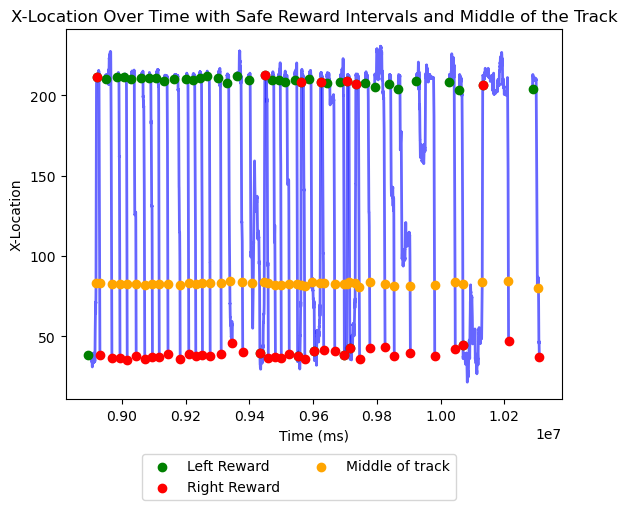

Rat10-20140707


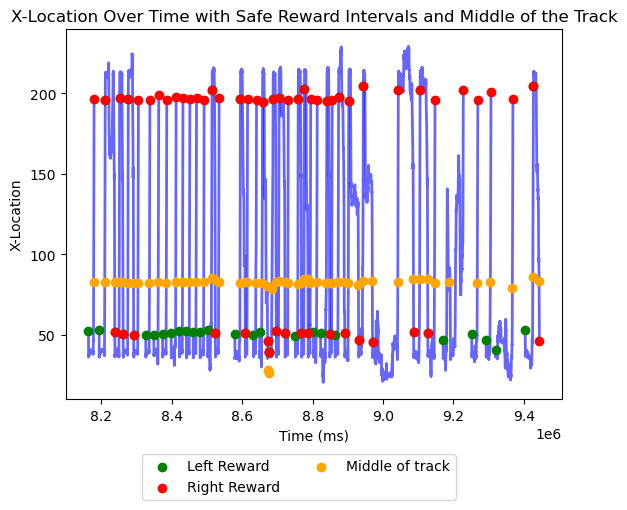

Rat10-20140708


In [34]:
session_data_rat10_third_split= {}
for i in range(2,11):
    # Initialize variables for session
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_third = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_third = safe_runs_with_third(safe_runs_without_third, x_run)
    plot_safe_runs_with_third(safe_runs_WITH_third, x_run, time_run)
    session_matrices.append(safe_runs_WITH_third)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_third)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat10_third_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }
for i in range(13,15):
    # Initialize variables for session
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_third = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_third = safe_runs_with_third(safe_runs_without_third, x_run)
    plot_safe_runs_with_third(safe_runs_WITH_third, x_run, time_run)
    session_matrices.append(safe_runs_WITH_third)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_third)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat10_third_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }

 


In [32]:
results_per_session_rat10_middle_split = {}

In [33]:
for session, matrices in session_data_rat10_middle_split.items():
    print(f'Analyzing session {session}')
    test_matrix = matrices["test_matrix"]
    train_matrix = matrices["train_matrix"]
    n_neurons = matrices ["n_neurons"]
    neuron_ids = matrices ["neuron_ids"]
    session_neurons = matrices["session_neurons"]
    
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    
    occ, mi_real, surrogates, boundary = compute_mi_occ_surrogates_per_neuron(spk_matrix_train, 120, 500)
    
    results_per_session_rat10_middle_split[session] = {
        "occ": occ,
        "mi_real": mi_real,
        "surrogates": surrogates,
        "boundary": boundary
    }
    print(f'On to next session')

Analyzing session Rat10-20140622
Analyzing neuron 0 of 31
Computed ranks, occ, mi and surrogates for  0 of 31
Analyzing neuron 1 of 31
Computed ranks, occ, mi and surrogates for  1 of 31
Analyzing neuron 2 of 31
Computed ranks, occ, mi and surrogates for  2 of 31
Analyzing neuron 3 of 31
Computed ranks, occ, mi and surrogates for  3 of 31
Analyzing neuron 4 of 31
Computed ranks, occ, mi and surrogates for  4 of 31
Analyzing neuron 5 of 31
Analyzing neuron 6 of 31
Computed ranks, occ, mi and surrogates for  6 of 31
Analyzing neuron 7 of 31
Computed ranks, occ, mi and surrogates for  7 of 31
Analyzing neuron 8 of 31
Computed ranks, occ, mi and surrogates for  8 of 31
Analyzing neuron 9 of 31
Computed ranks, occ, mi and surrogates for  9 of 31
Analyzing neuron 10 of 31
Computed ranks, occ, mi and surrogates for  10 of 31
Analyzing neuron 11 of 31
Computed ranks, occ, mi and surrogates for  11 of 31
Analyzing neuron 12 of 31
Computed ranks, occ, mi and surrogates for  12 of 31
Analyzing ne

In [35]:
results_per_session_rat10_third_split = {}

In [122]:
for session, matrices in session_data_rat10_third_split.items():
    print(f'Analyzing session {session}')
    test_matrix = matrices["test_matrix"]
    train_matrix = matrices["train_matrix"]
    n_neurons = matrices ["n_neurons"]
    neuron_ids = matrices ["neuron_ids"]
    session_neurons = matrices["session_neurons"]
    
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    
    occ, mi_real, surrogates, boundary = compute_mi_occ_surrogates_per_neuron(spk_matrix_train, 120, 500)
    
    results_per_session_rat10_third_split[session] = {
        "occ": occ,
        "mi_real": mi_real,
        "surrogates": surrogates,
        "boundary": boundary
    }
    print(f'On to next session')

Analyzing session Rat10-20140622
Analyzing neuron 0 of 31
Computed ranks, occ, mi and surrogates for  0 of 31
Analyzing neuron 1 of 31
Computed ranks, occ, mi and surrogates for  1 of 31
Analyzing neuron 2 of 31
Computed ranks, occ, mi and surrogates for  2 of 31
Analyzing neuron 3 of 31
Computed ranks, occ, mi and surrogates for  3 of 31
Analyzing neuron 4 of 31
Computed ranks, occ, mi and surrogates for  4 of 31
Analyzing neuron 5 of 31
Analyzing neuron 6 of 31
Computed ranks, occ, mi and surrogates for  6 of 31
Analyzing neuron 7 of 31
Computed ranks, occ, mi and surrogates for  7 of 31
Analyzing neuron 8 of 31
Computed ranks, occ, mi and surrogates for  8 of 31
Analyzing neuron 9 of 31
Computed ranks, occ, mi and surrogates for  9 of 31
Analyzing neuron 10 of 31
Computed ranks, occ, mi and surrogates for  10 of 31
Analyzing neuron 11 of 31
Computed ranks, occ, mi and surrogates for  11 of 31
Analyzing neuron 12 of 31
Computed ranks, occ, mi and surrogates for  12 of 31
Analyzing ne

Rat10-20140622


/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6350/3435664888.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6350/3435664888.py:8: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')


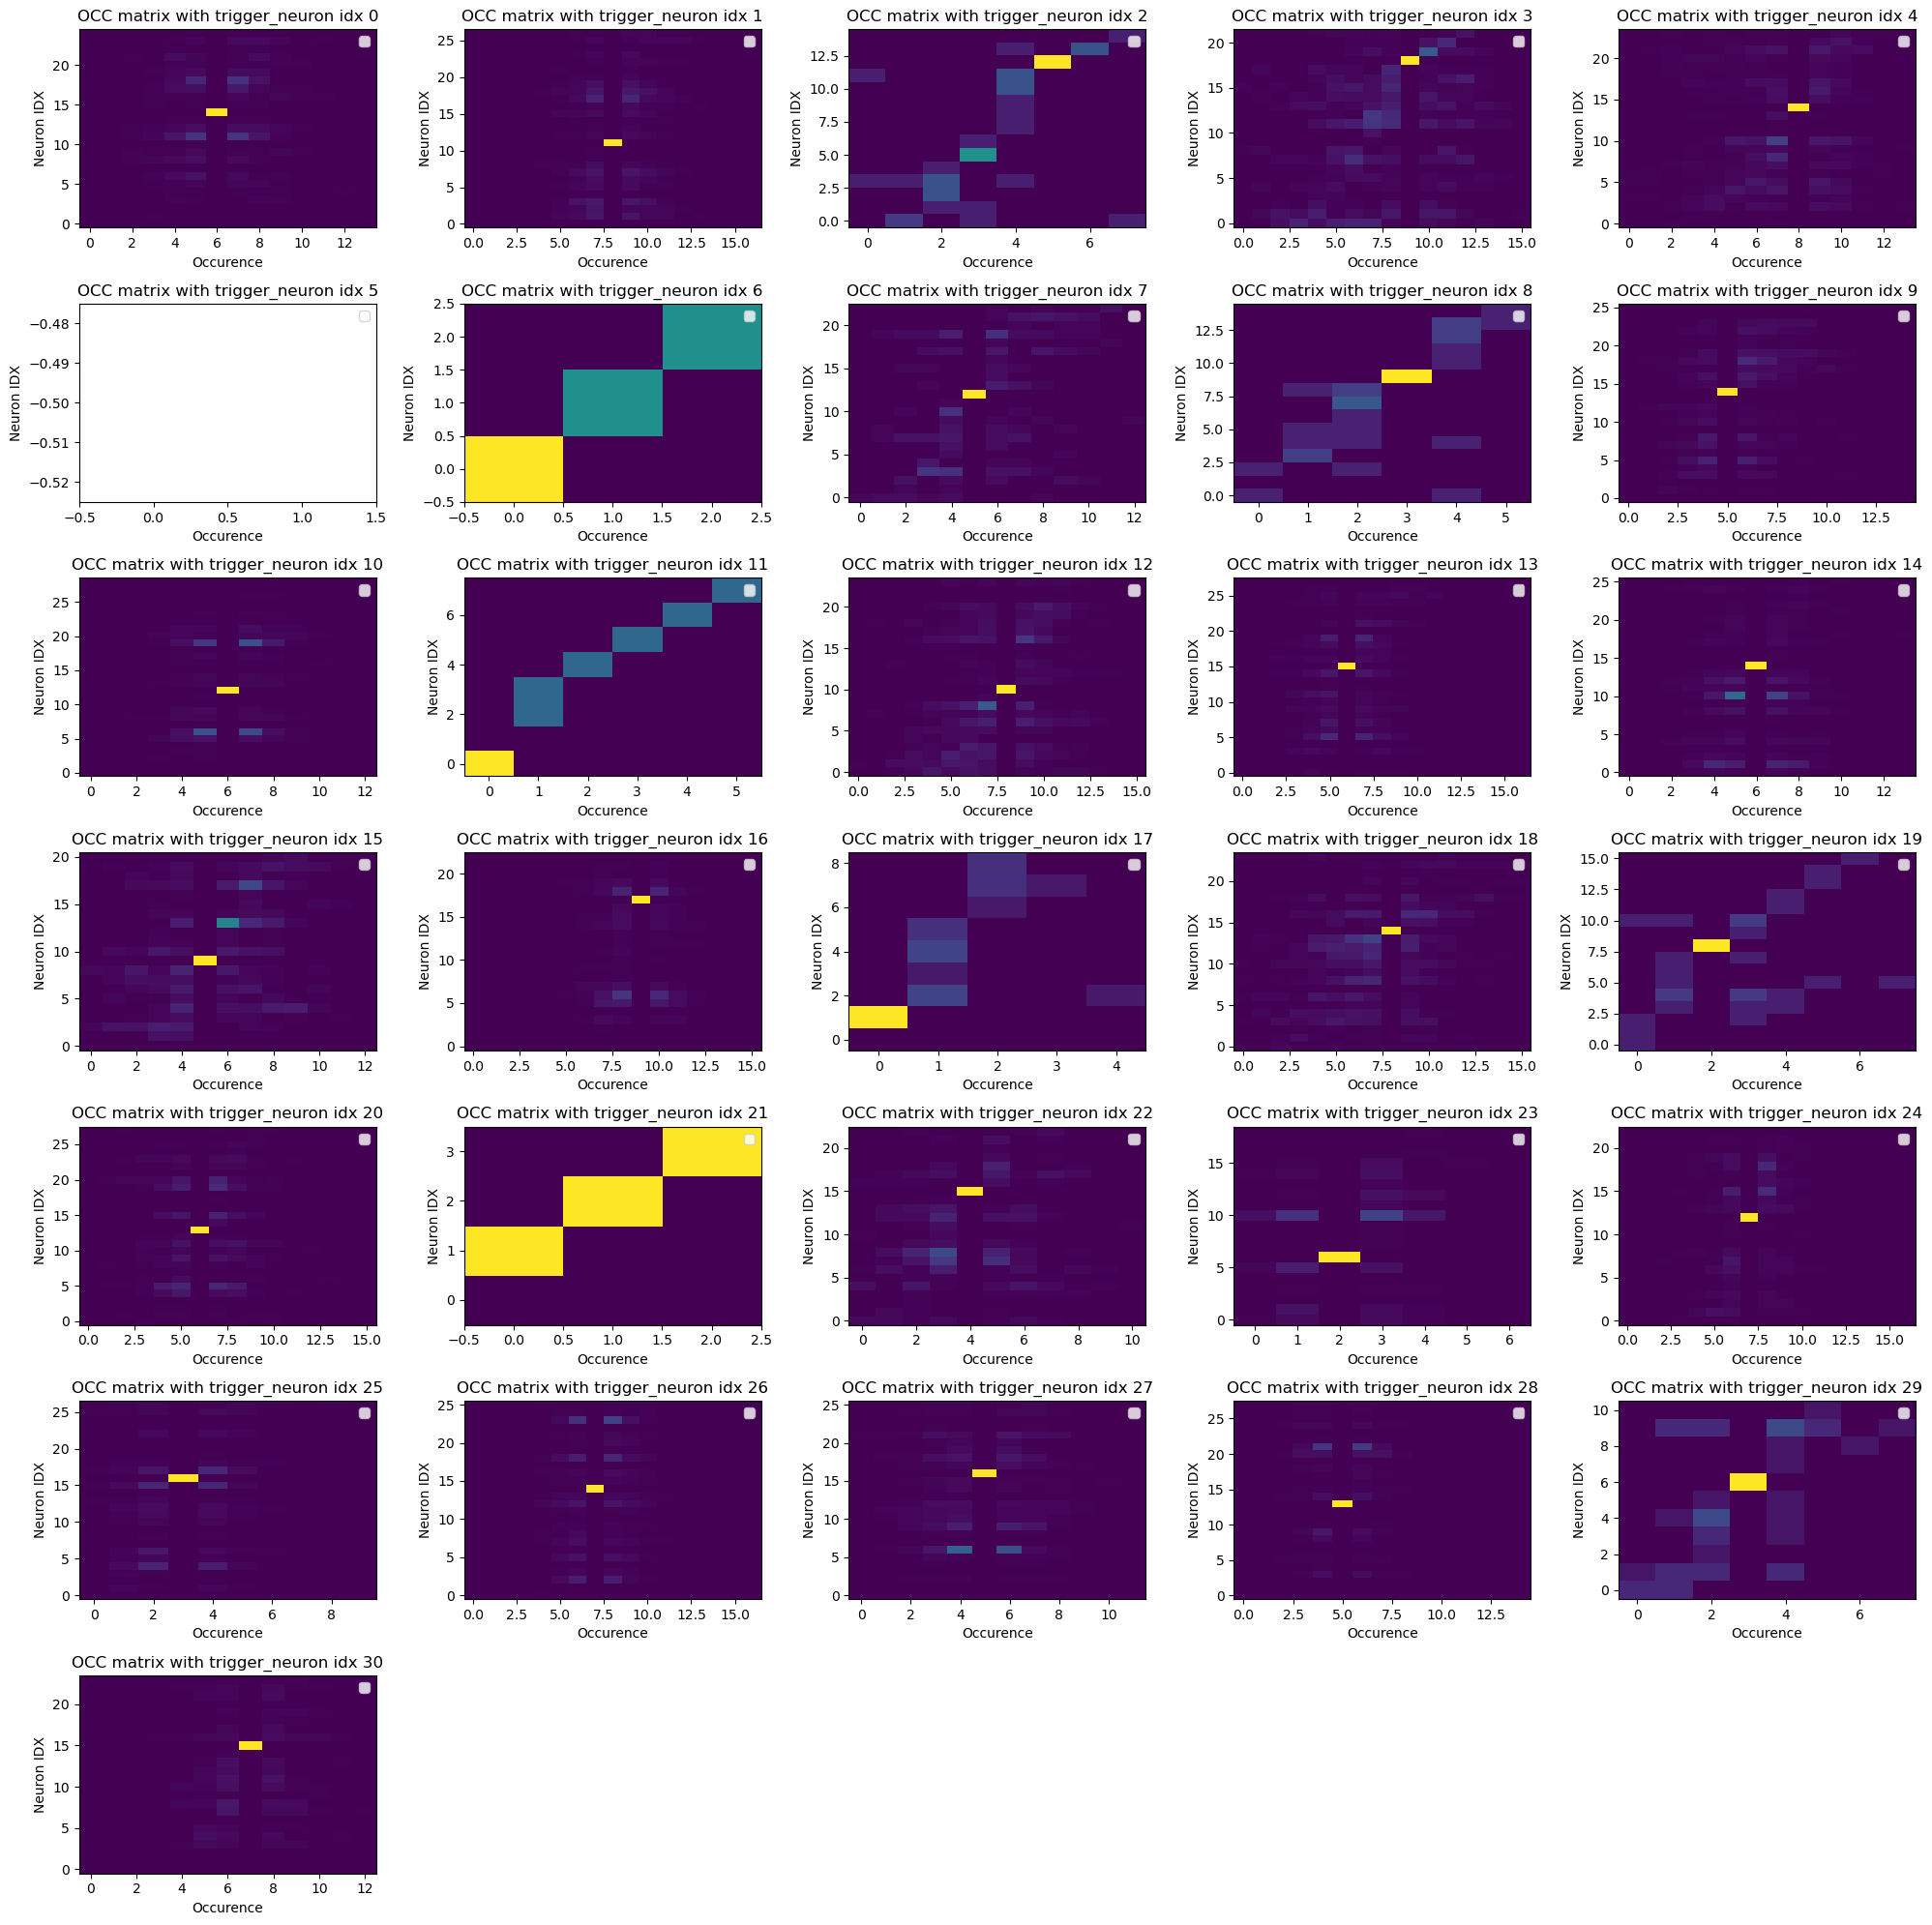

Rat10-20140624


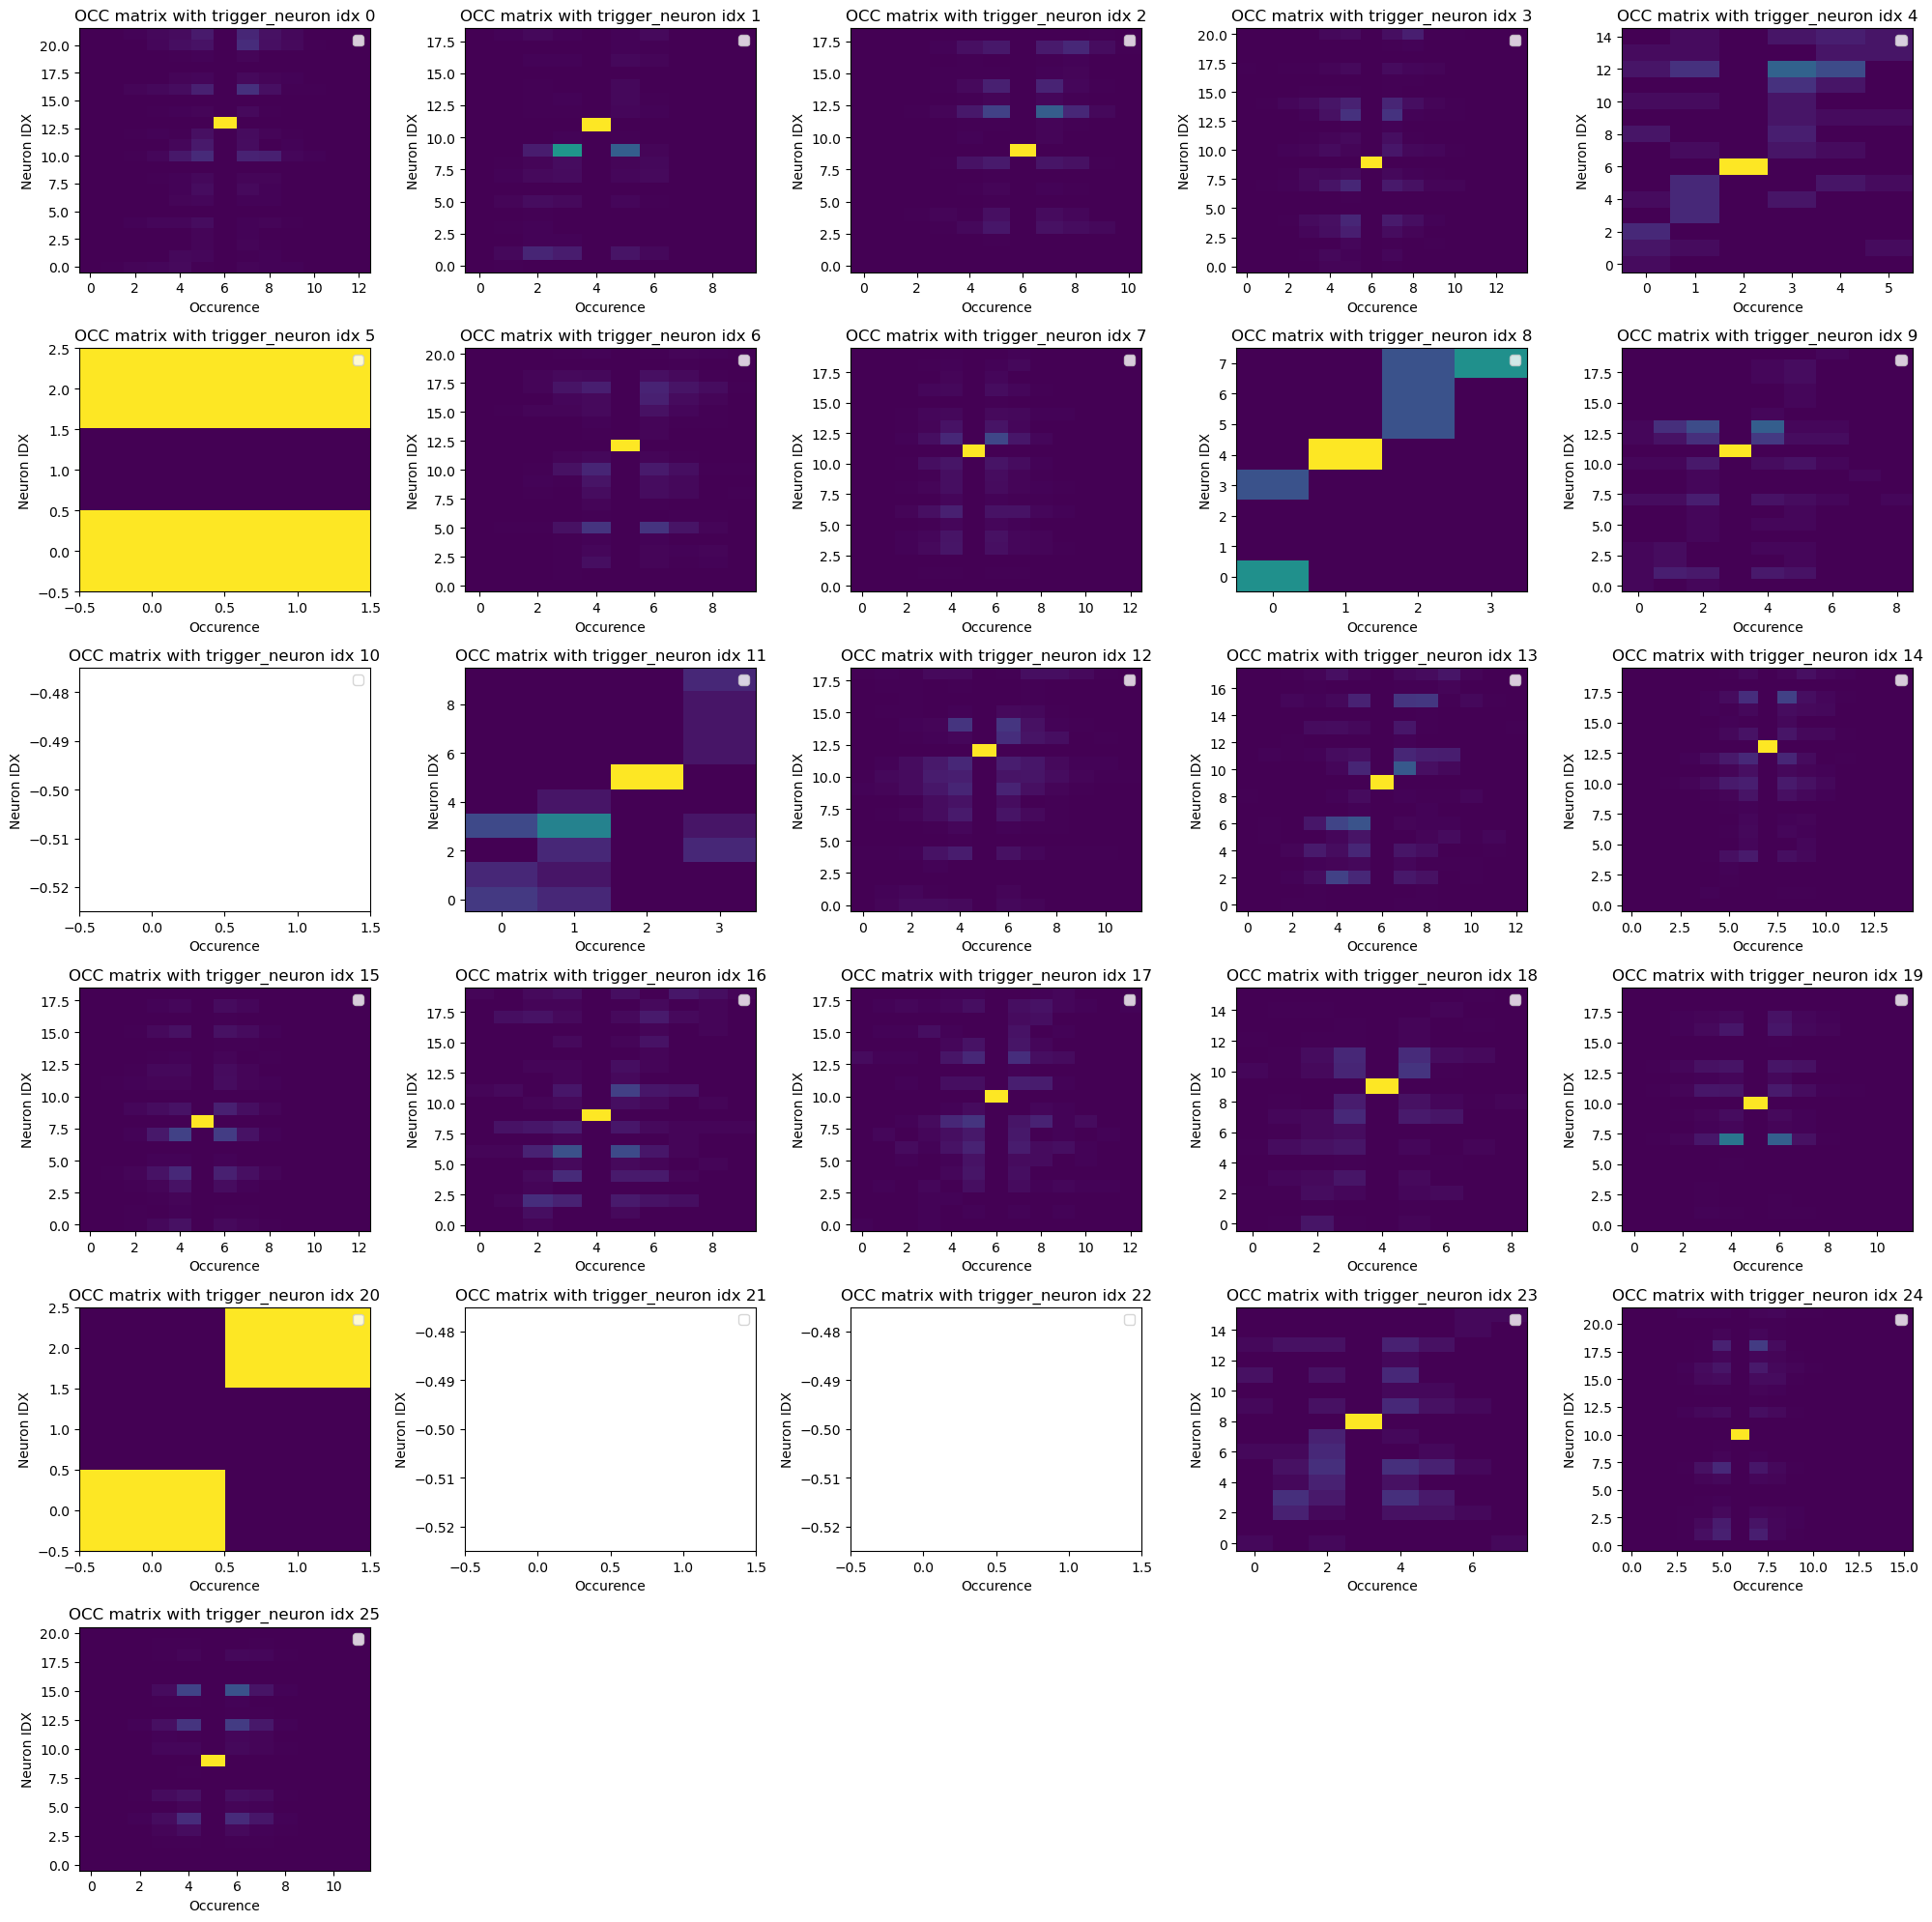

Rat10-20140626


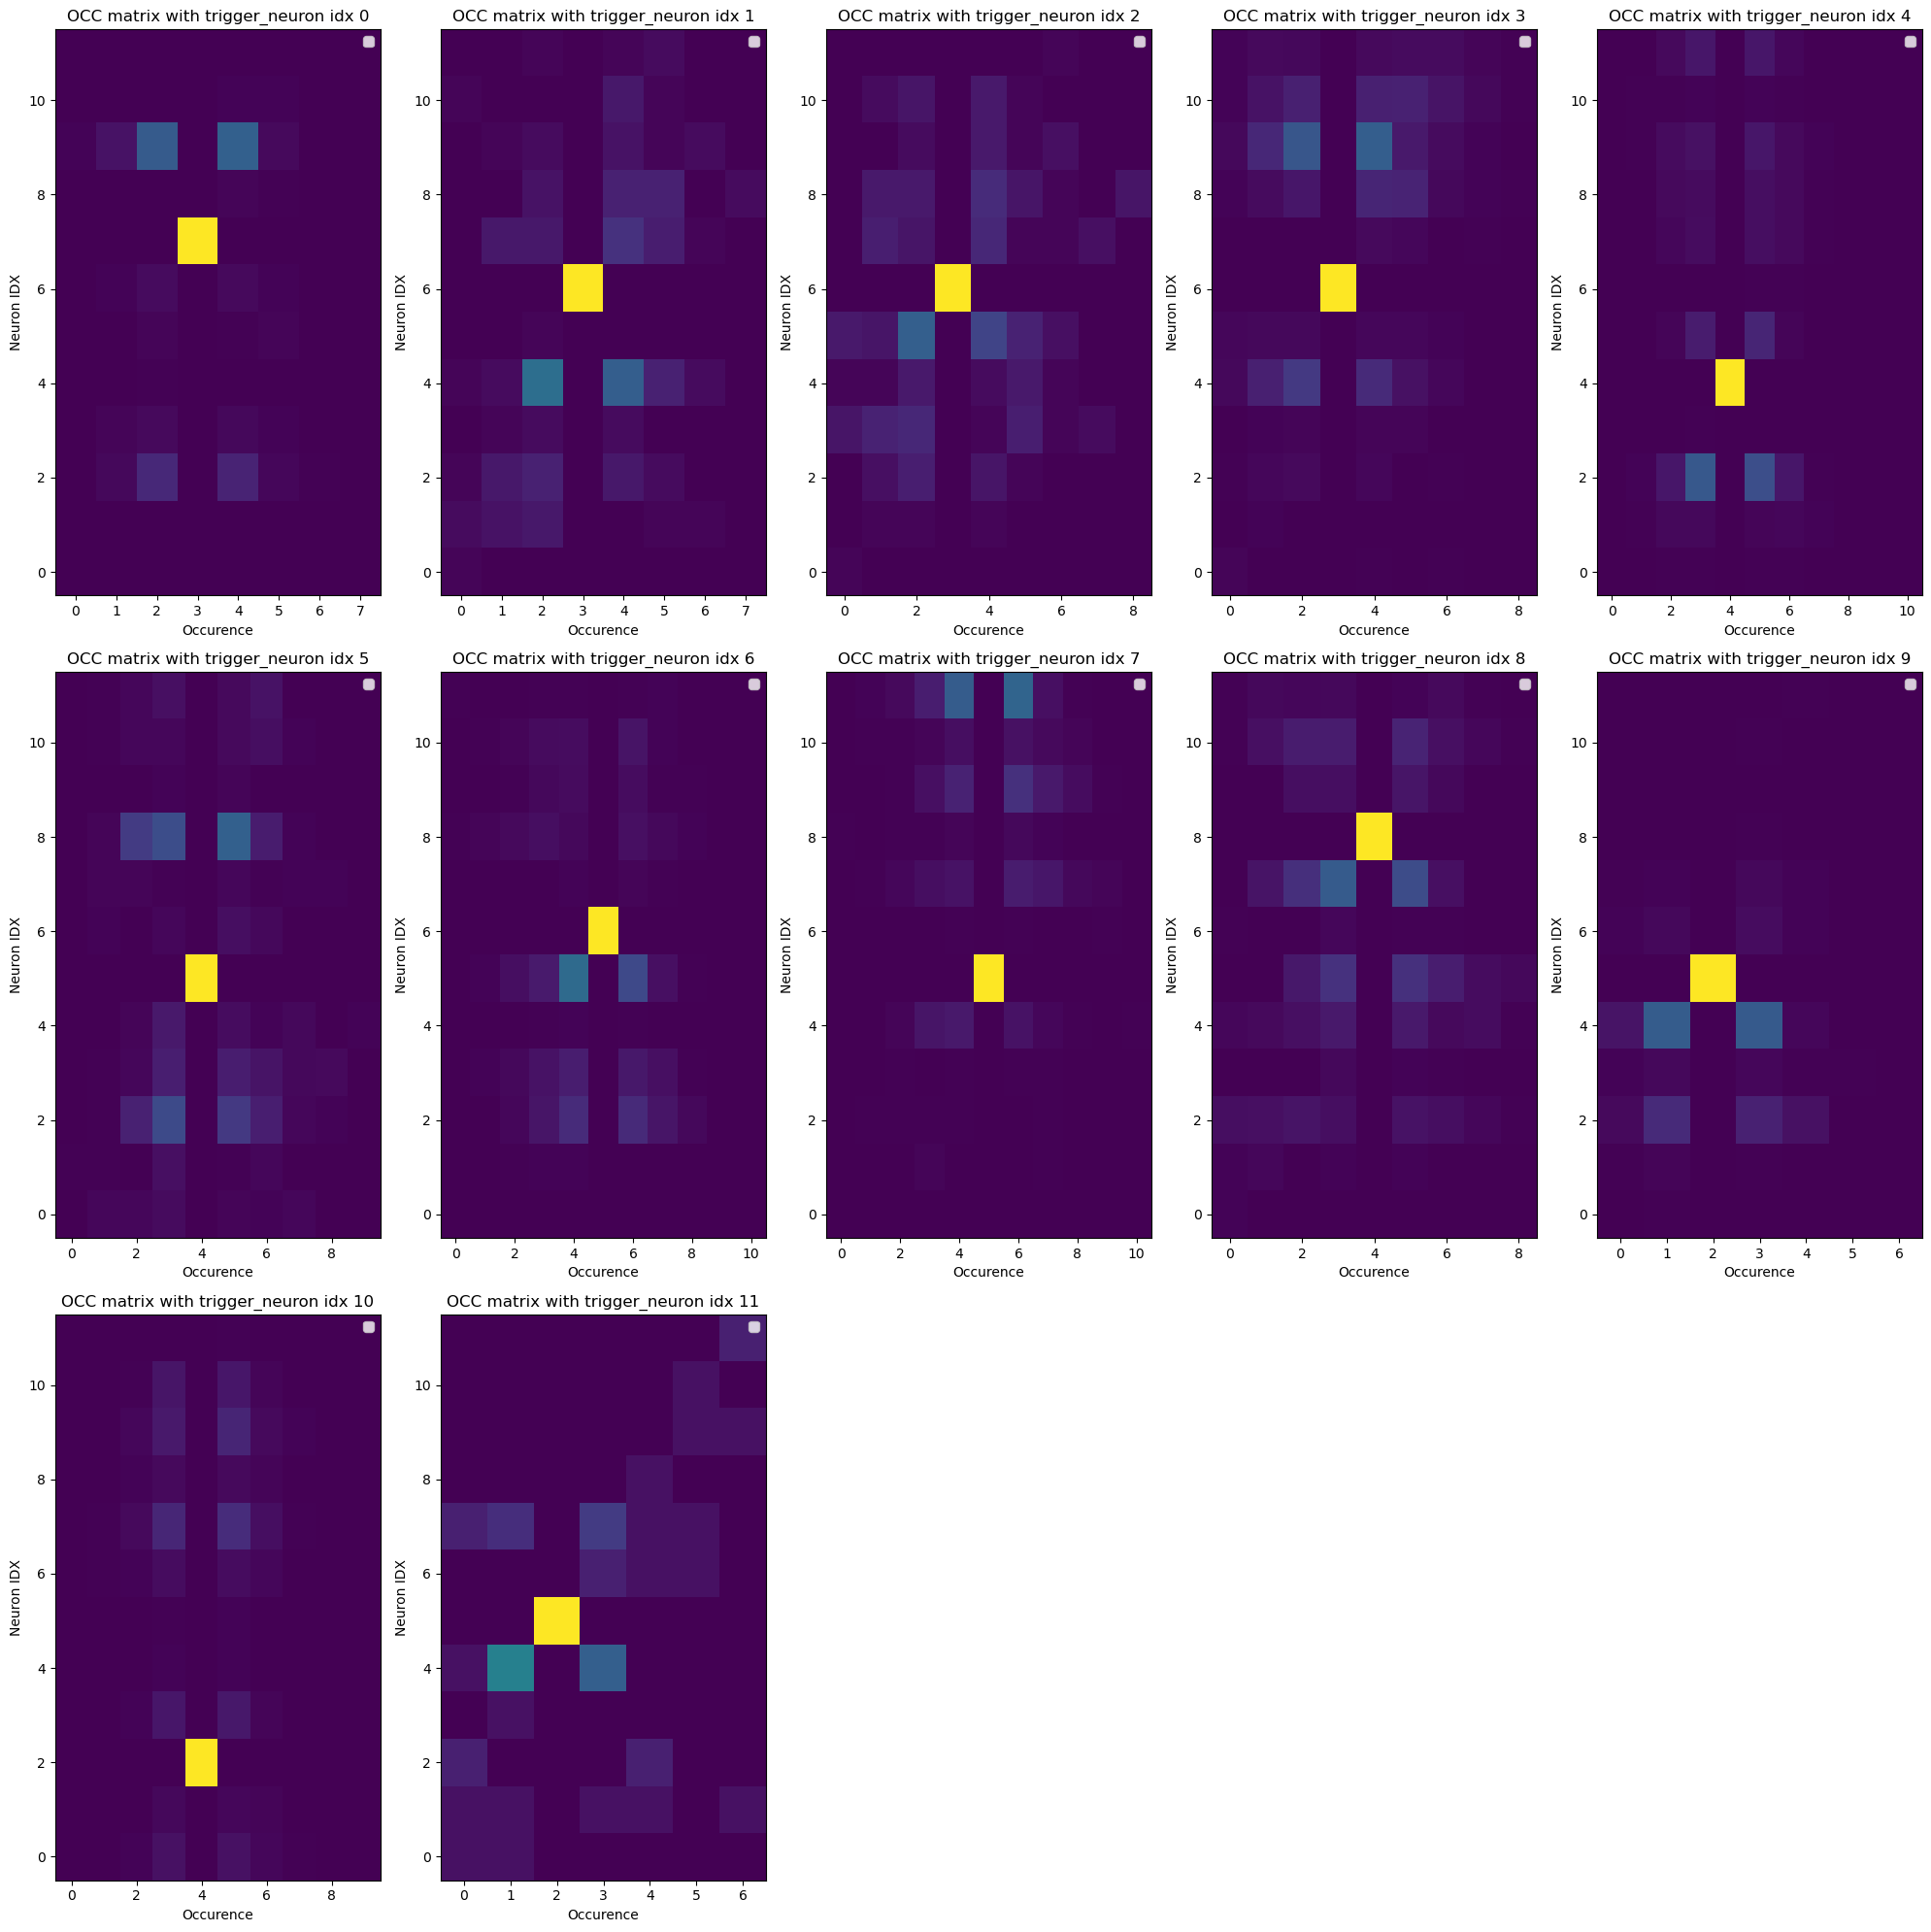

Rat10-20140627


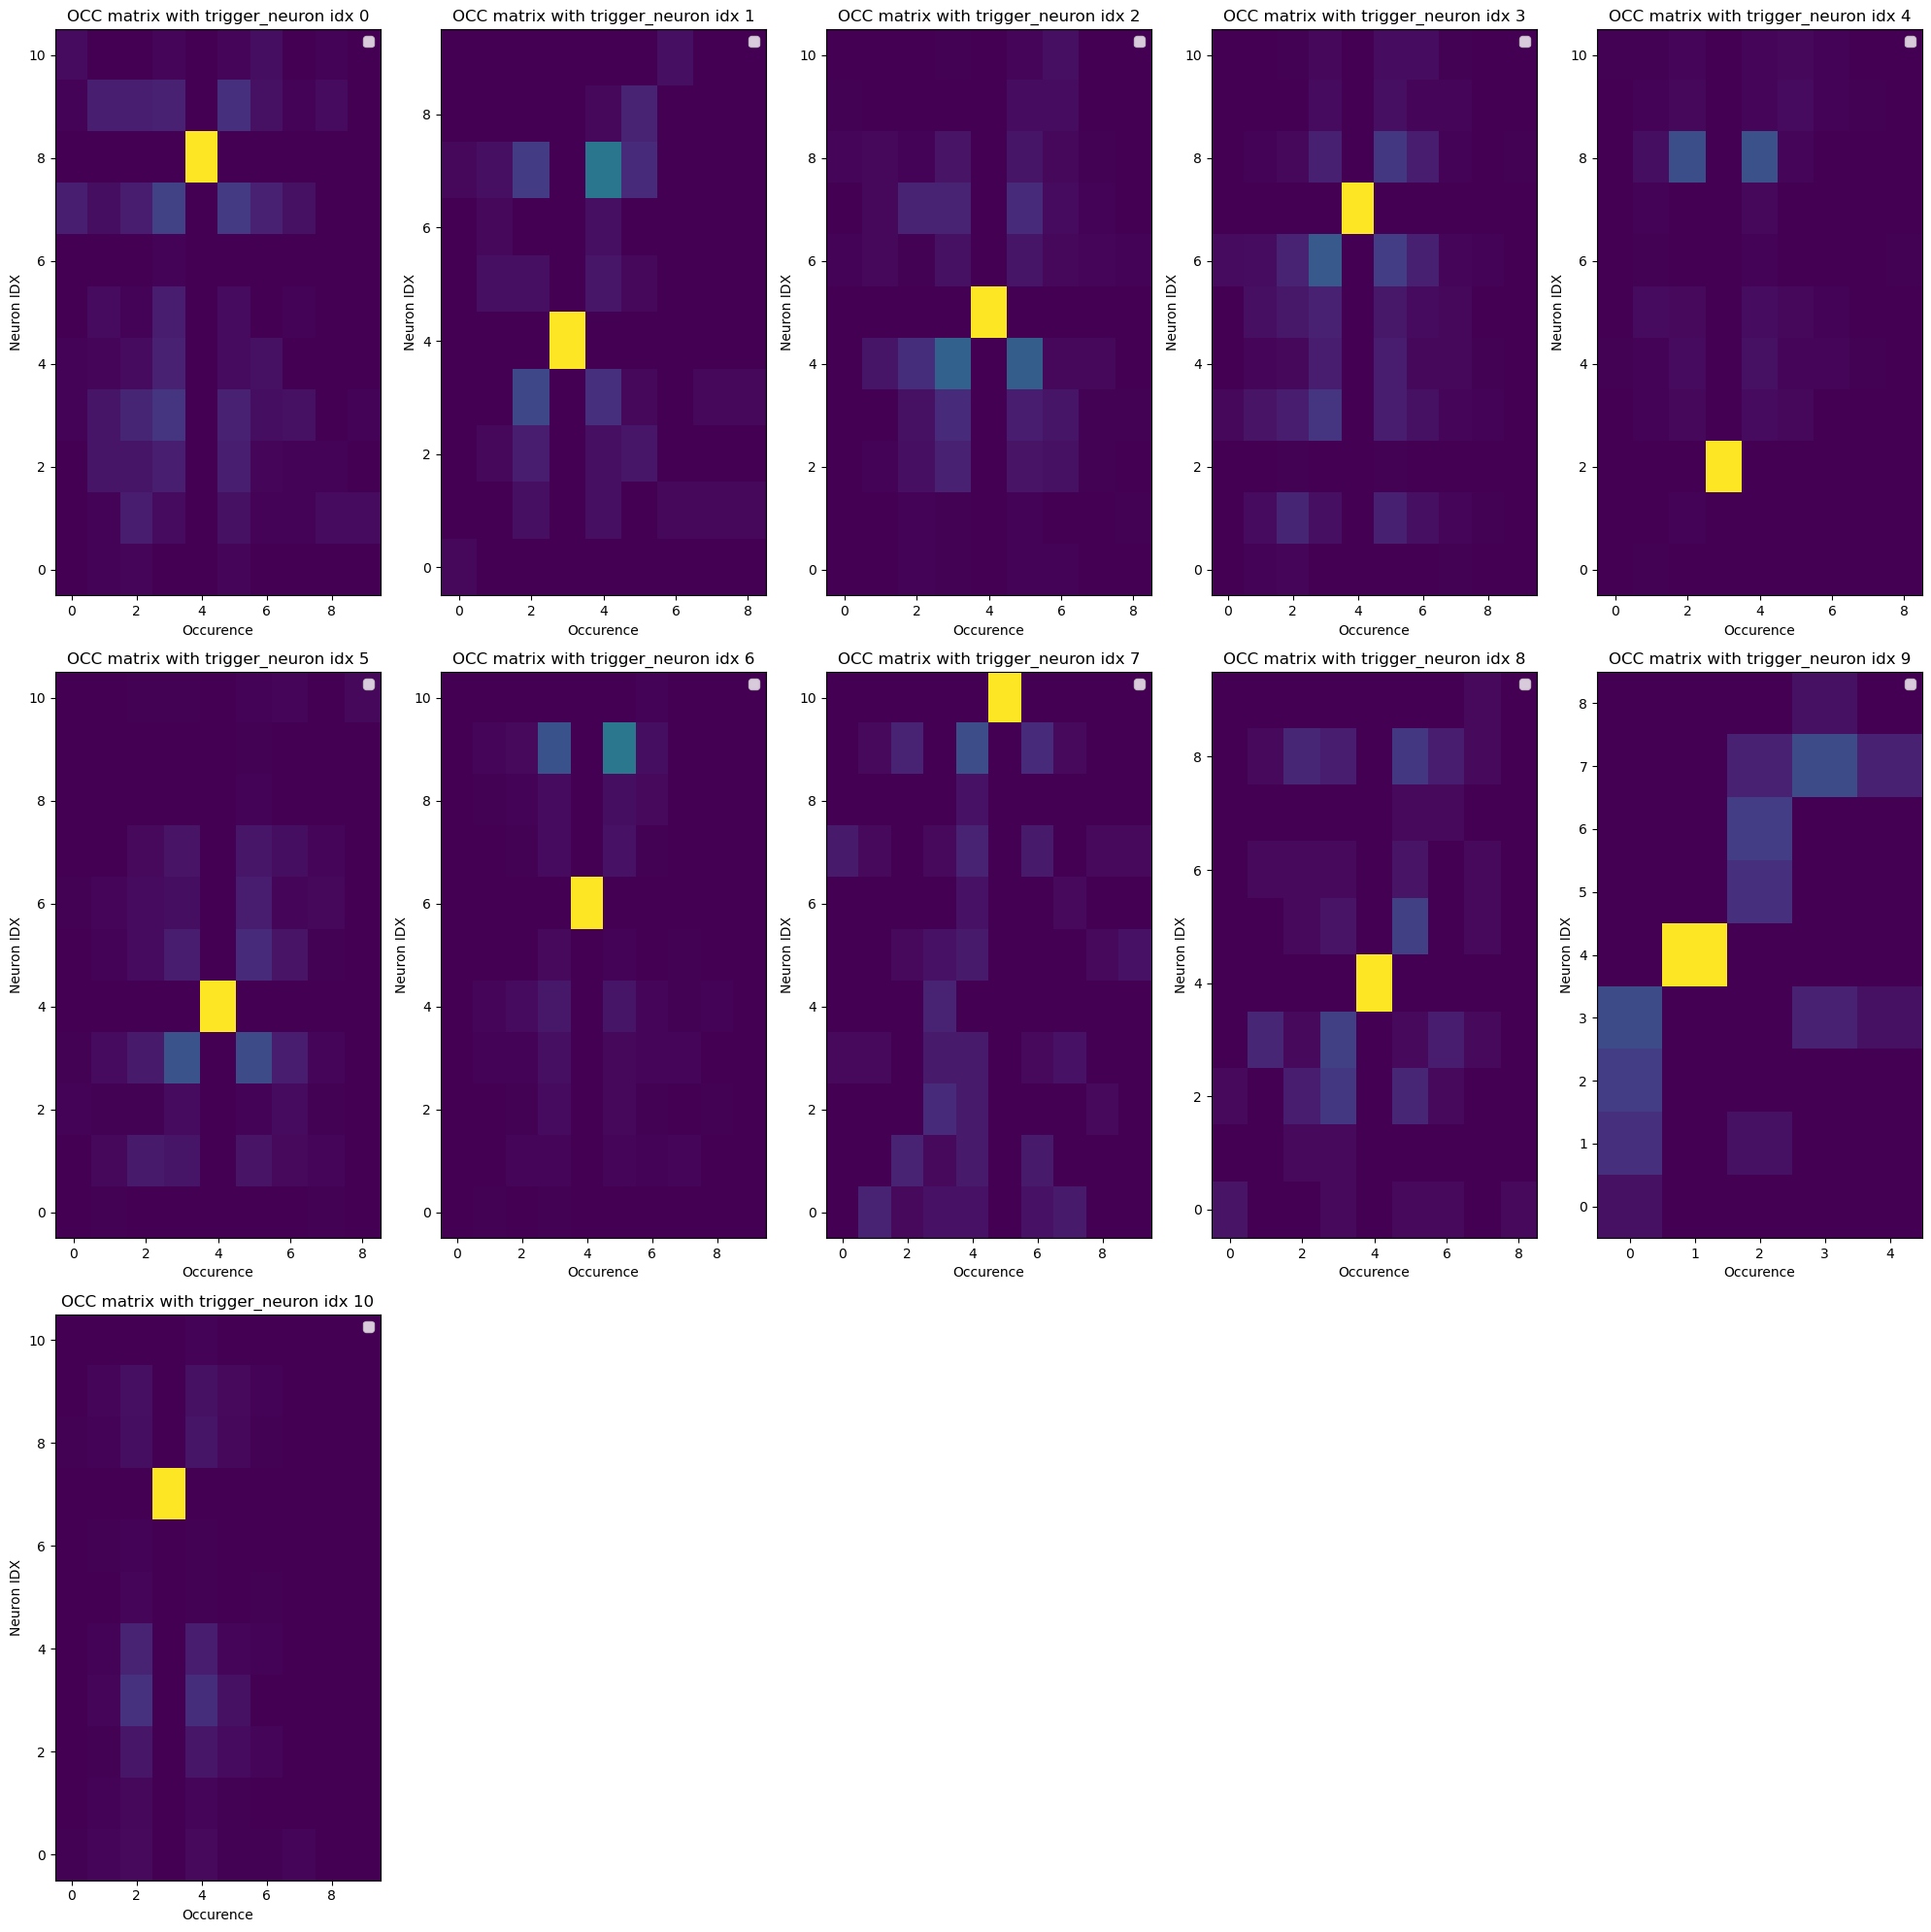

Rat10-20140628


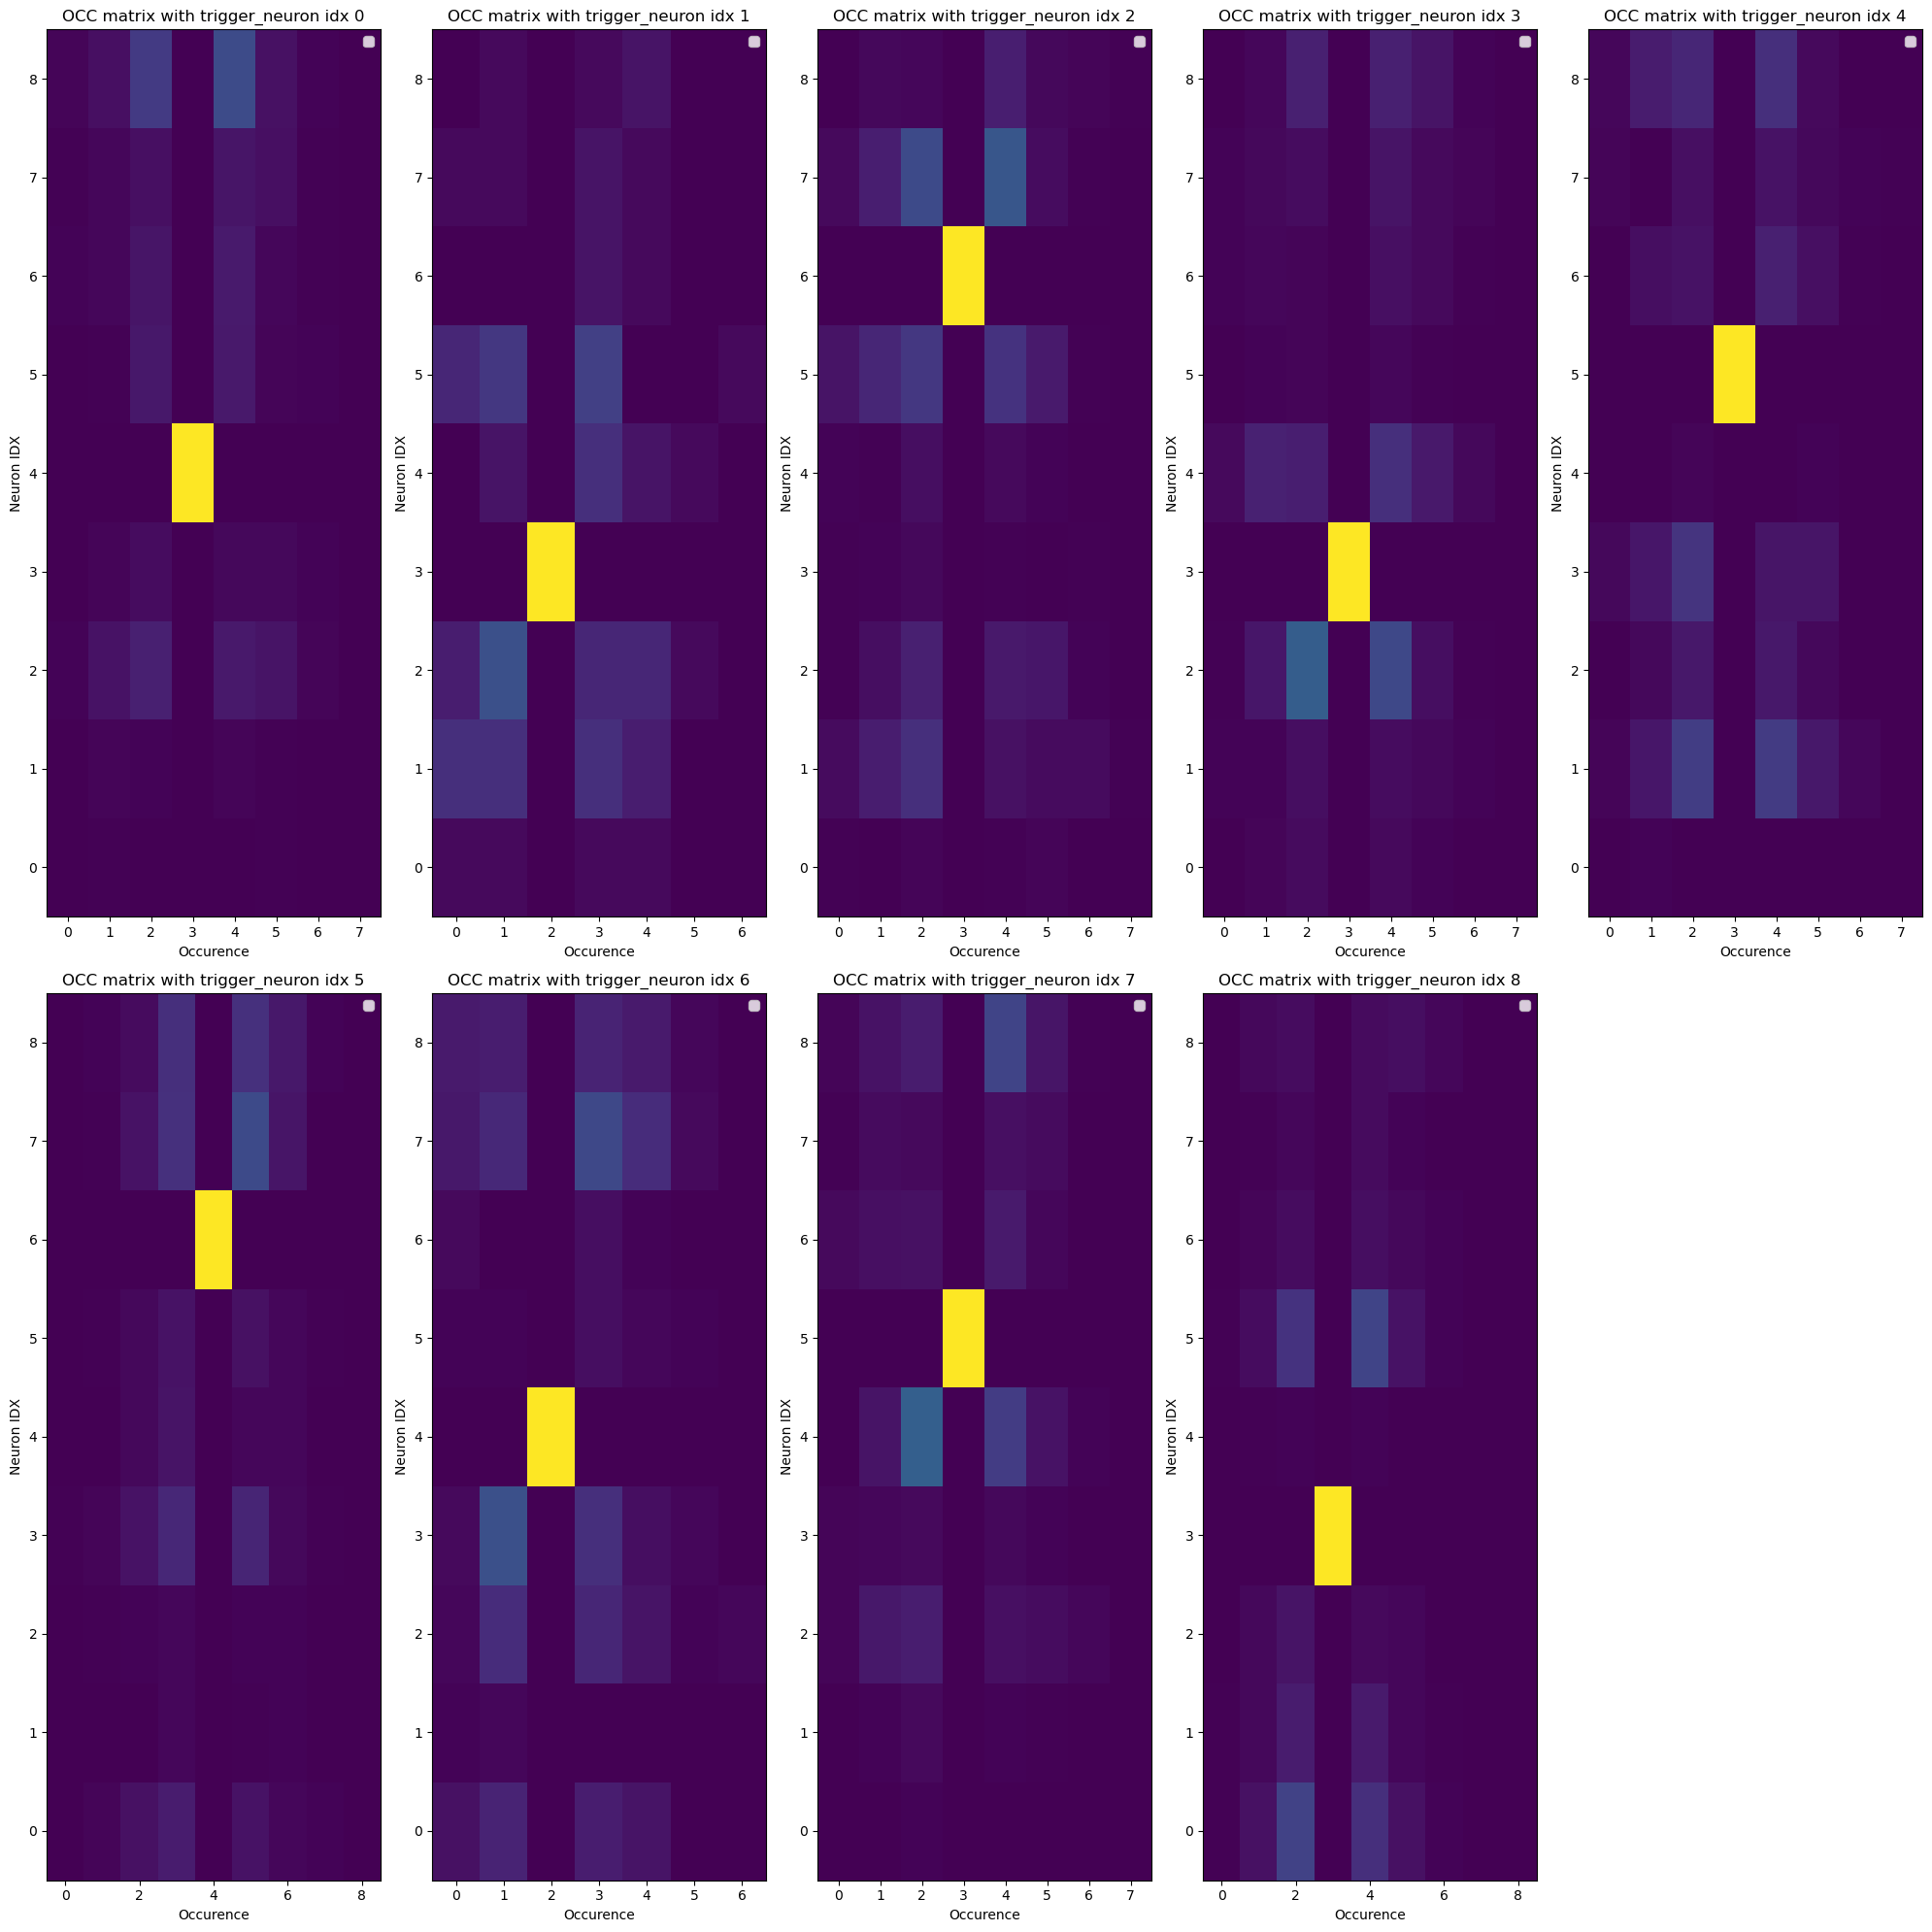

Rat10-20140629


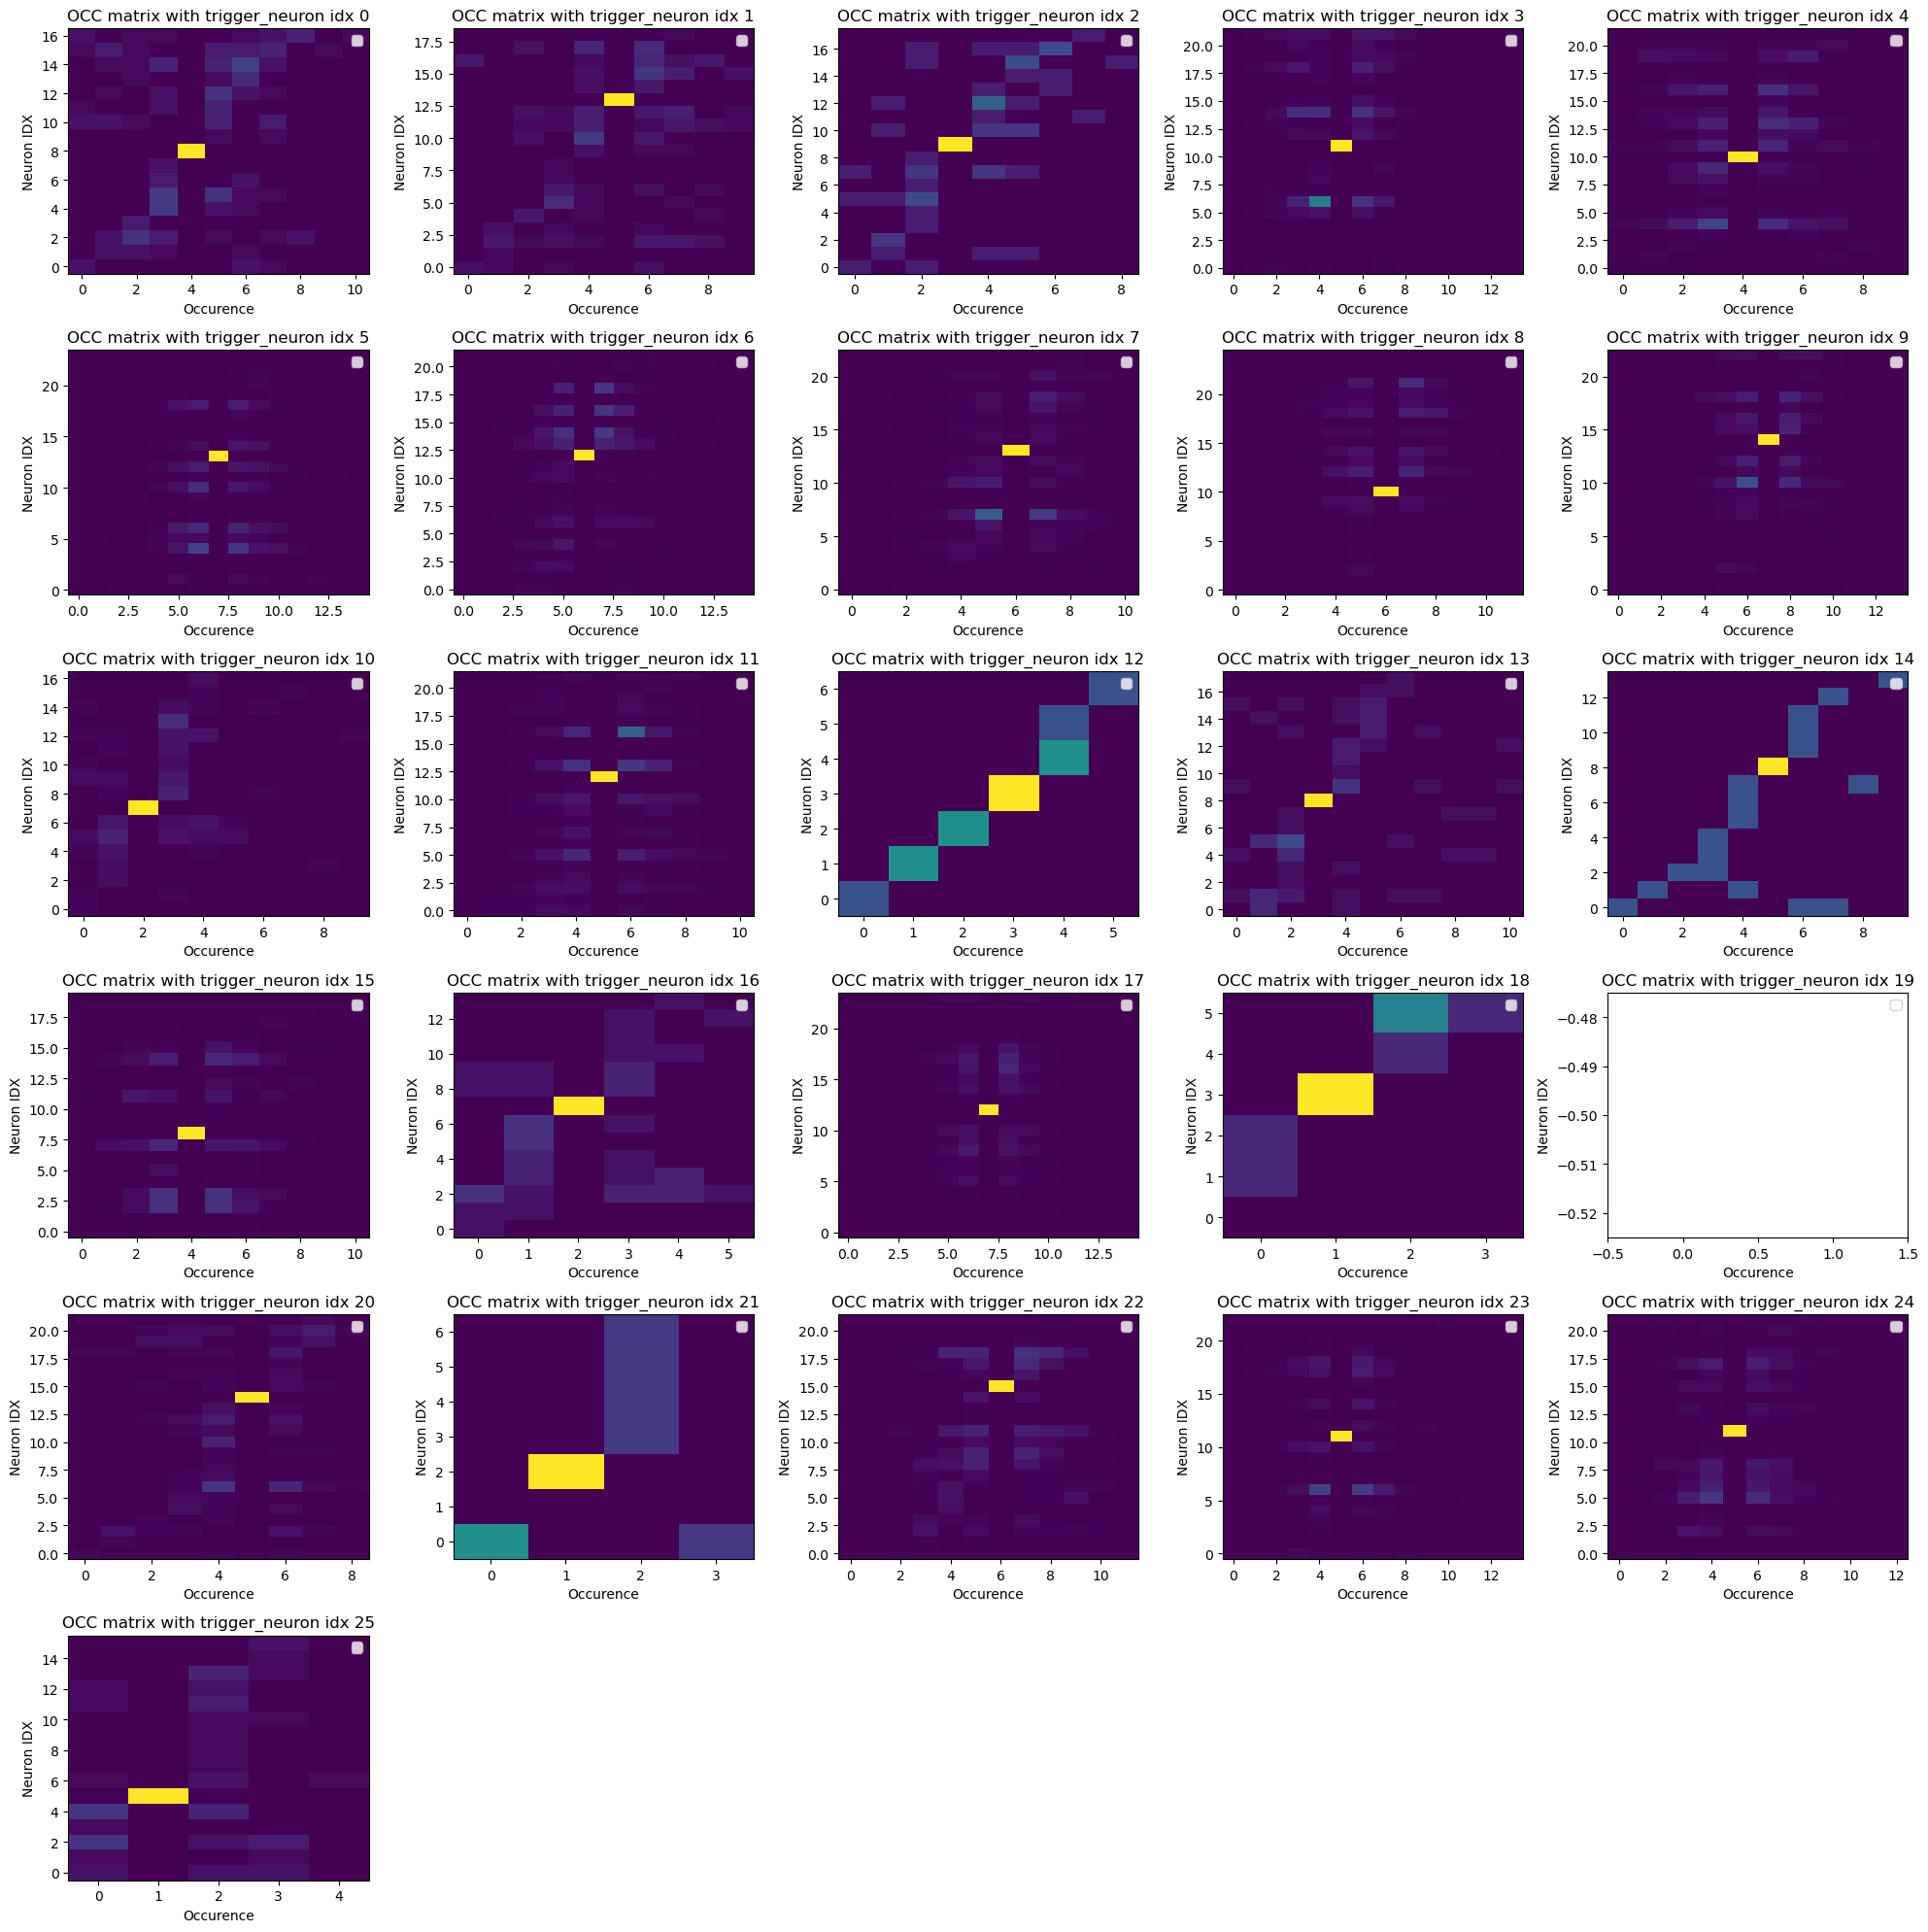

Rat10-20140701


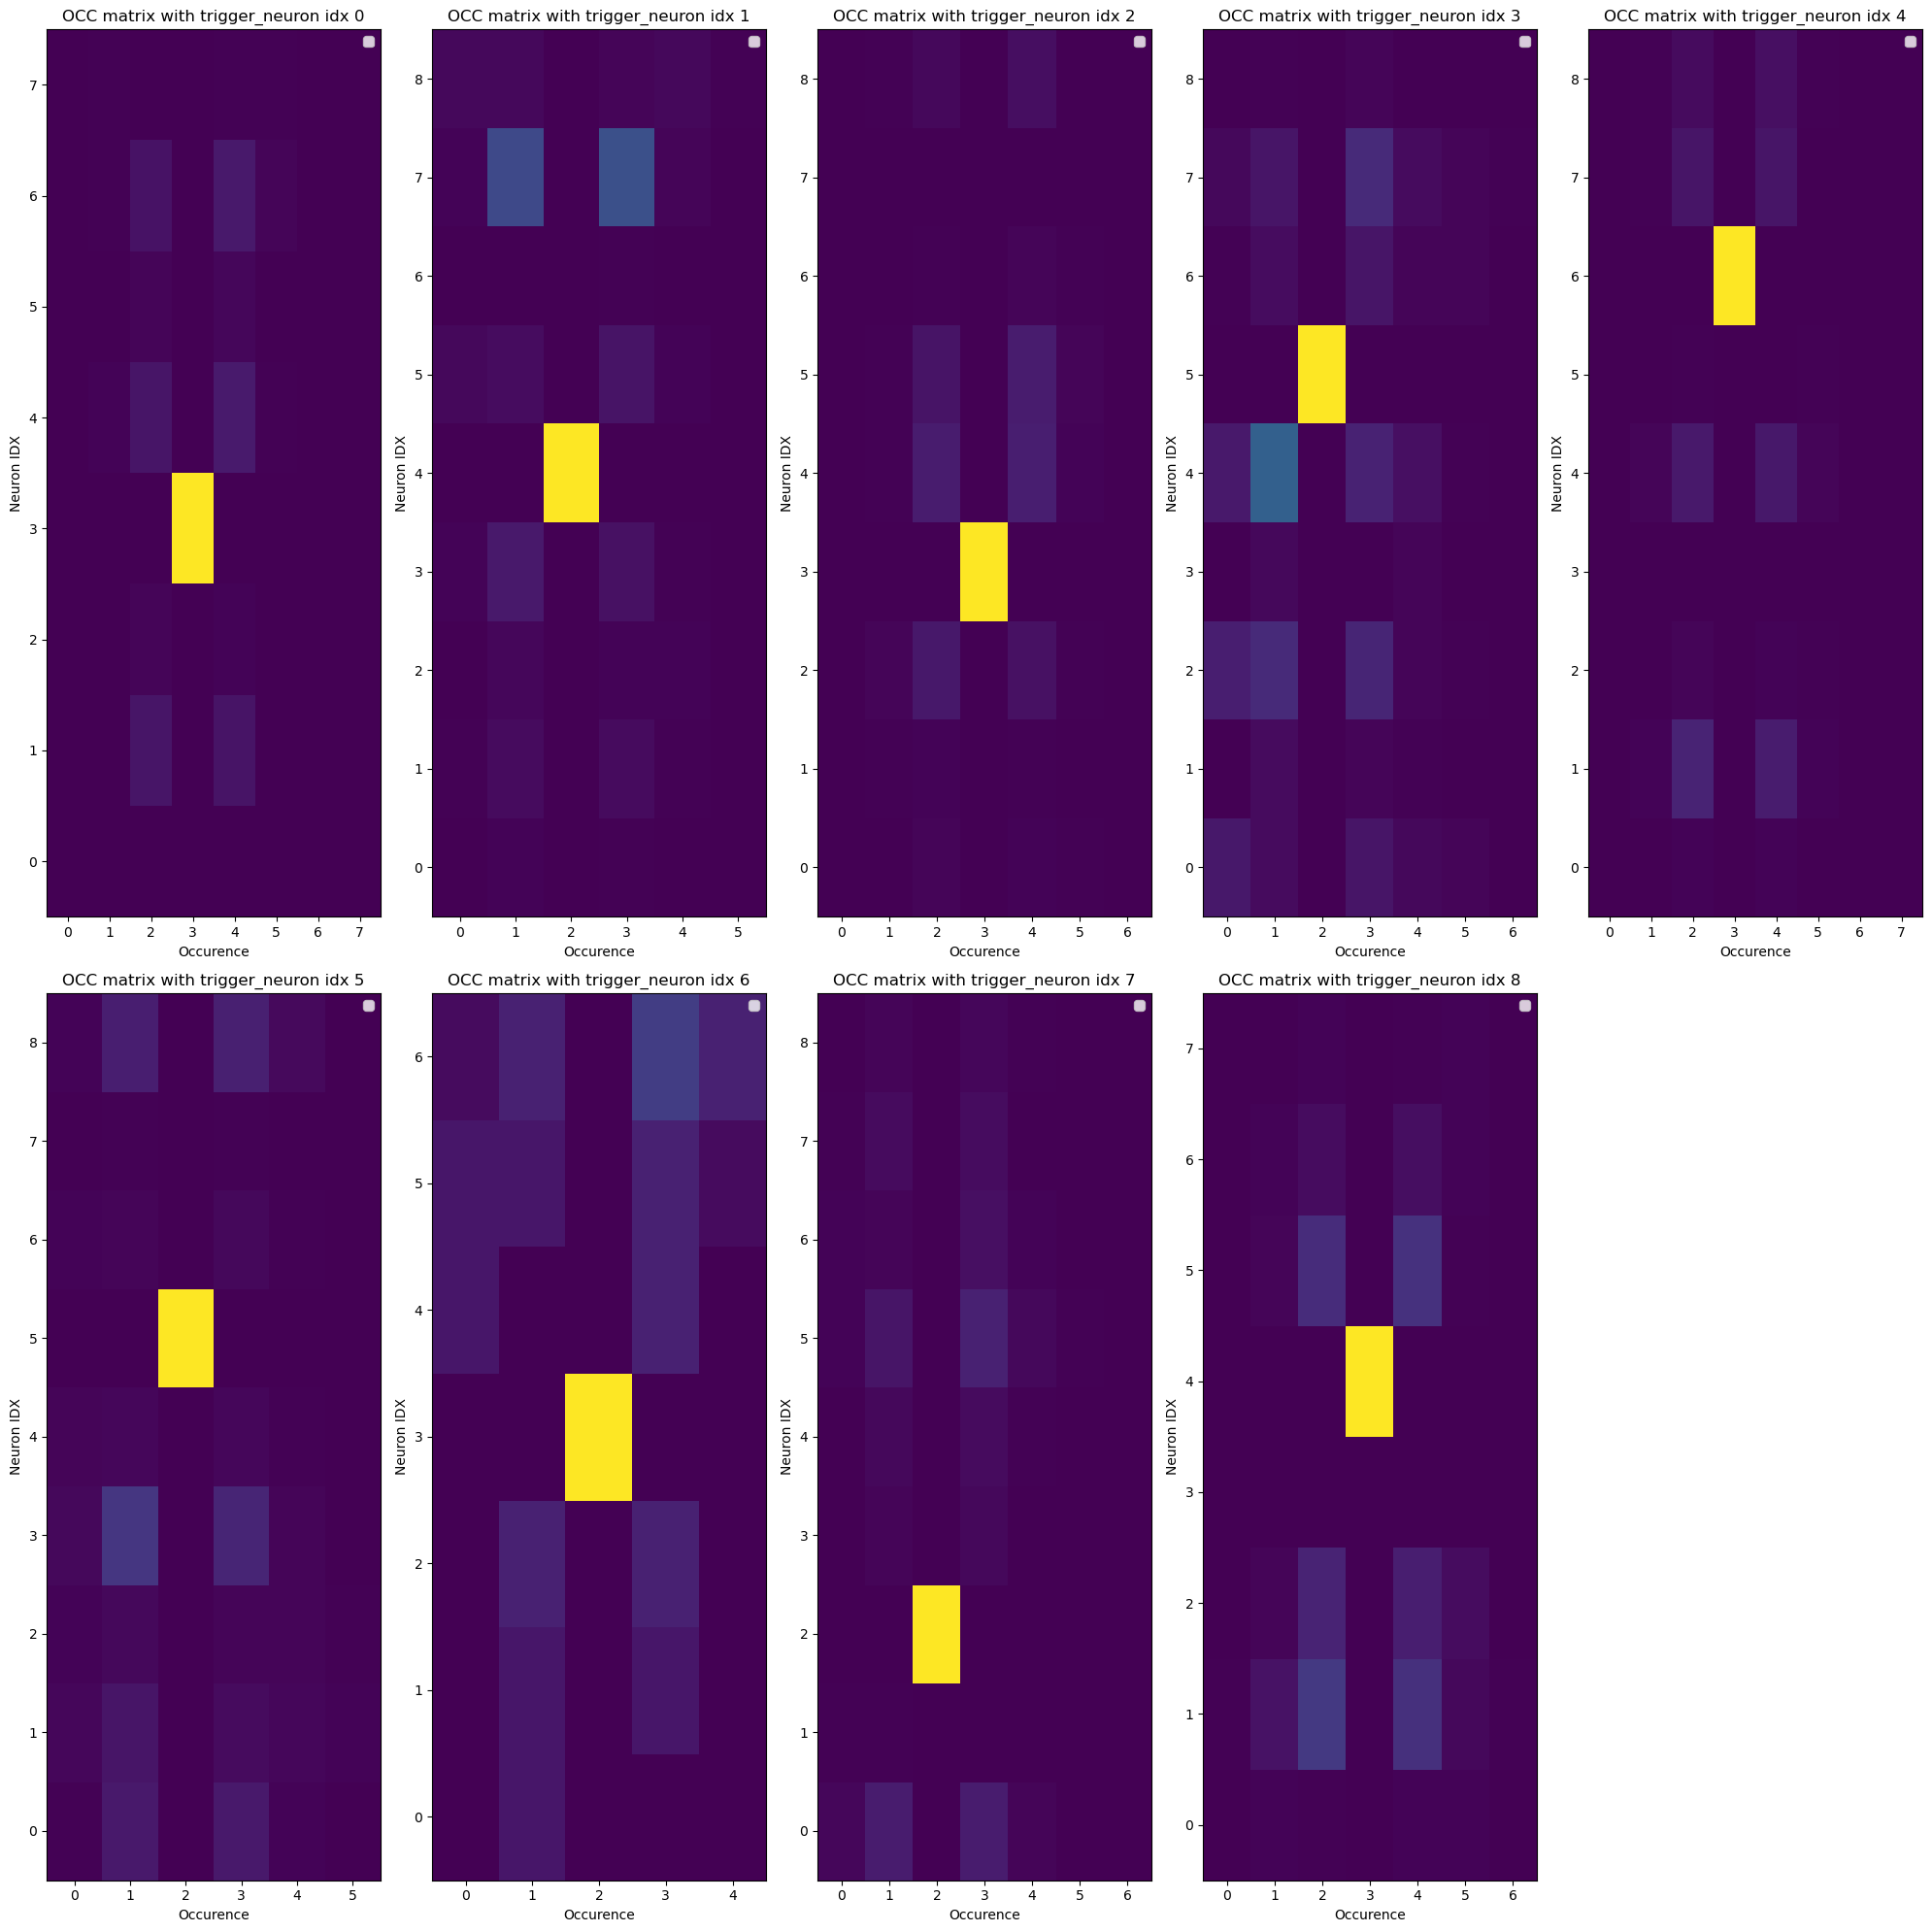

Rat10-20140702


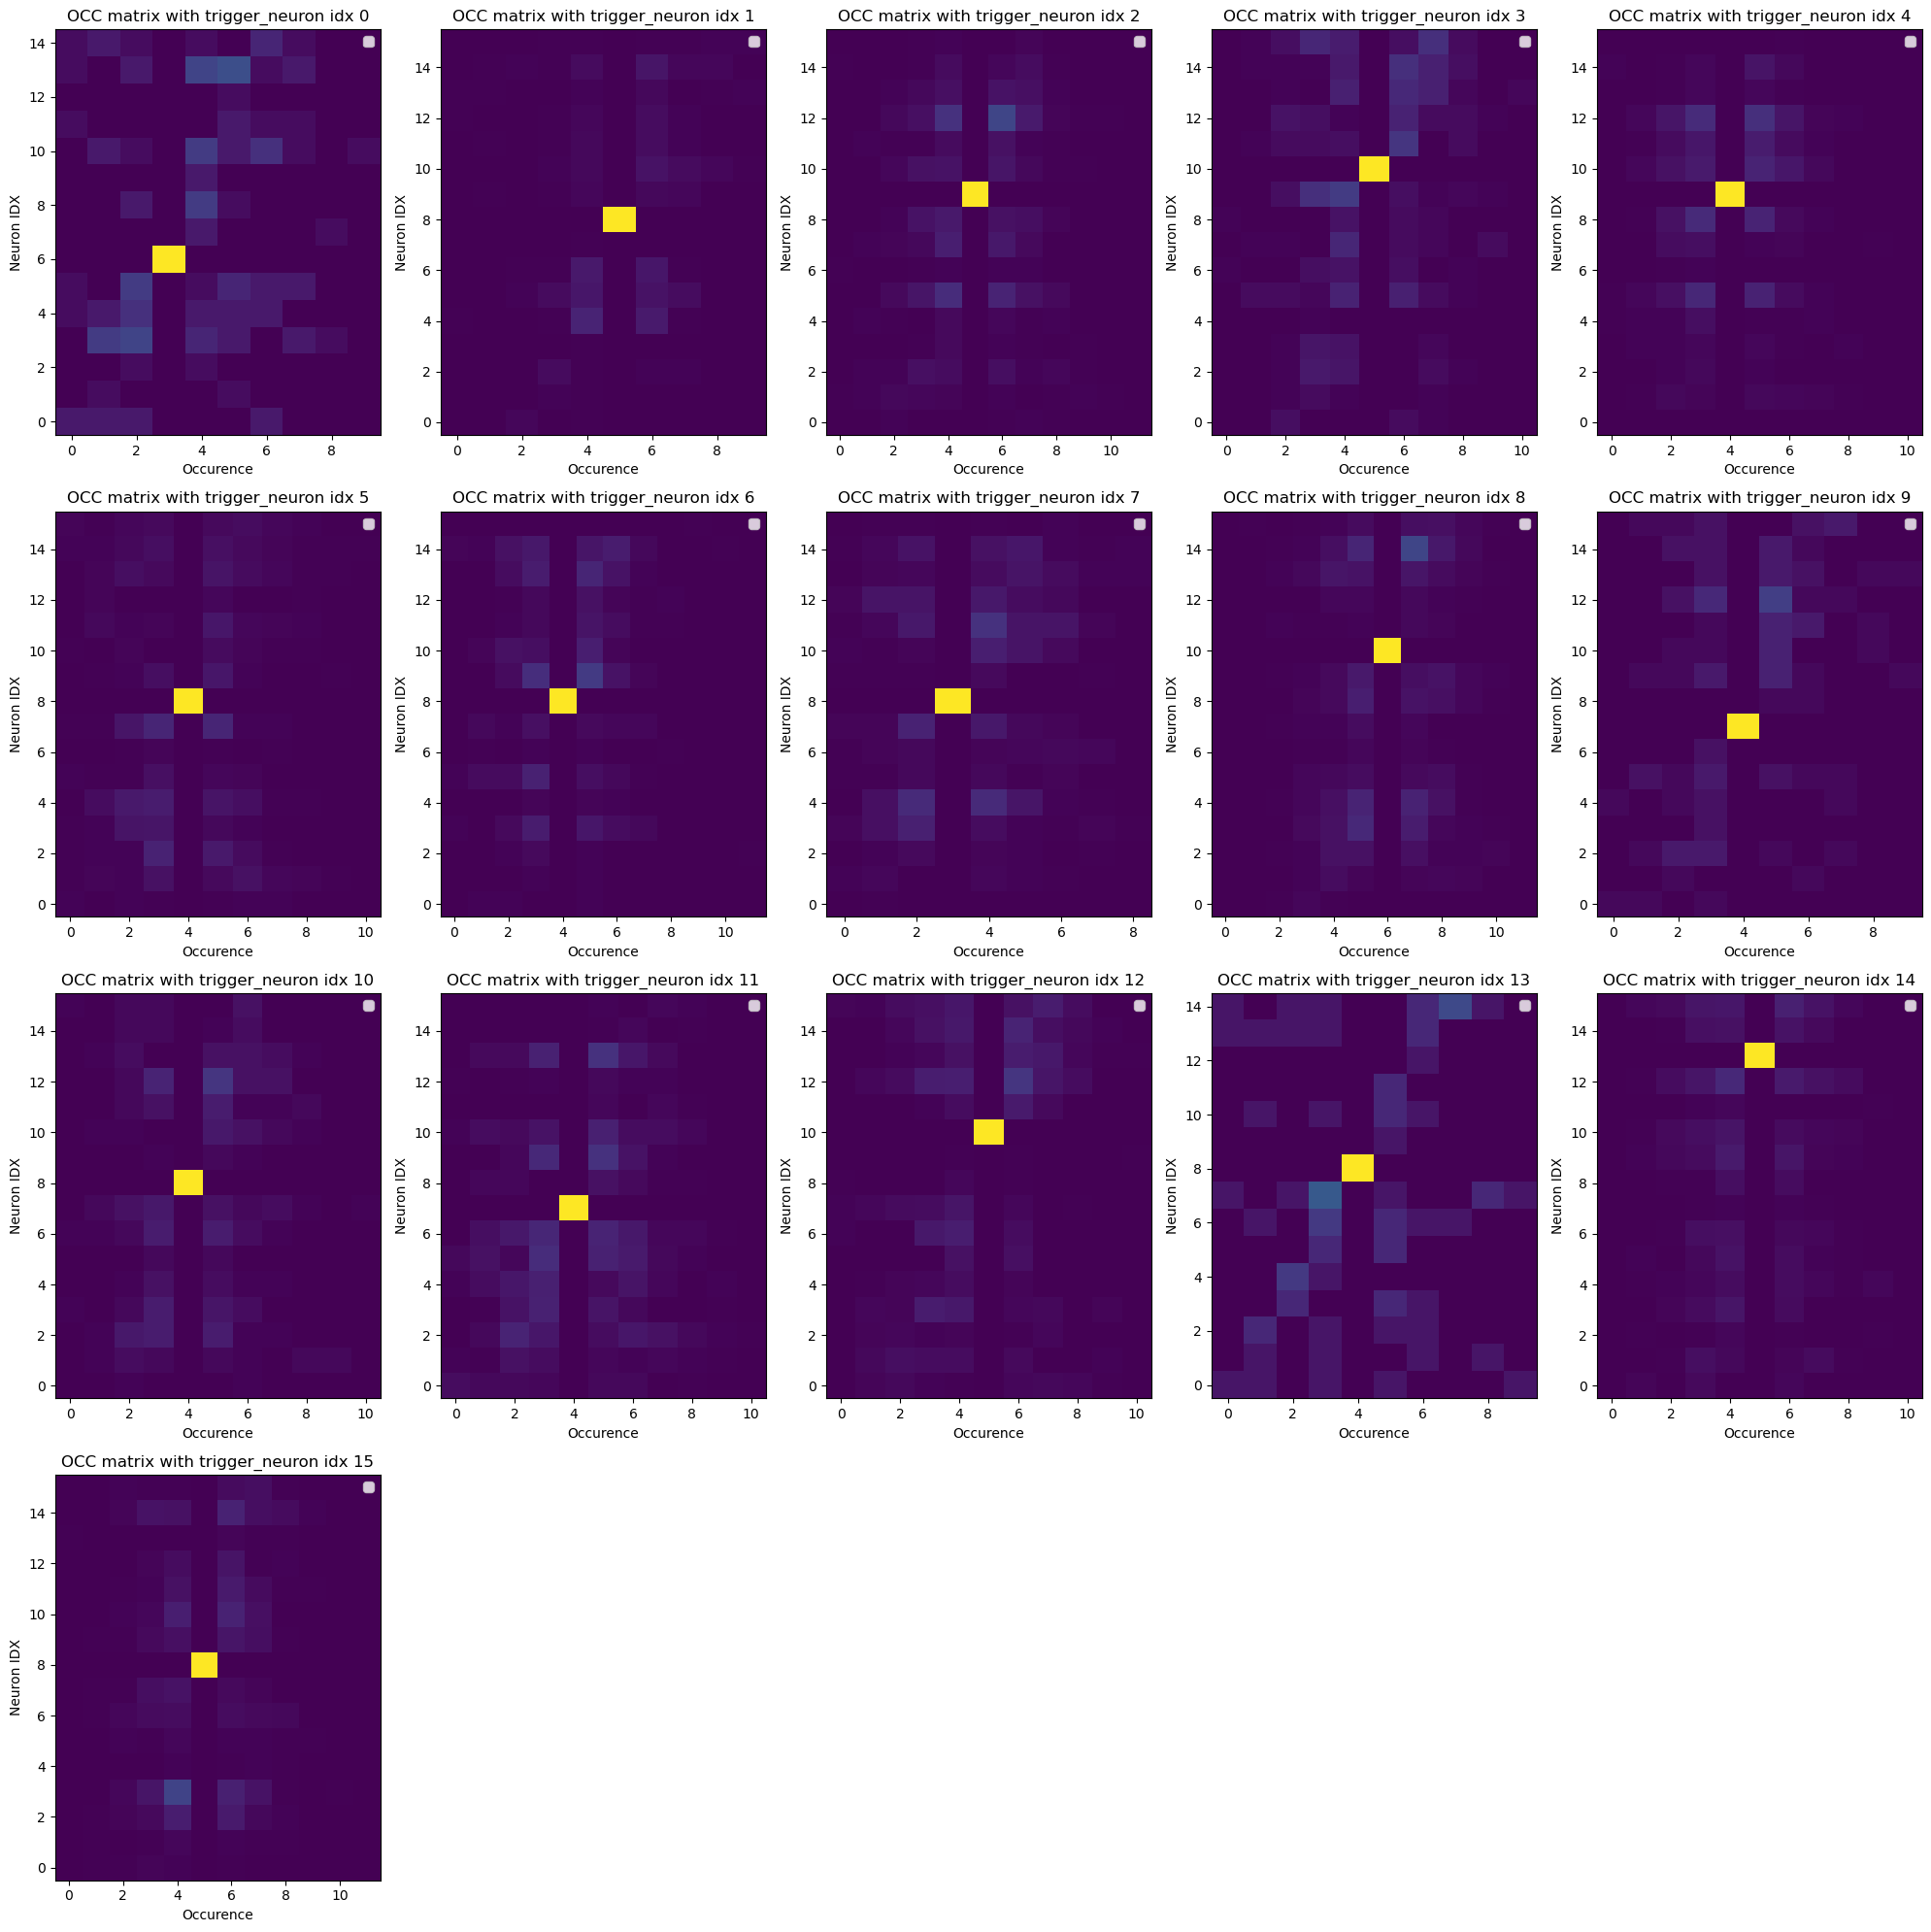

Rat10-20140703


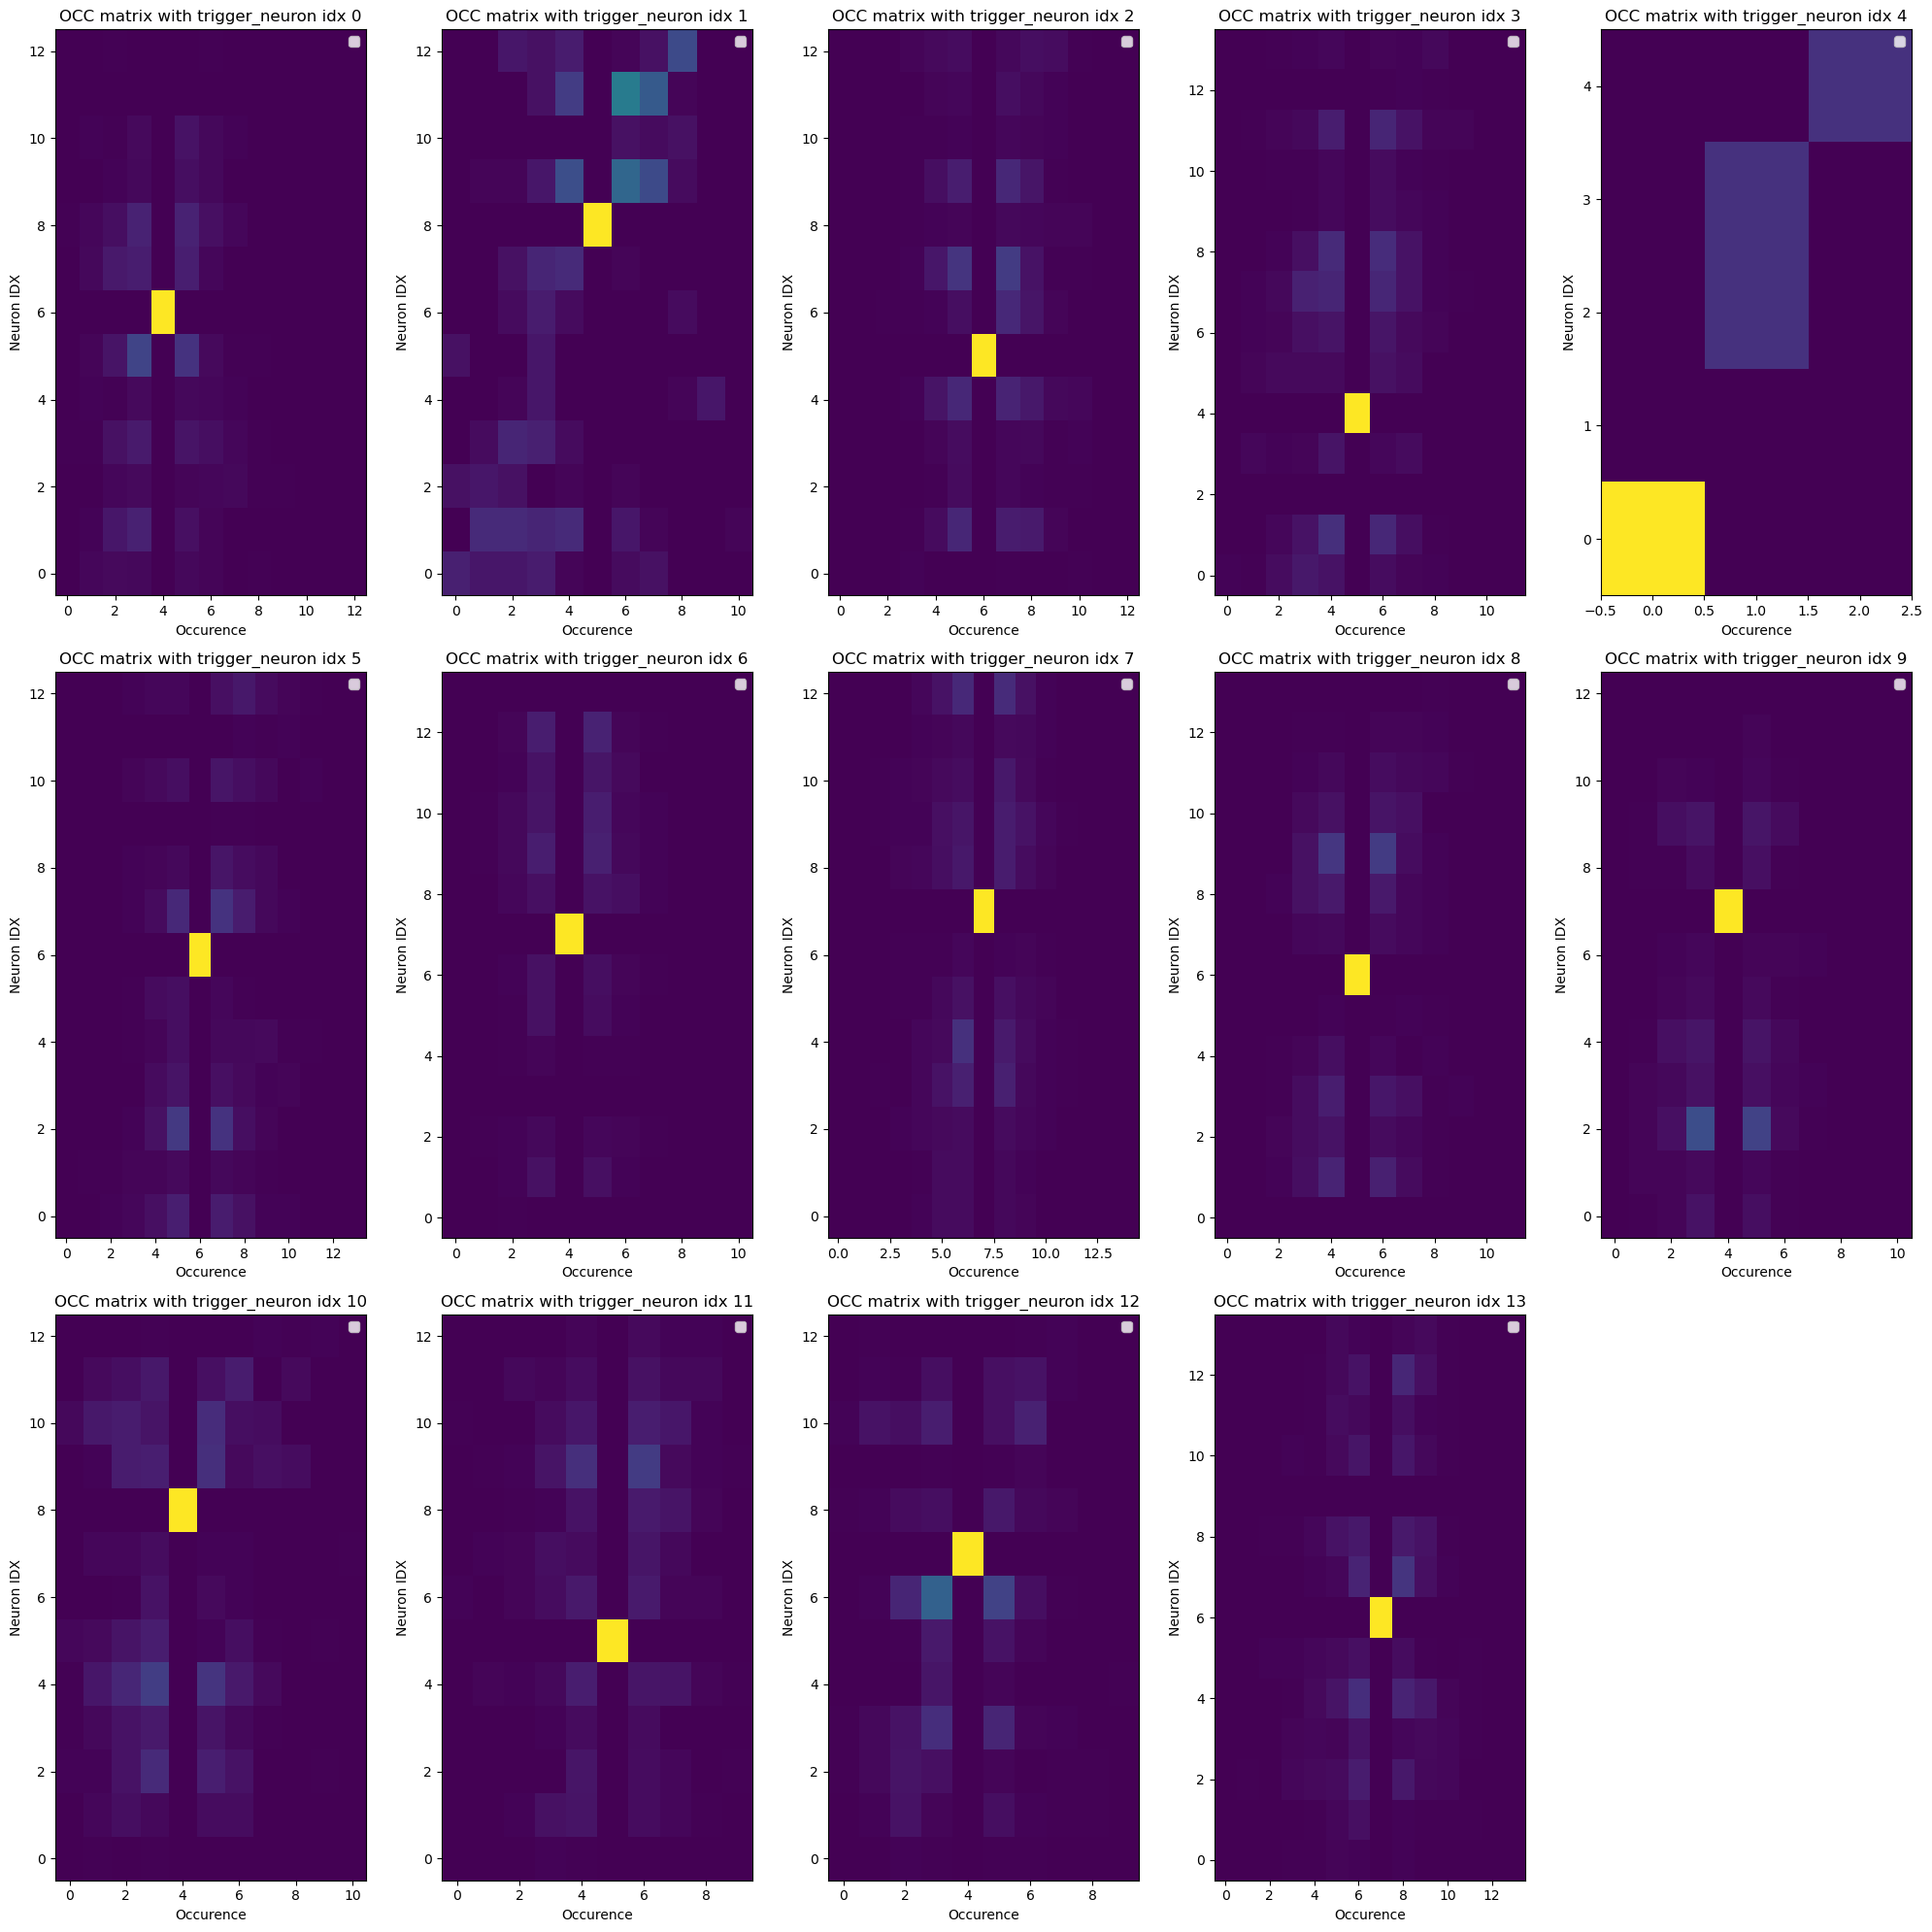

Rat10-20140707


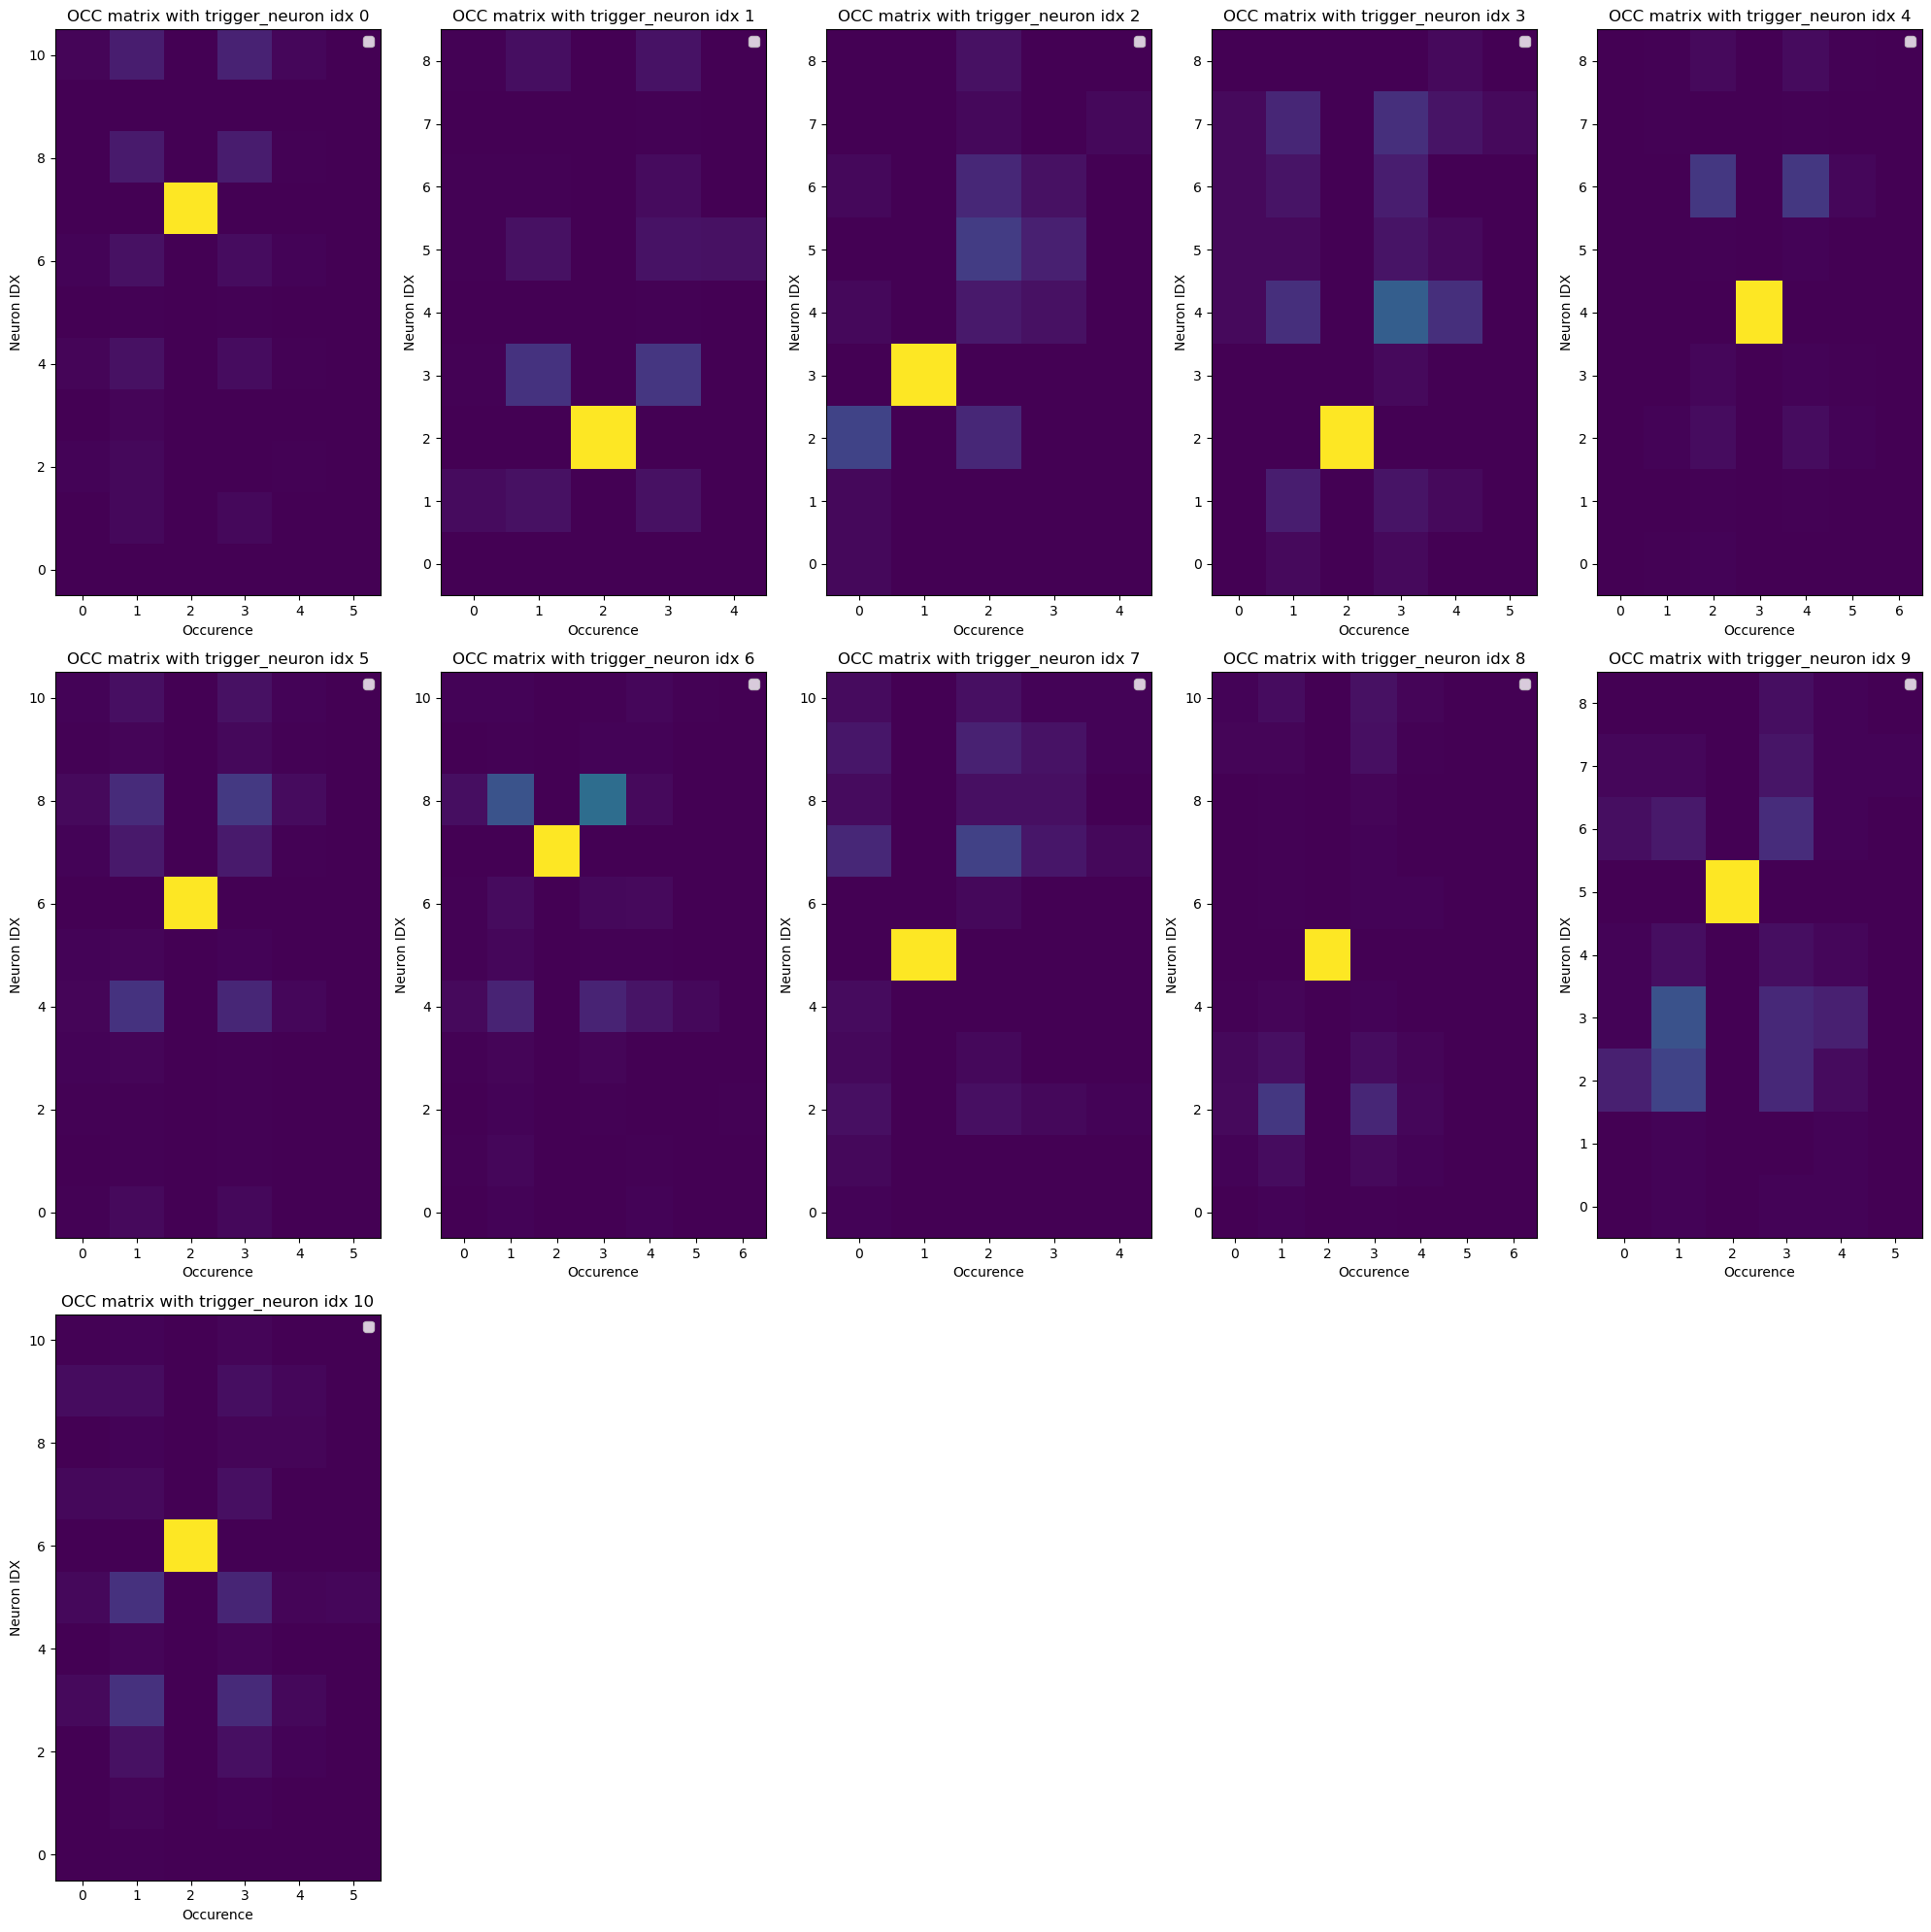

Rat10-20140708


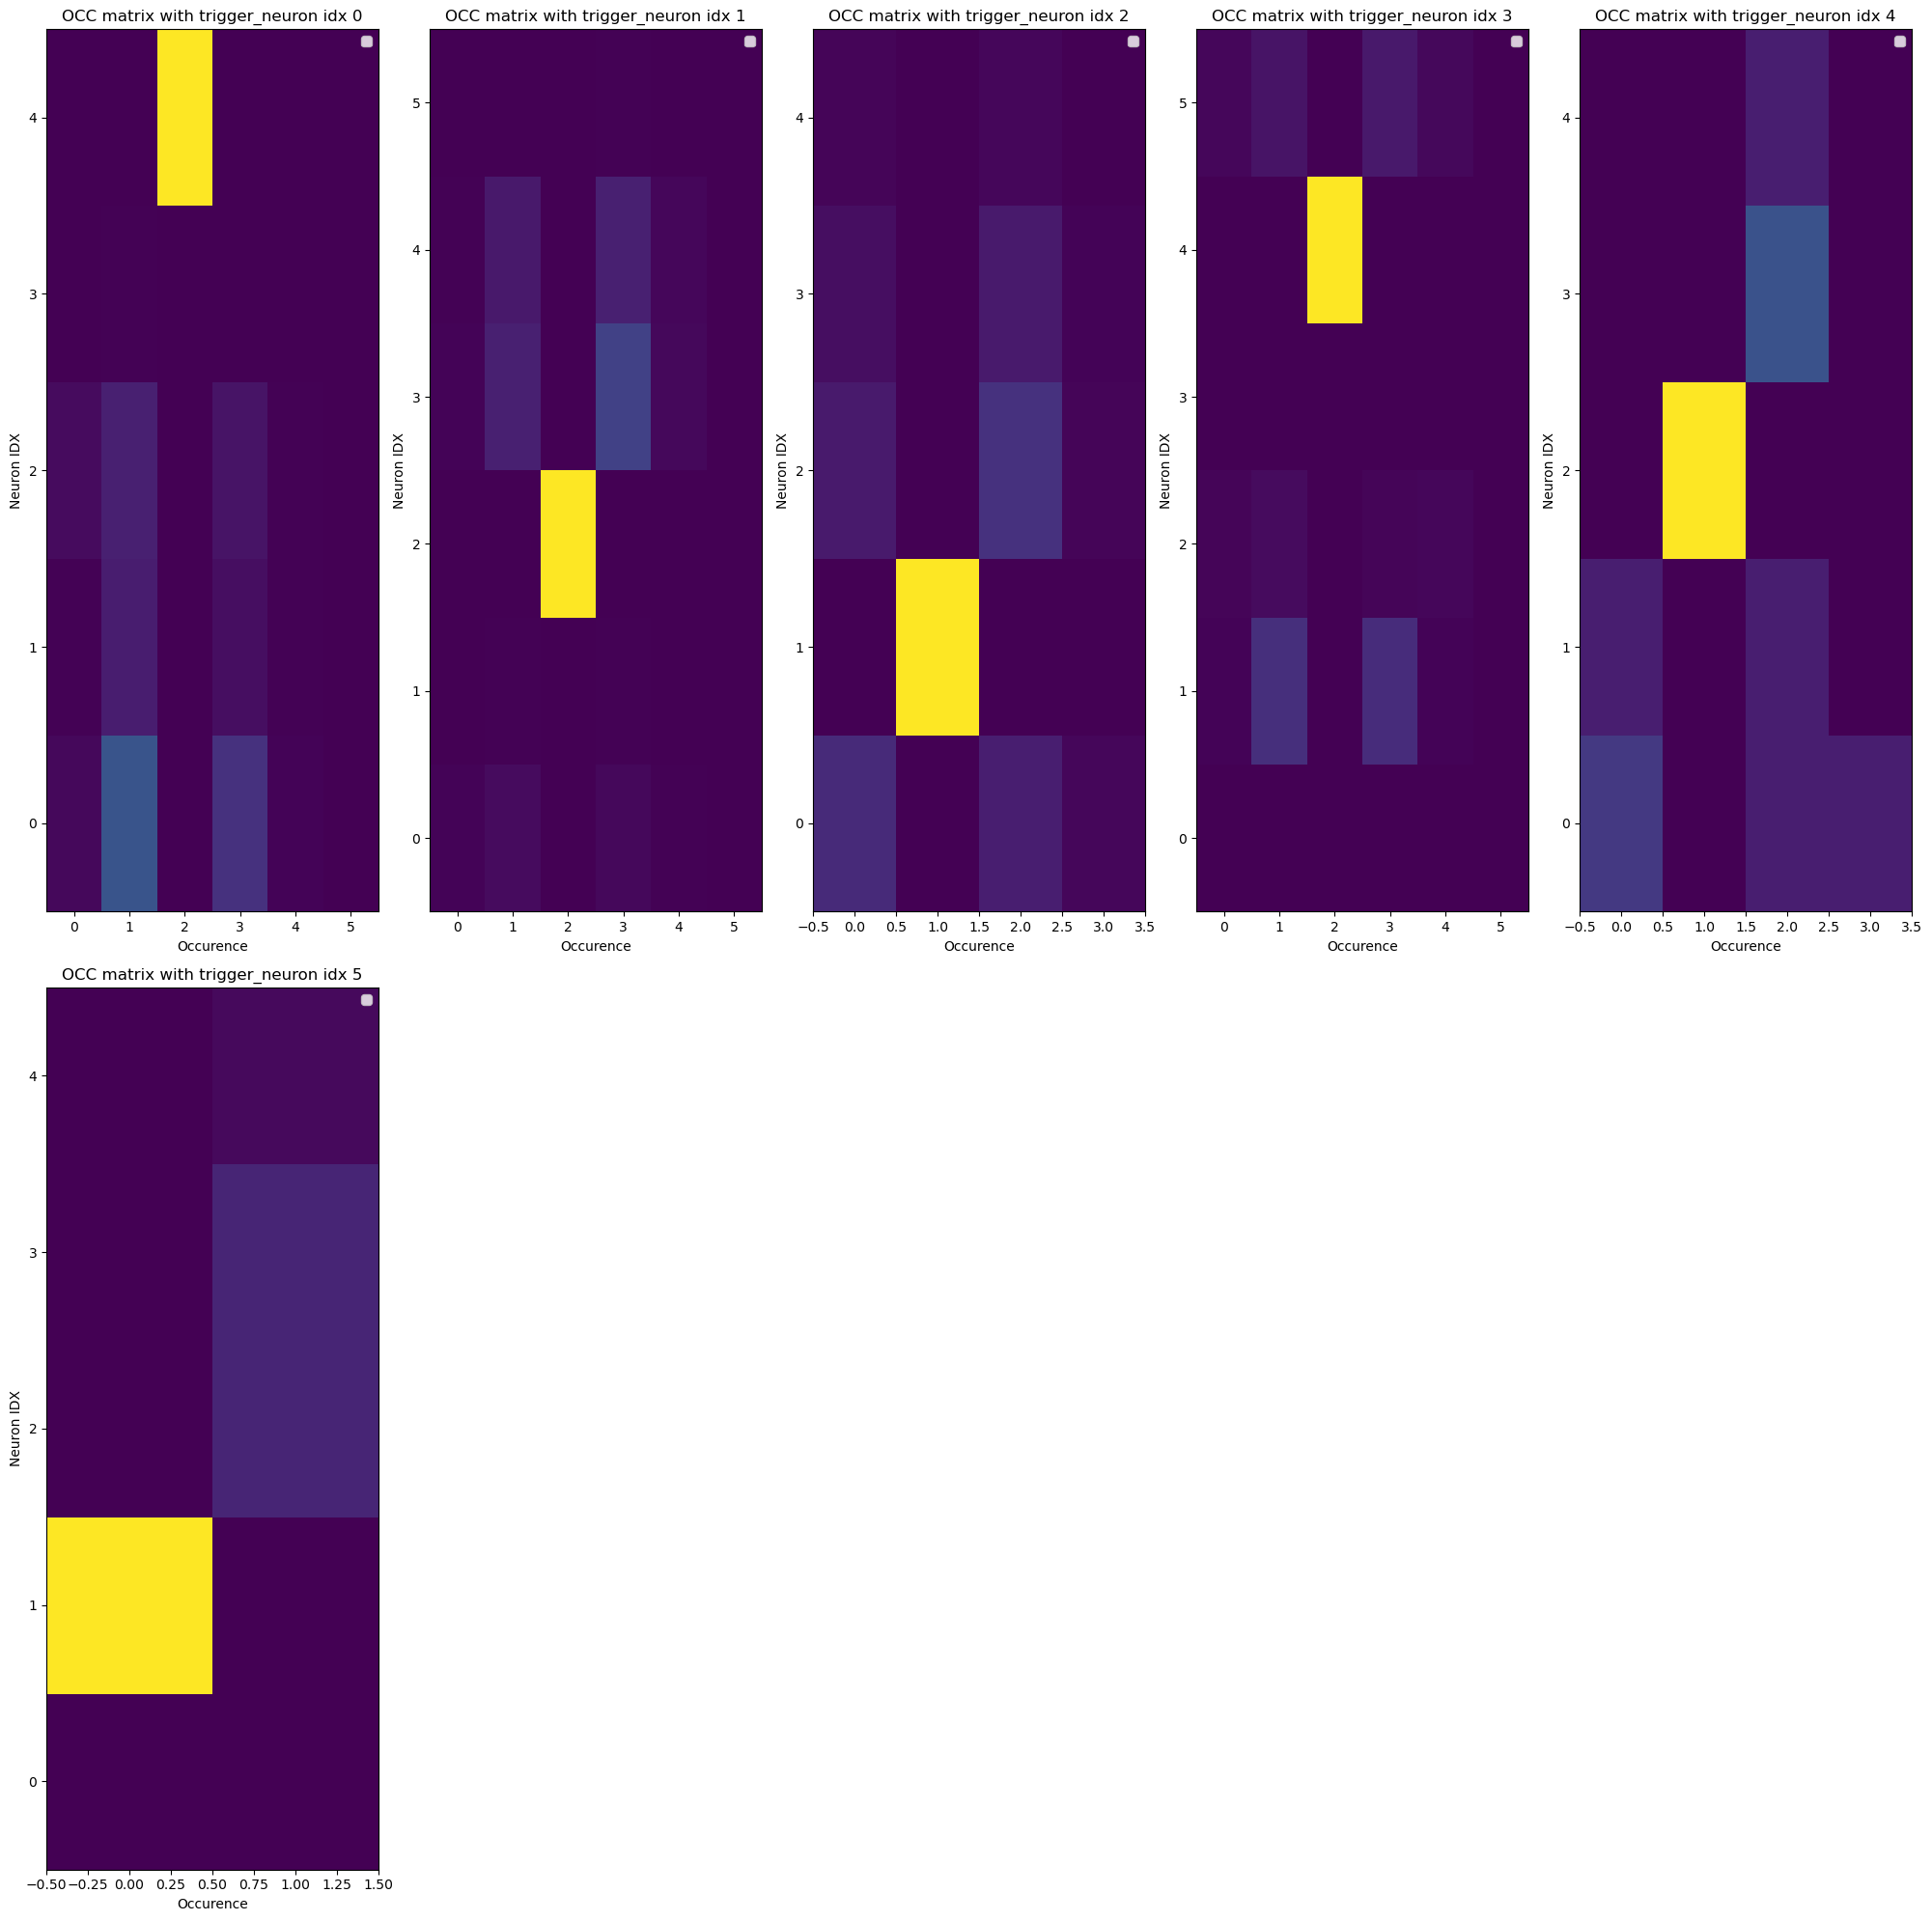

In [37]:
for session, matrices in results_per_session_rat10_middle_split.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    print(session)
    def plot_occs(occ_matrix, ax, neuron_idx):
        ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')
        ax.set_xlabel('Occurence')
        ax.set_ylabel('Neuron IDX')
        ax.set_title(f'OCC matrix with trigger_neuron idx {neuron_idx}')
        ax.legend()

    num_plots = len(occ)
    cols = 5
    rows = (num_plots + cols - 1) // cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
    axes = axes.flatten()  # Flatten to make indexing easier
    
    # Loop through and plot
    for i in range(len(occ)):
        plot_occs(occ[i], axes[i], i)
    
    # Hide unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Rat10-20140622


/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6350/911424948.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6350/911424948.py:8: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')


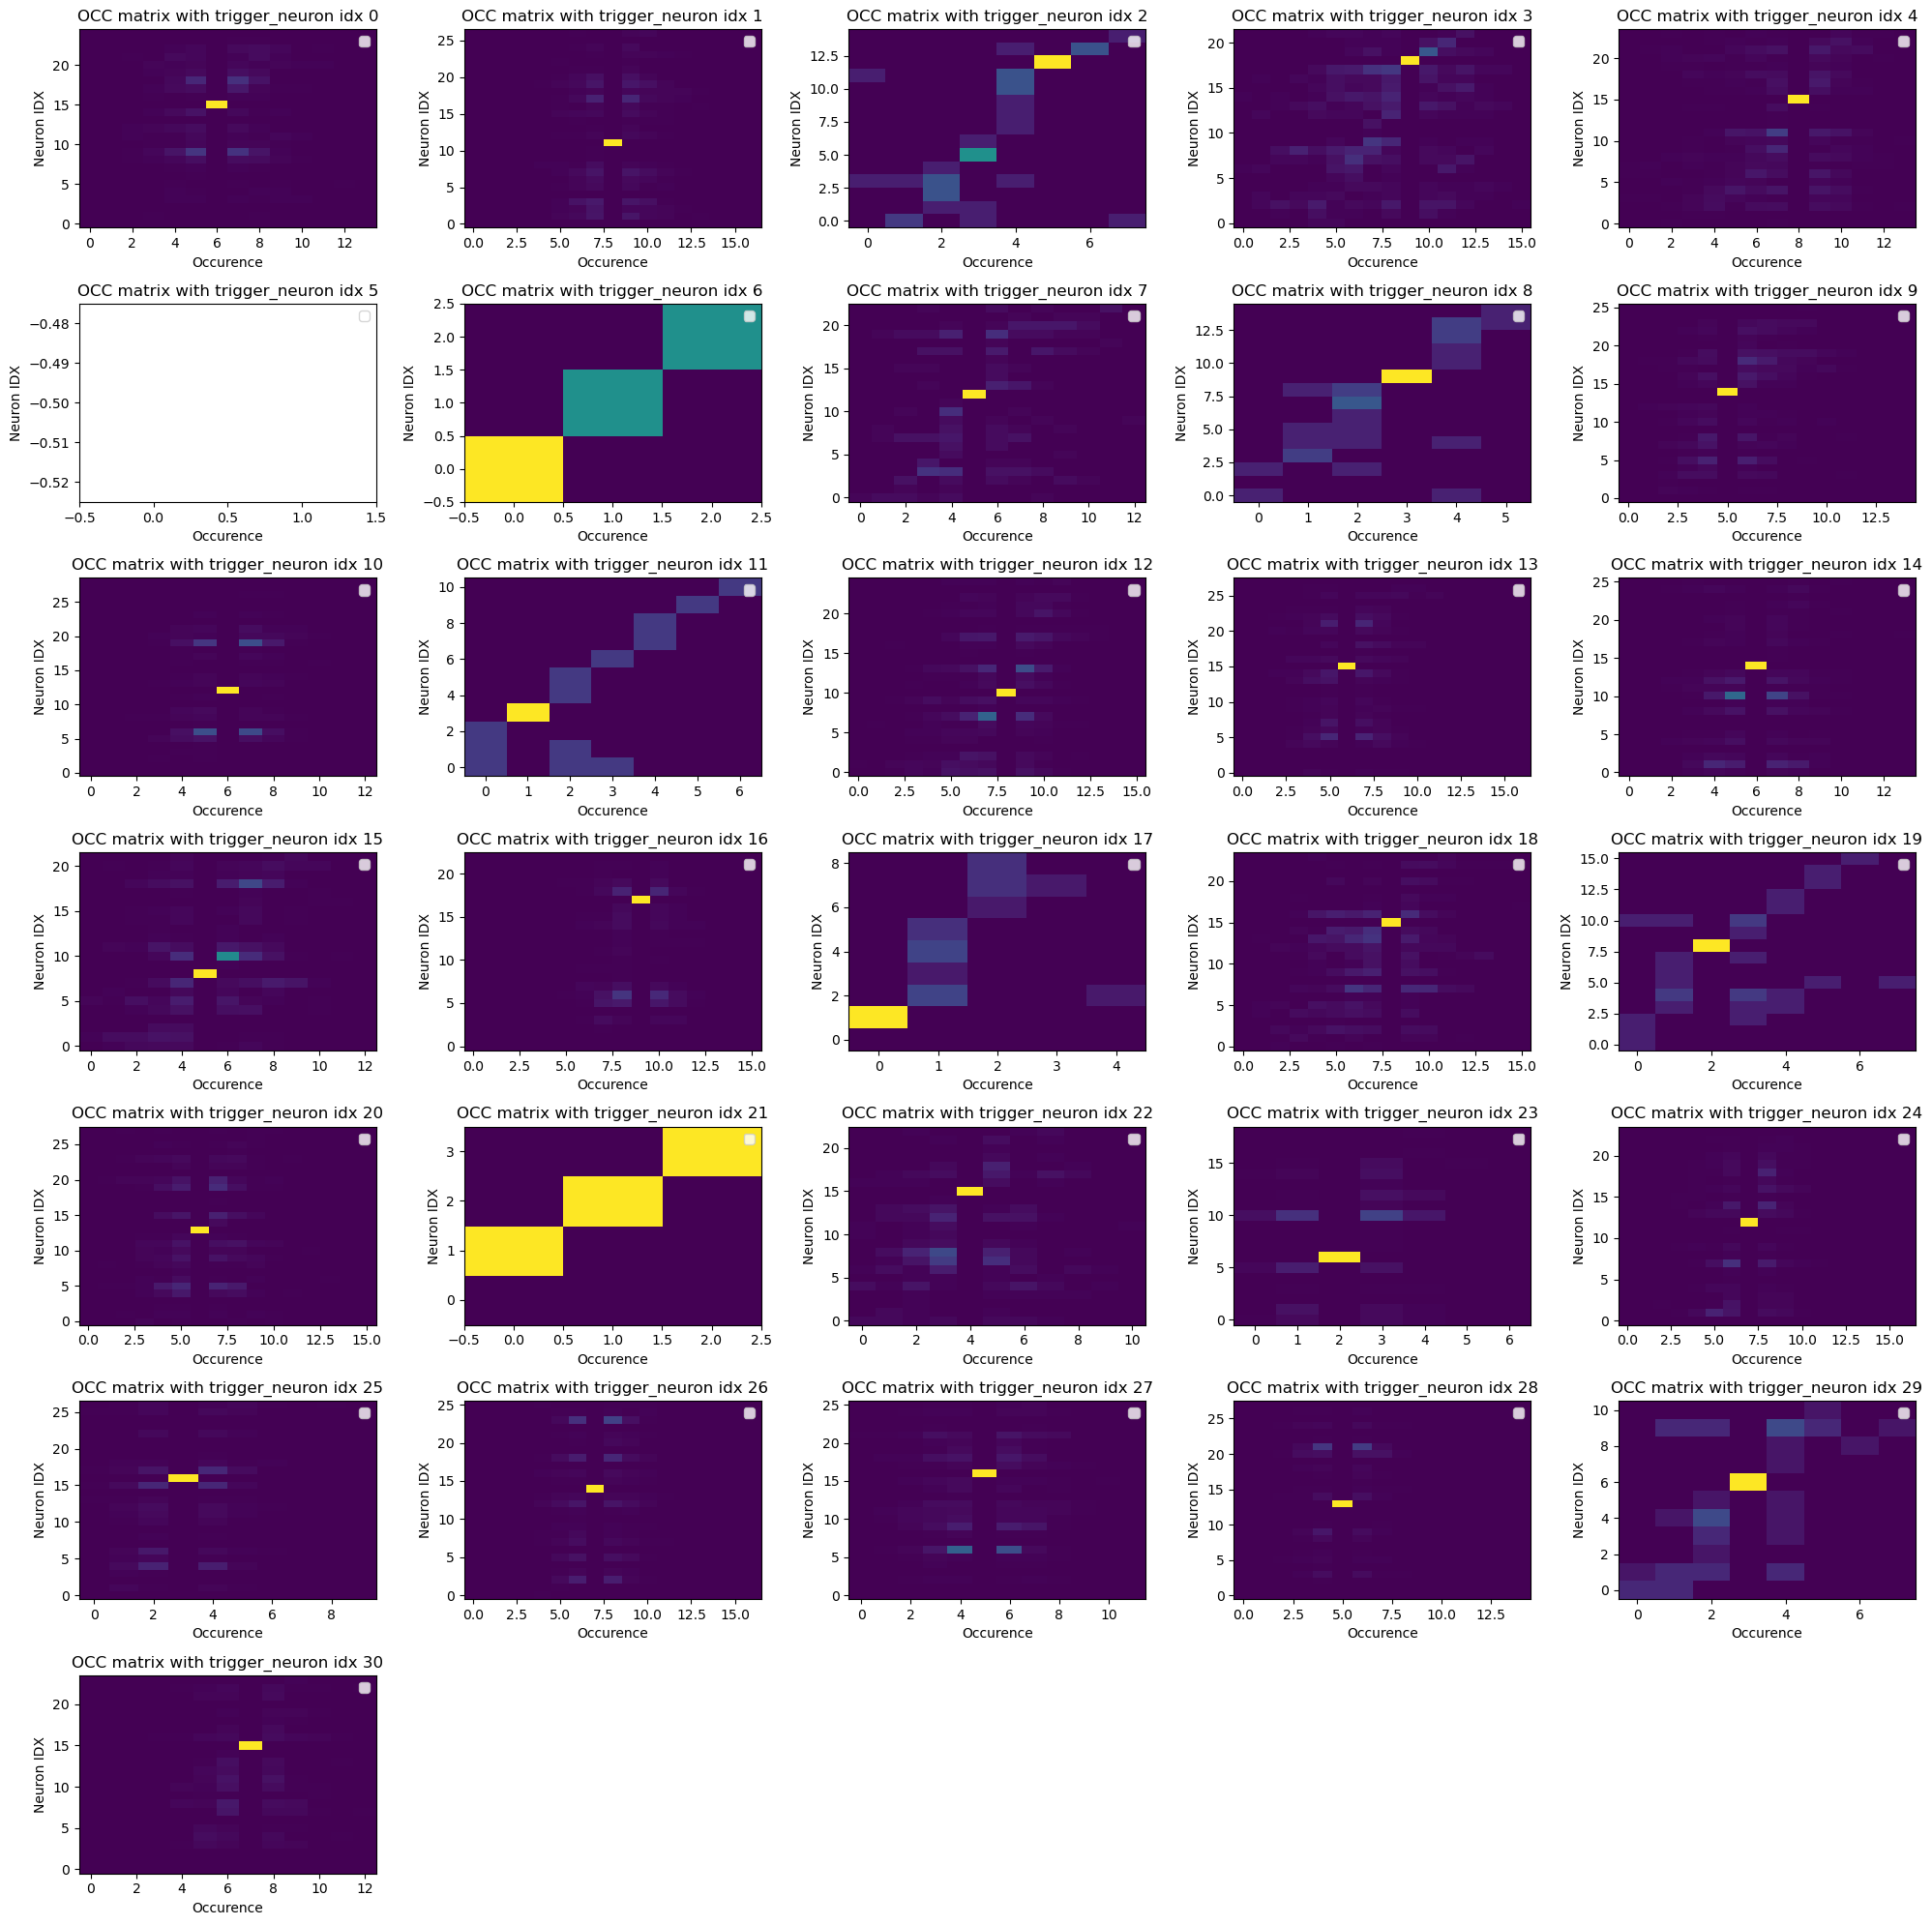

Rat10-20140624


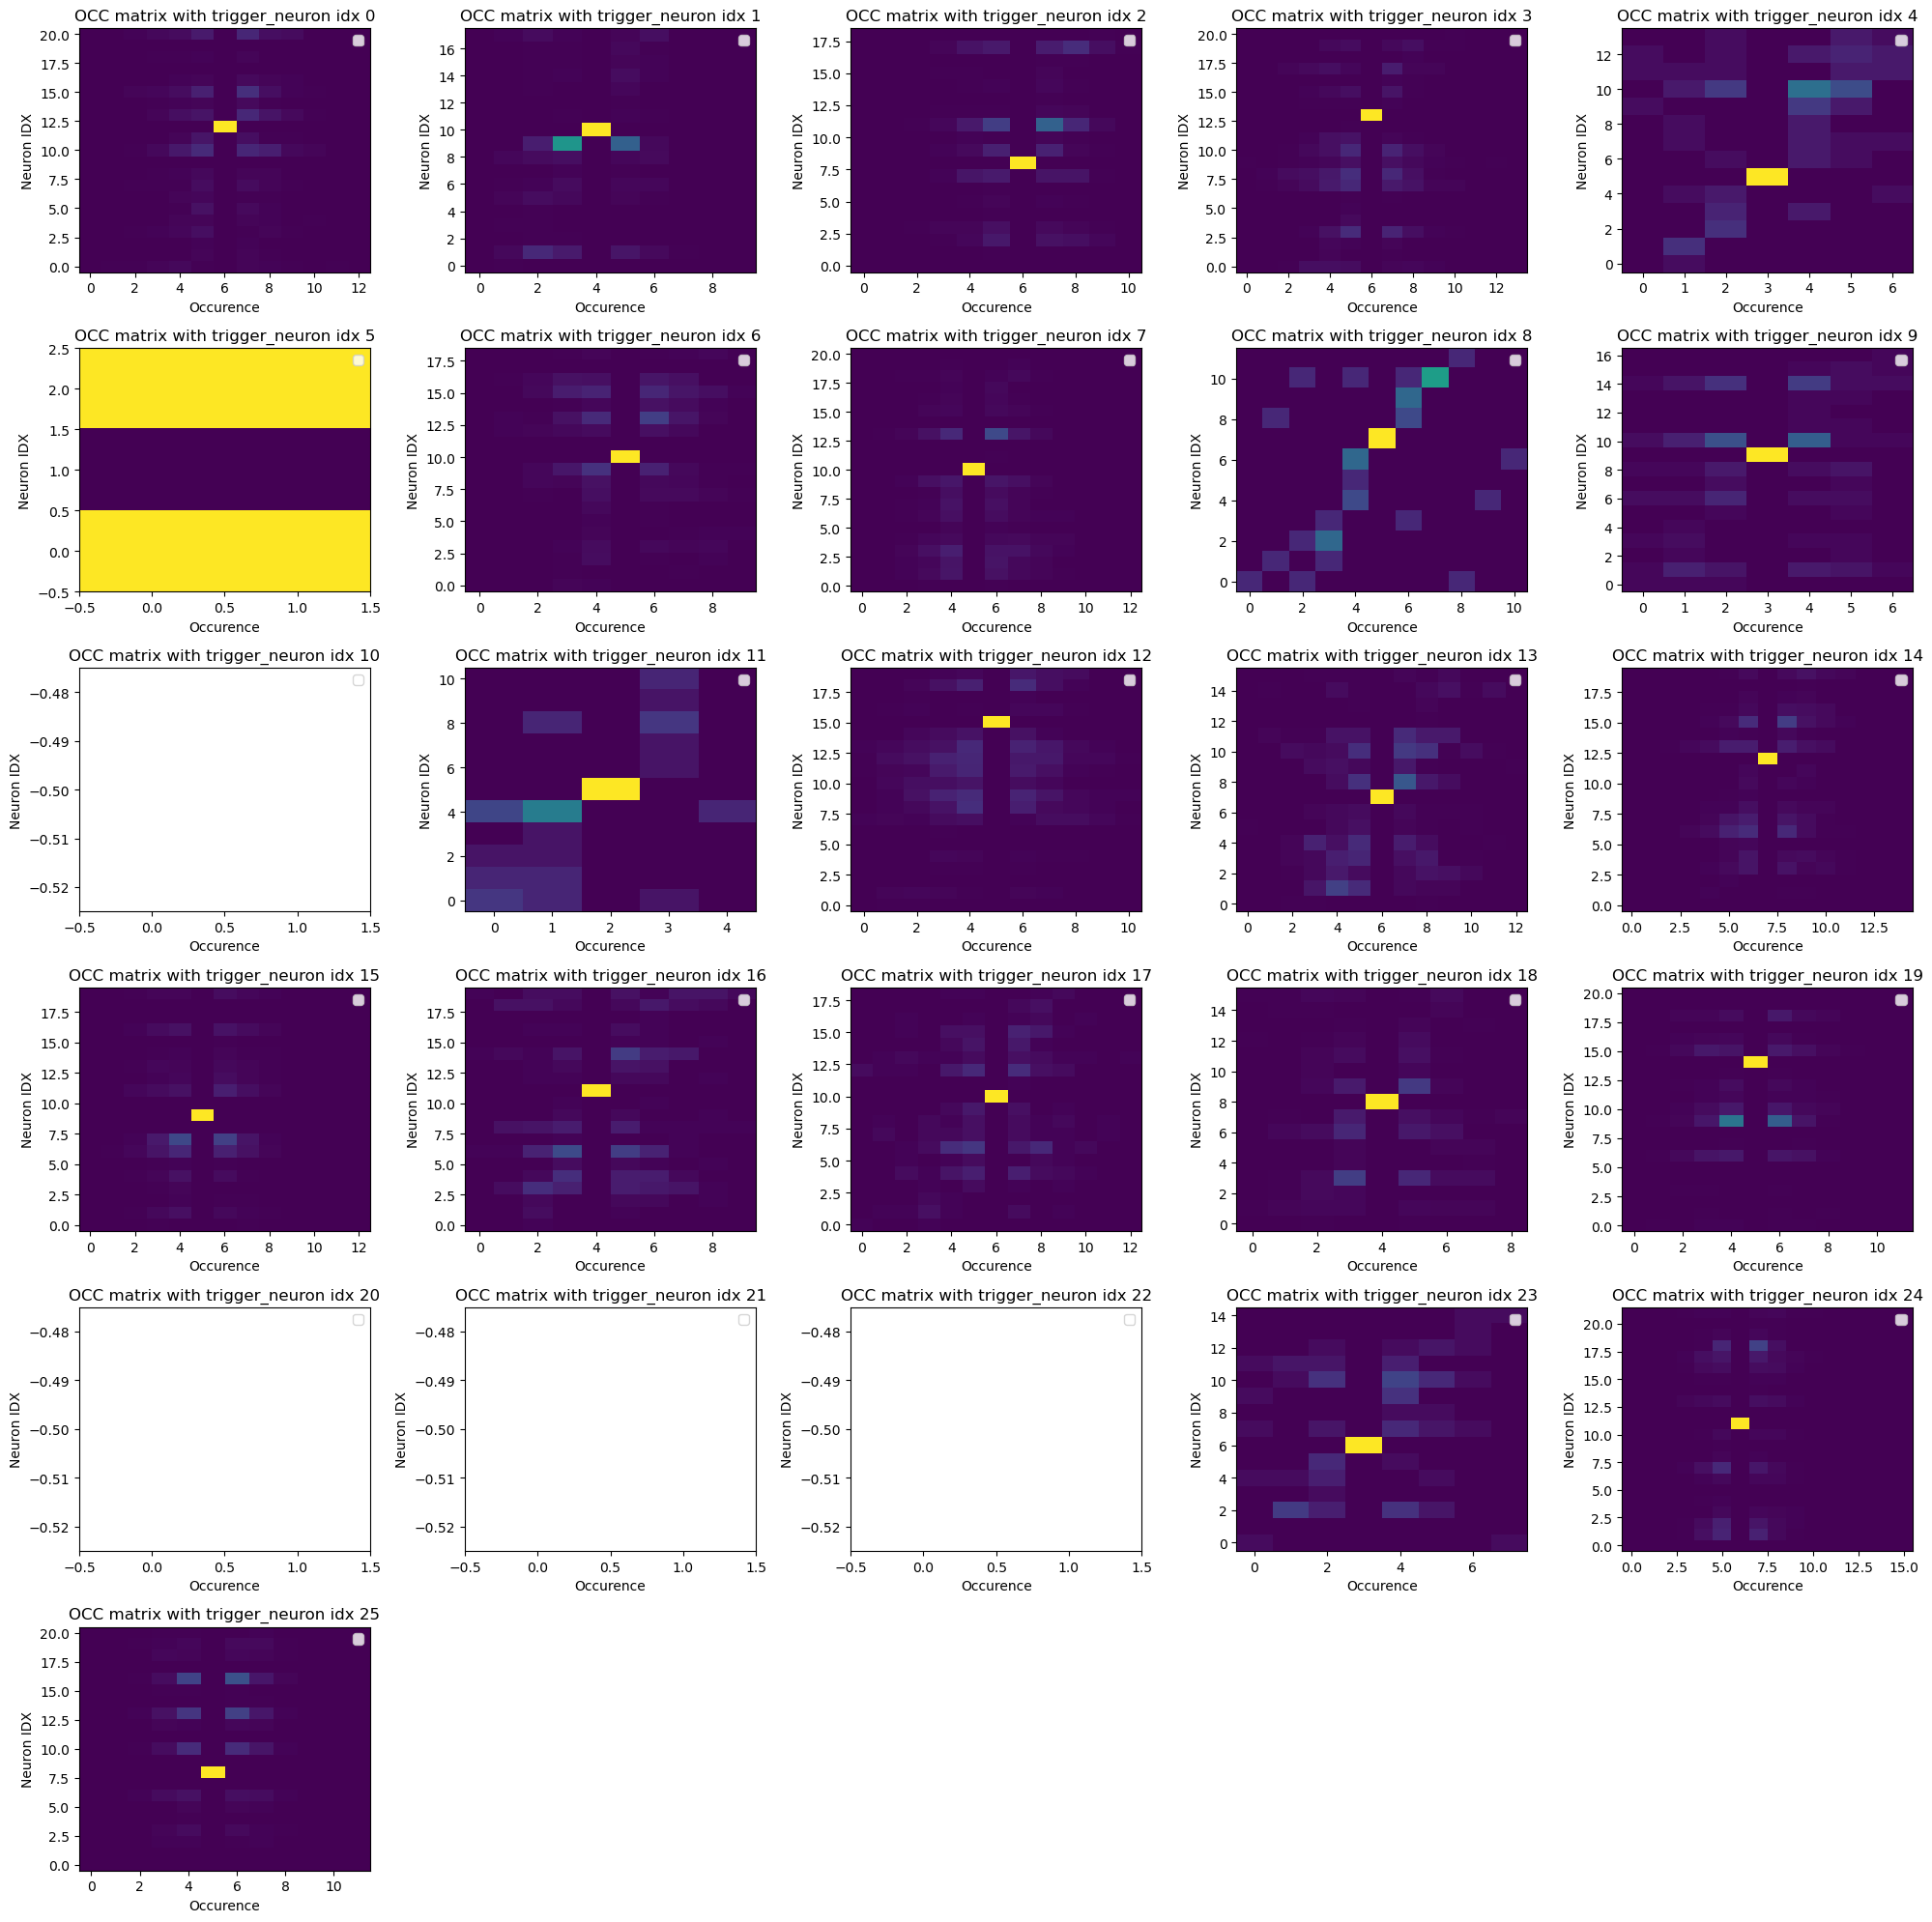

Rat10-20140626


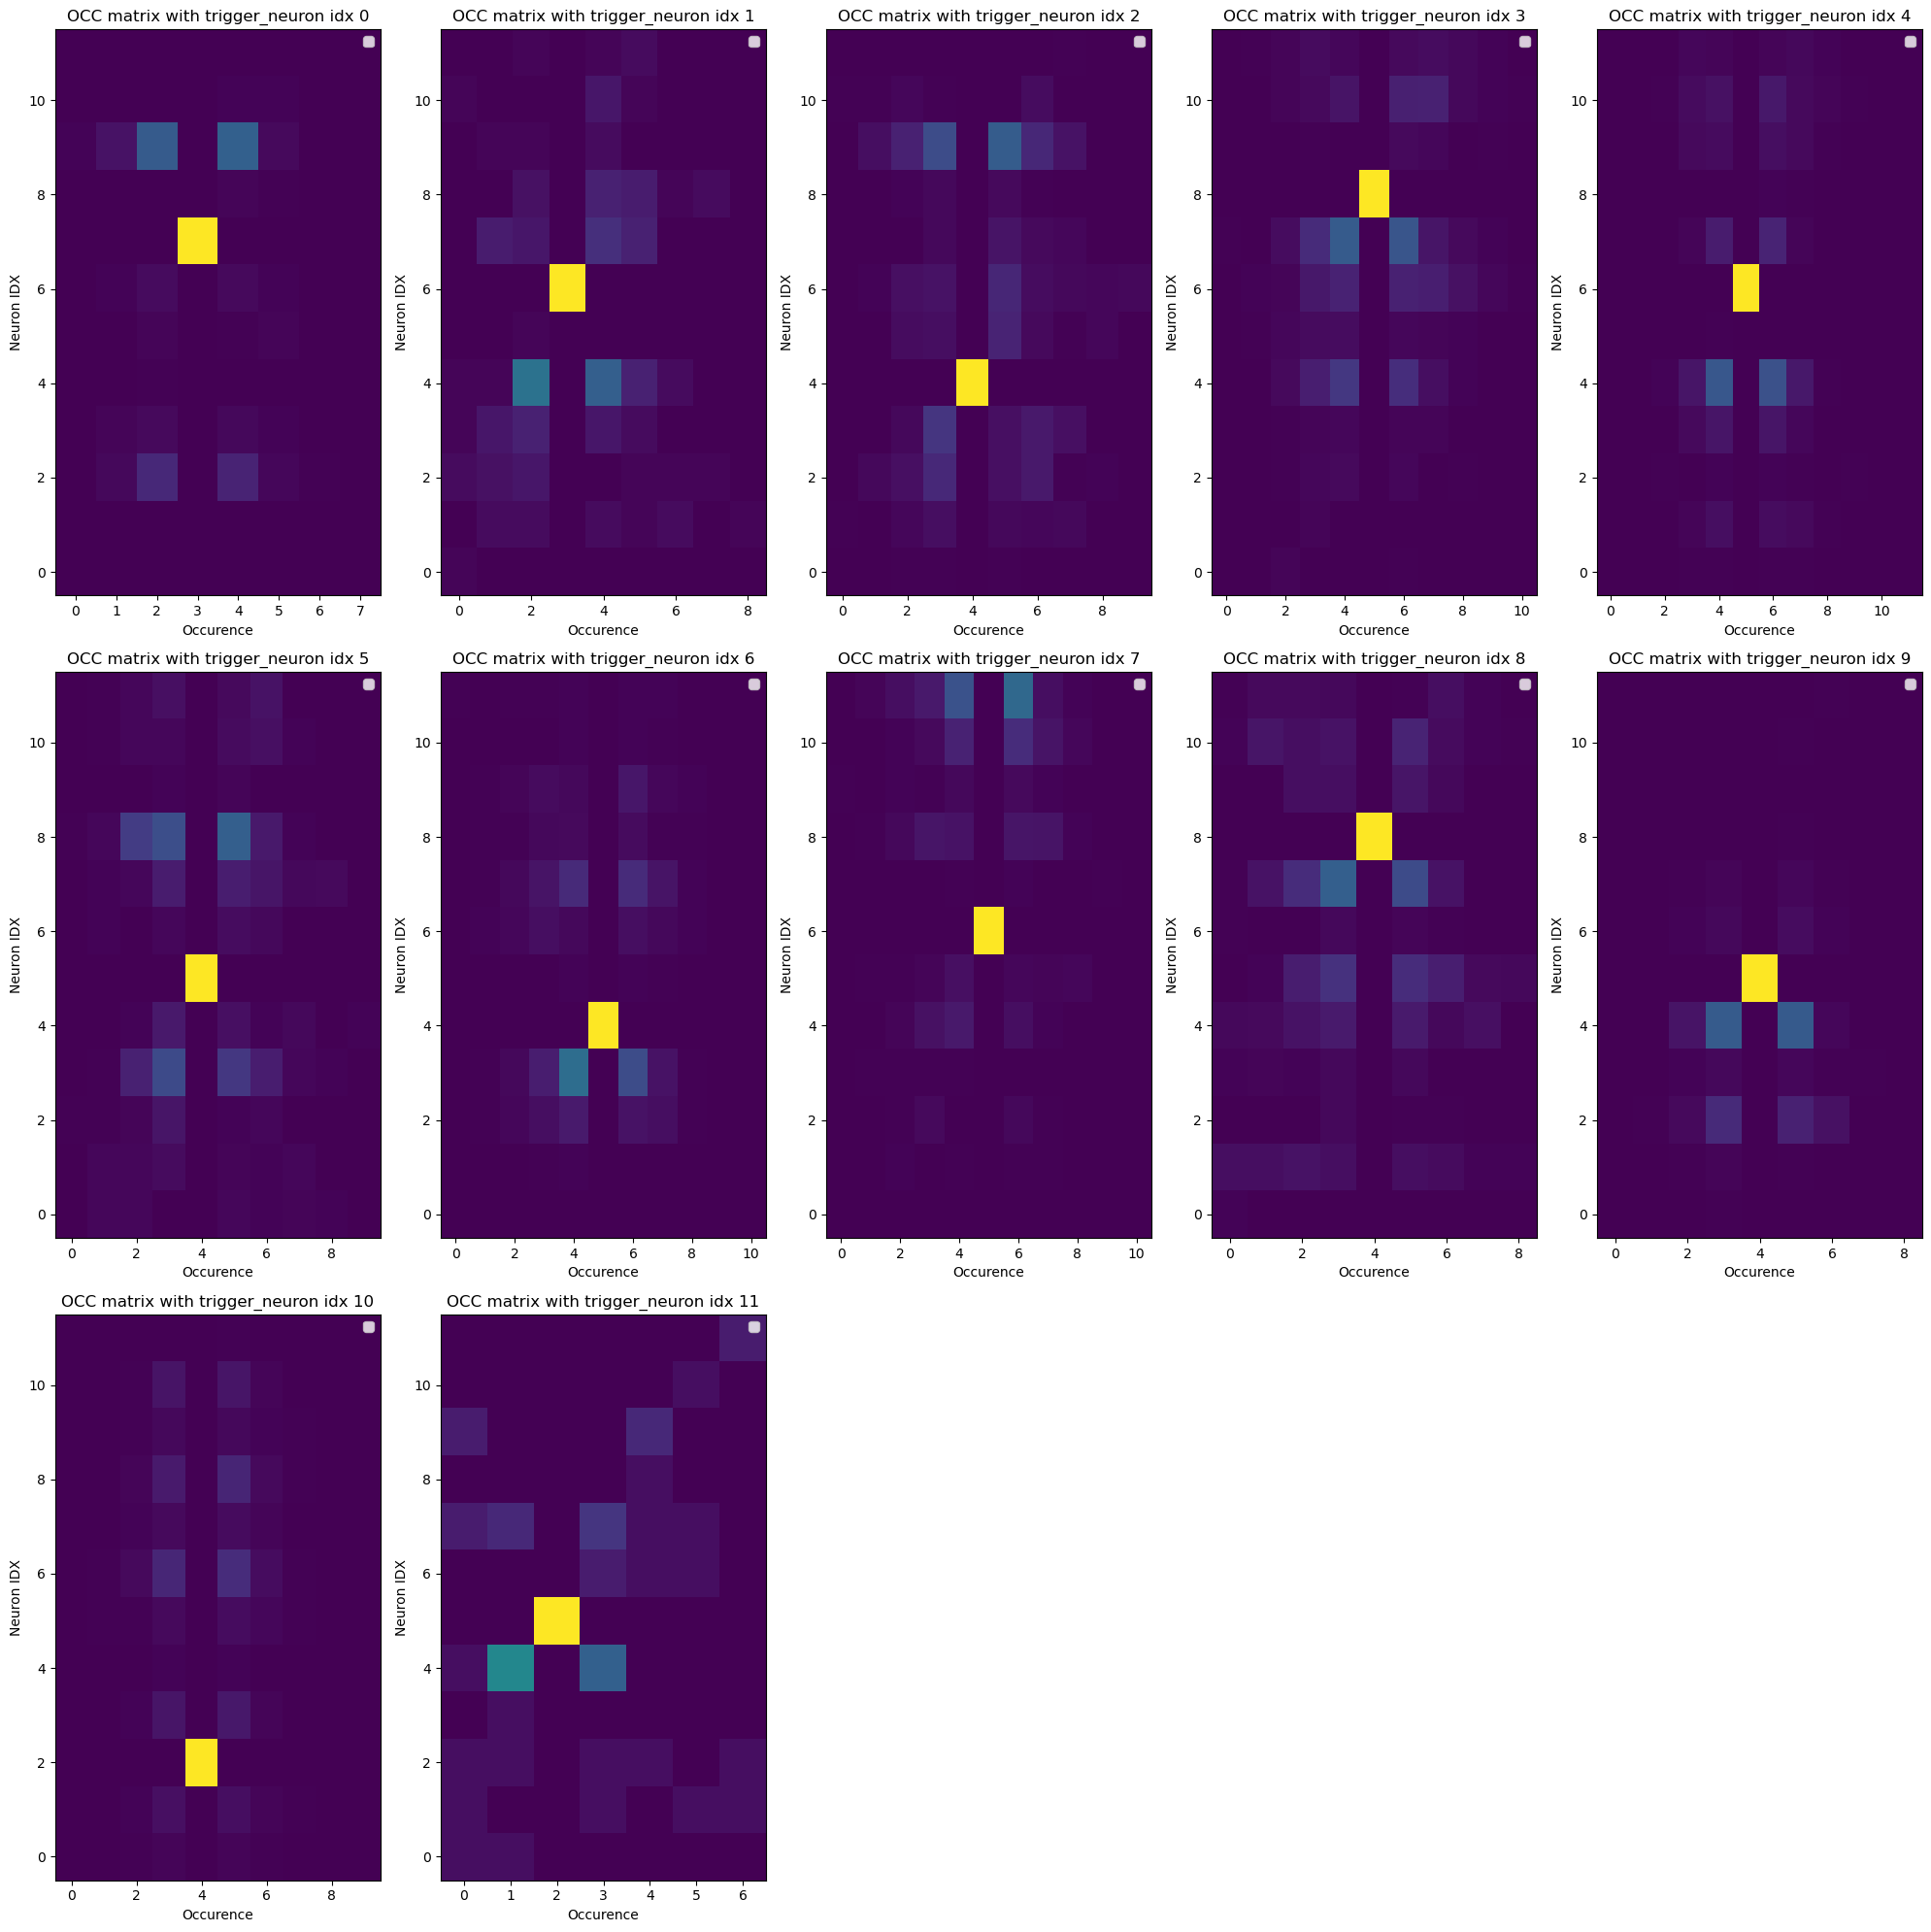

Rat10-20140627


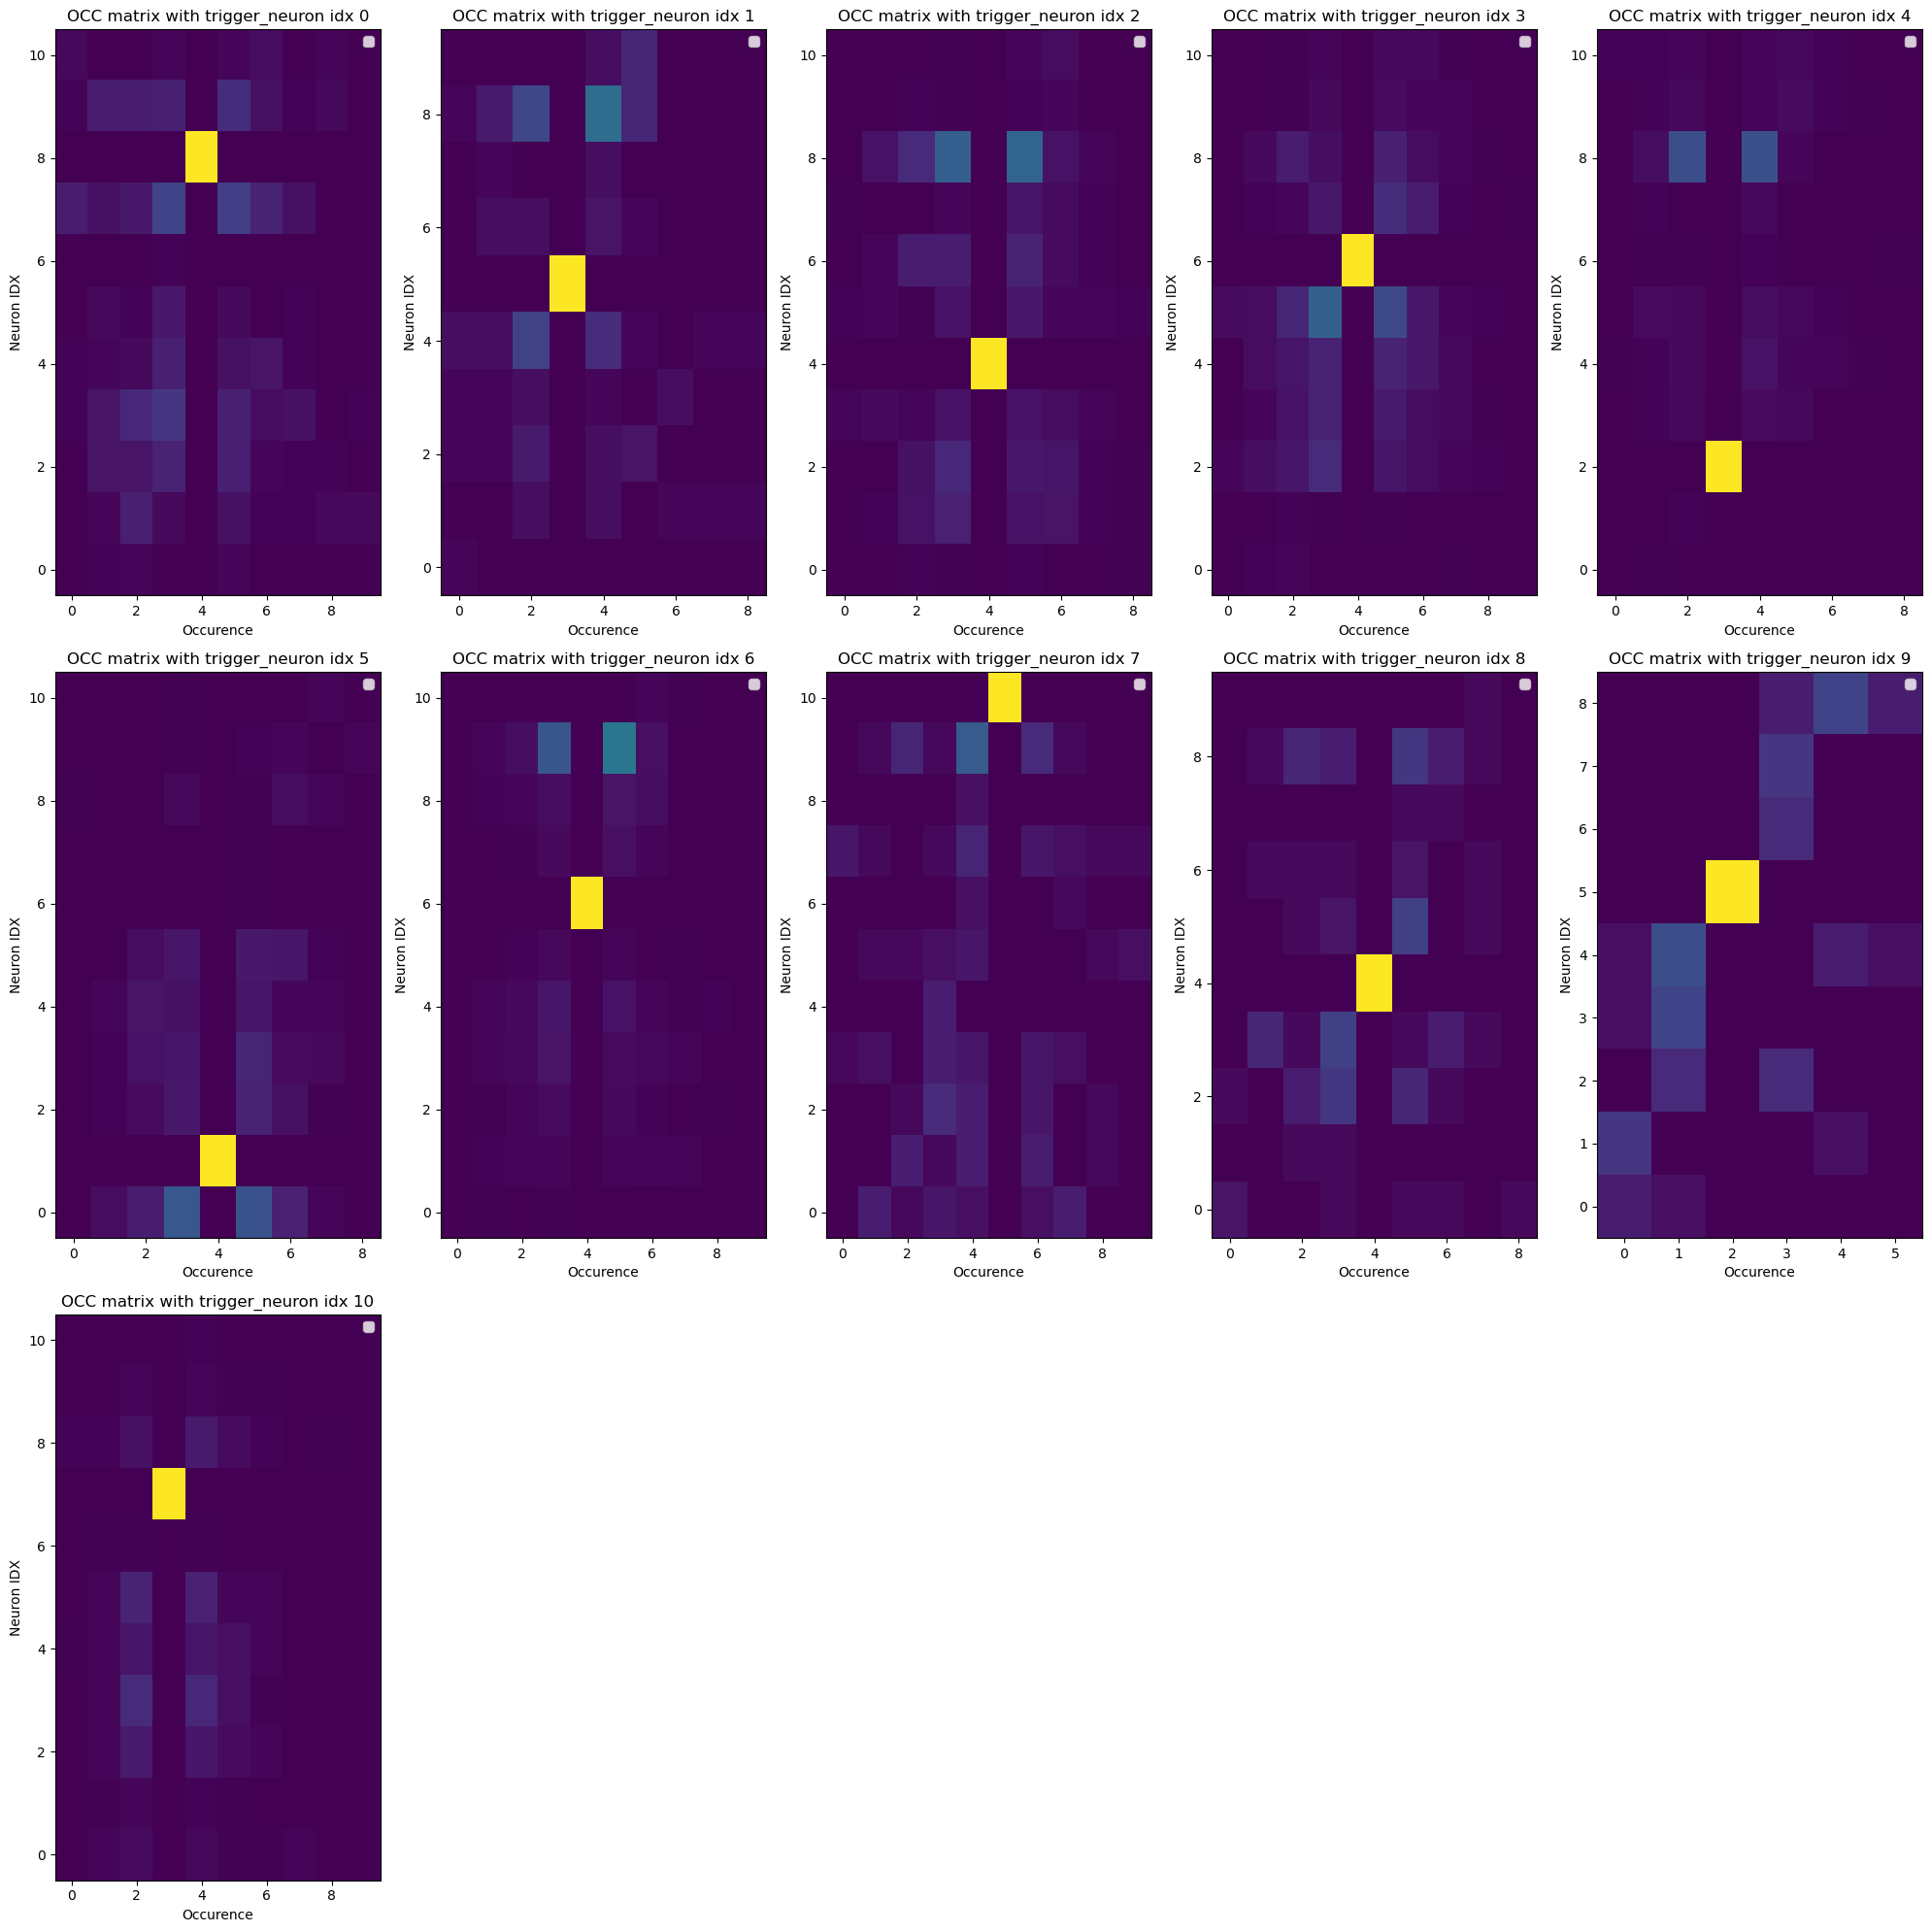

Rat10-20140628


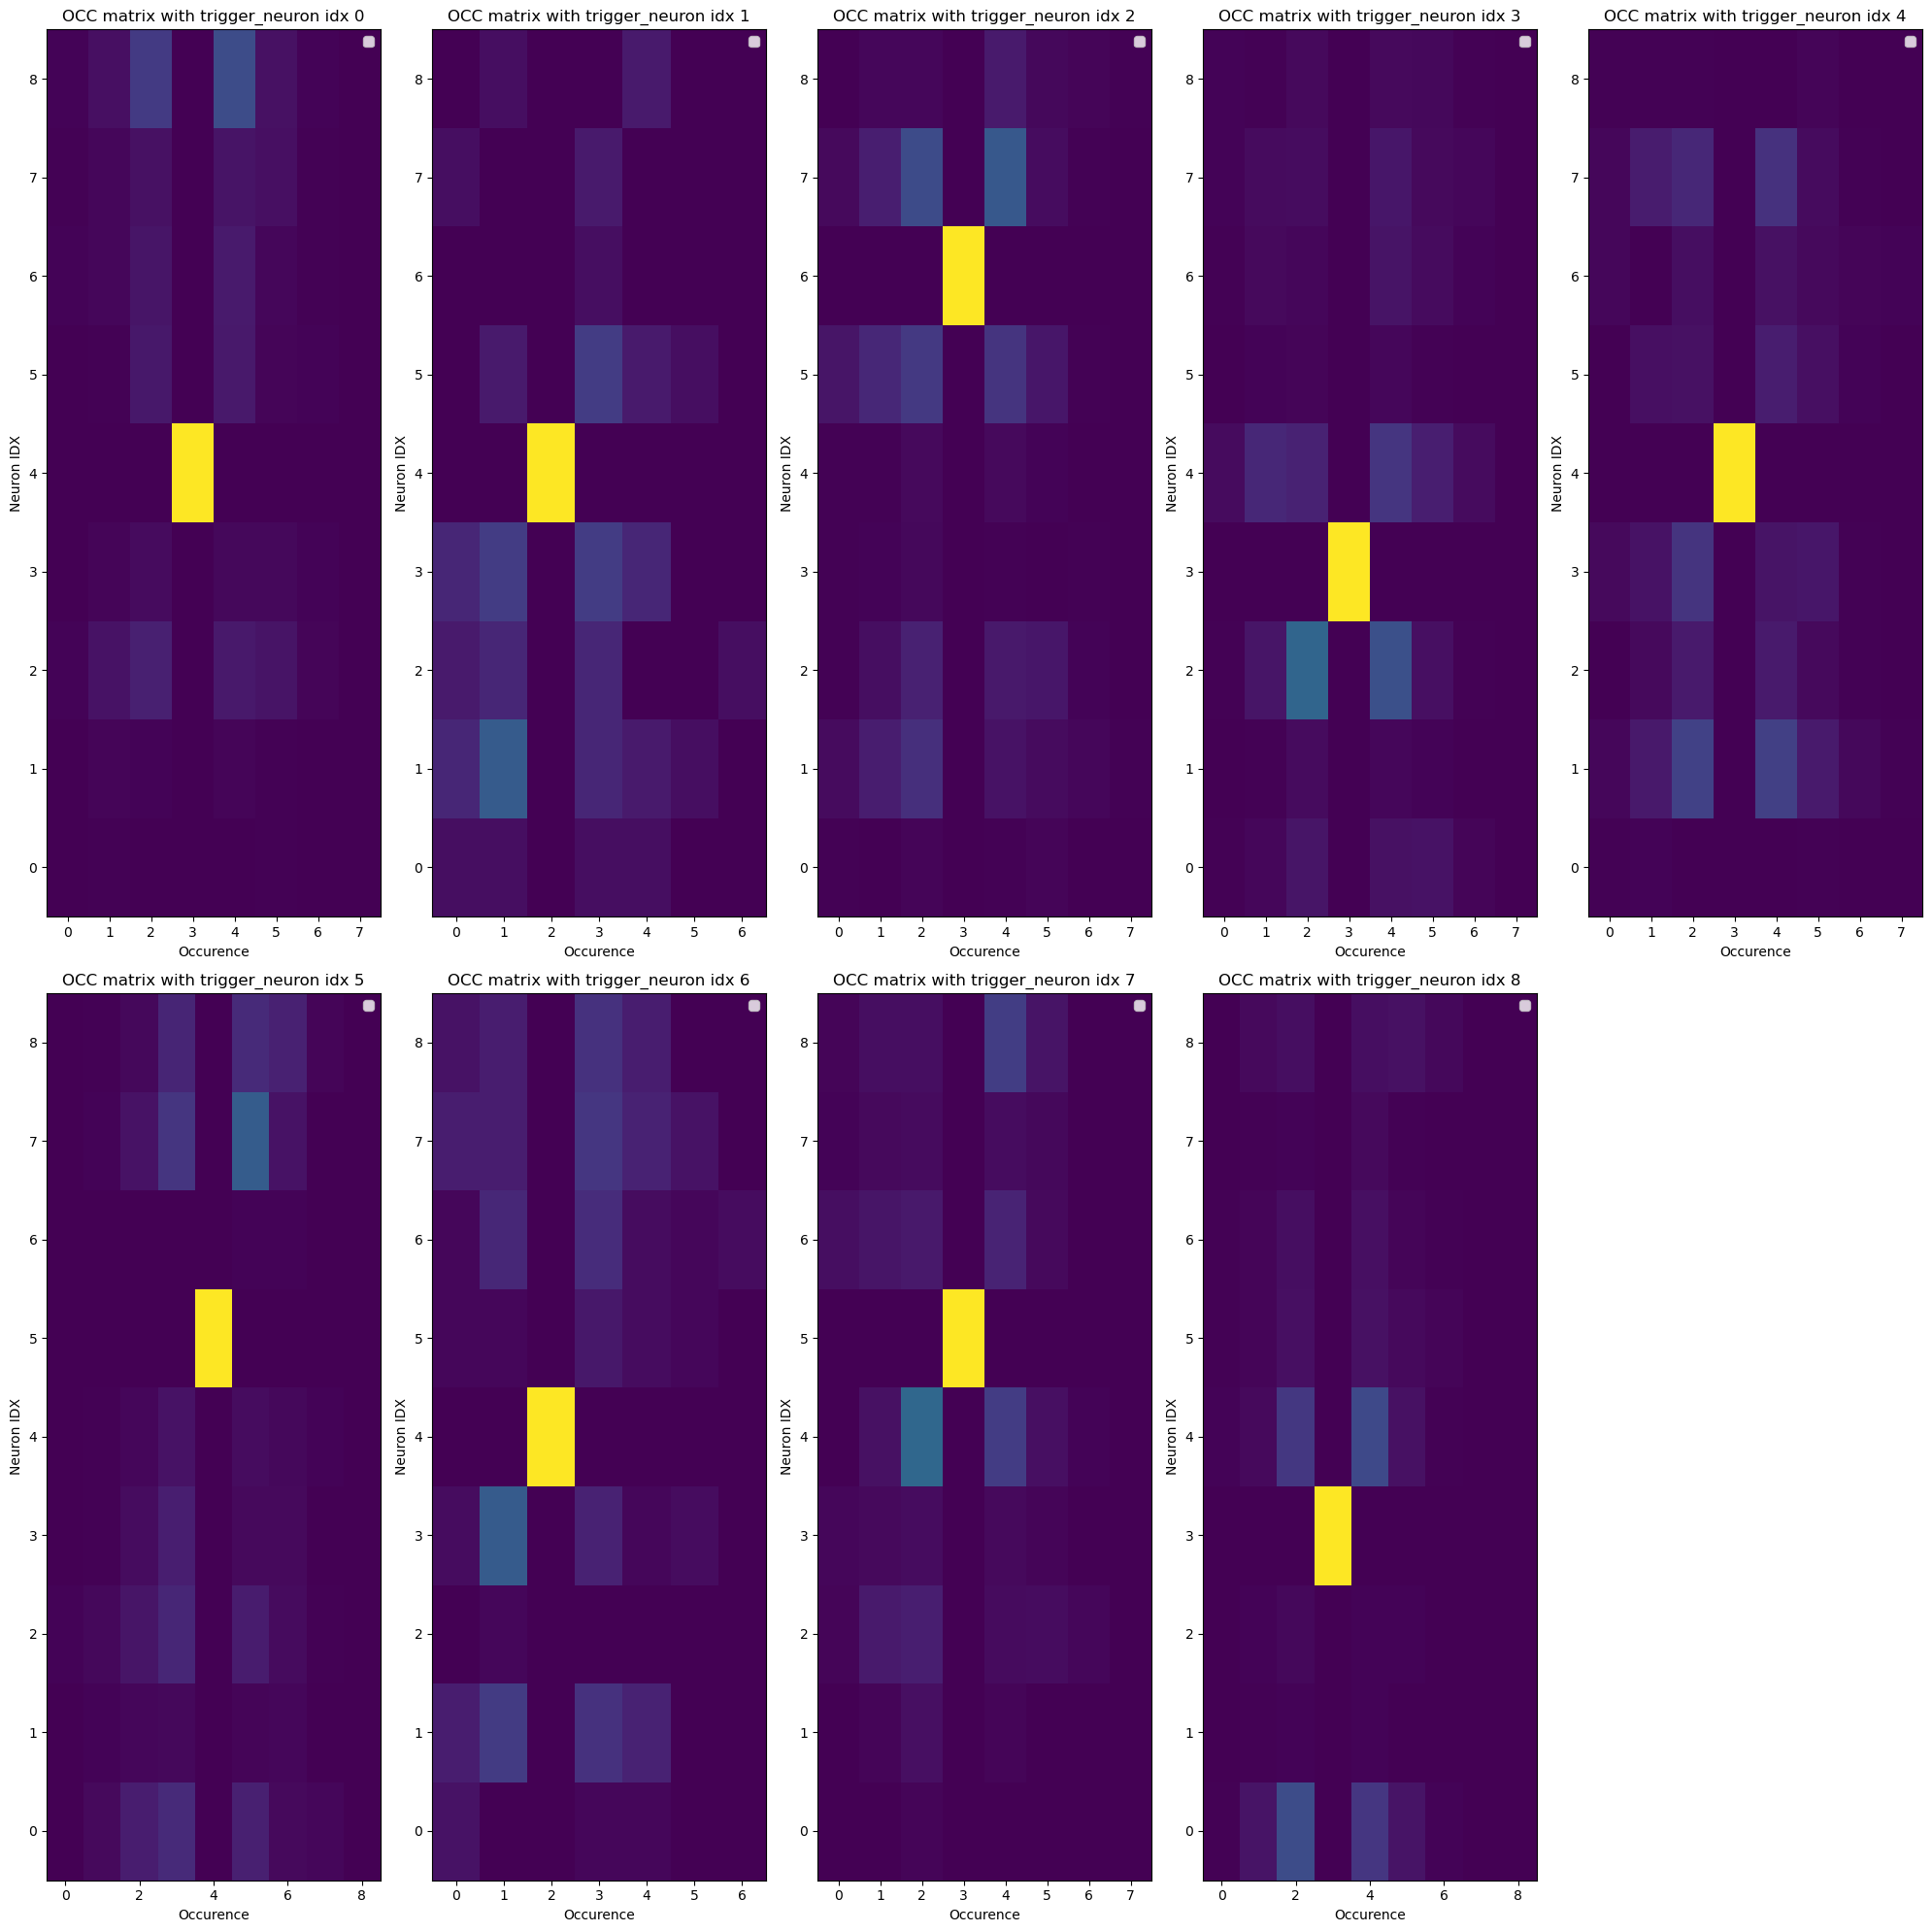

Rat10-20140629


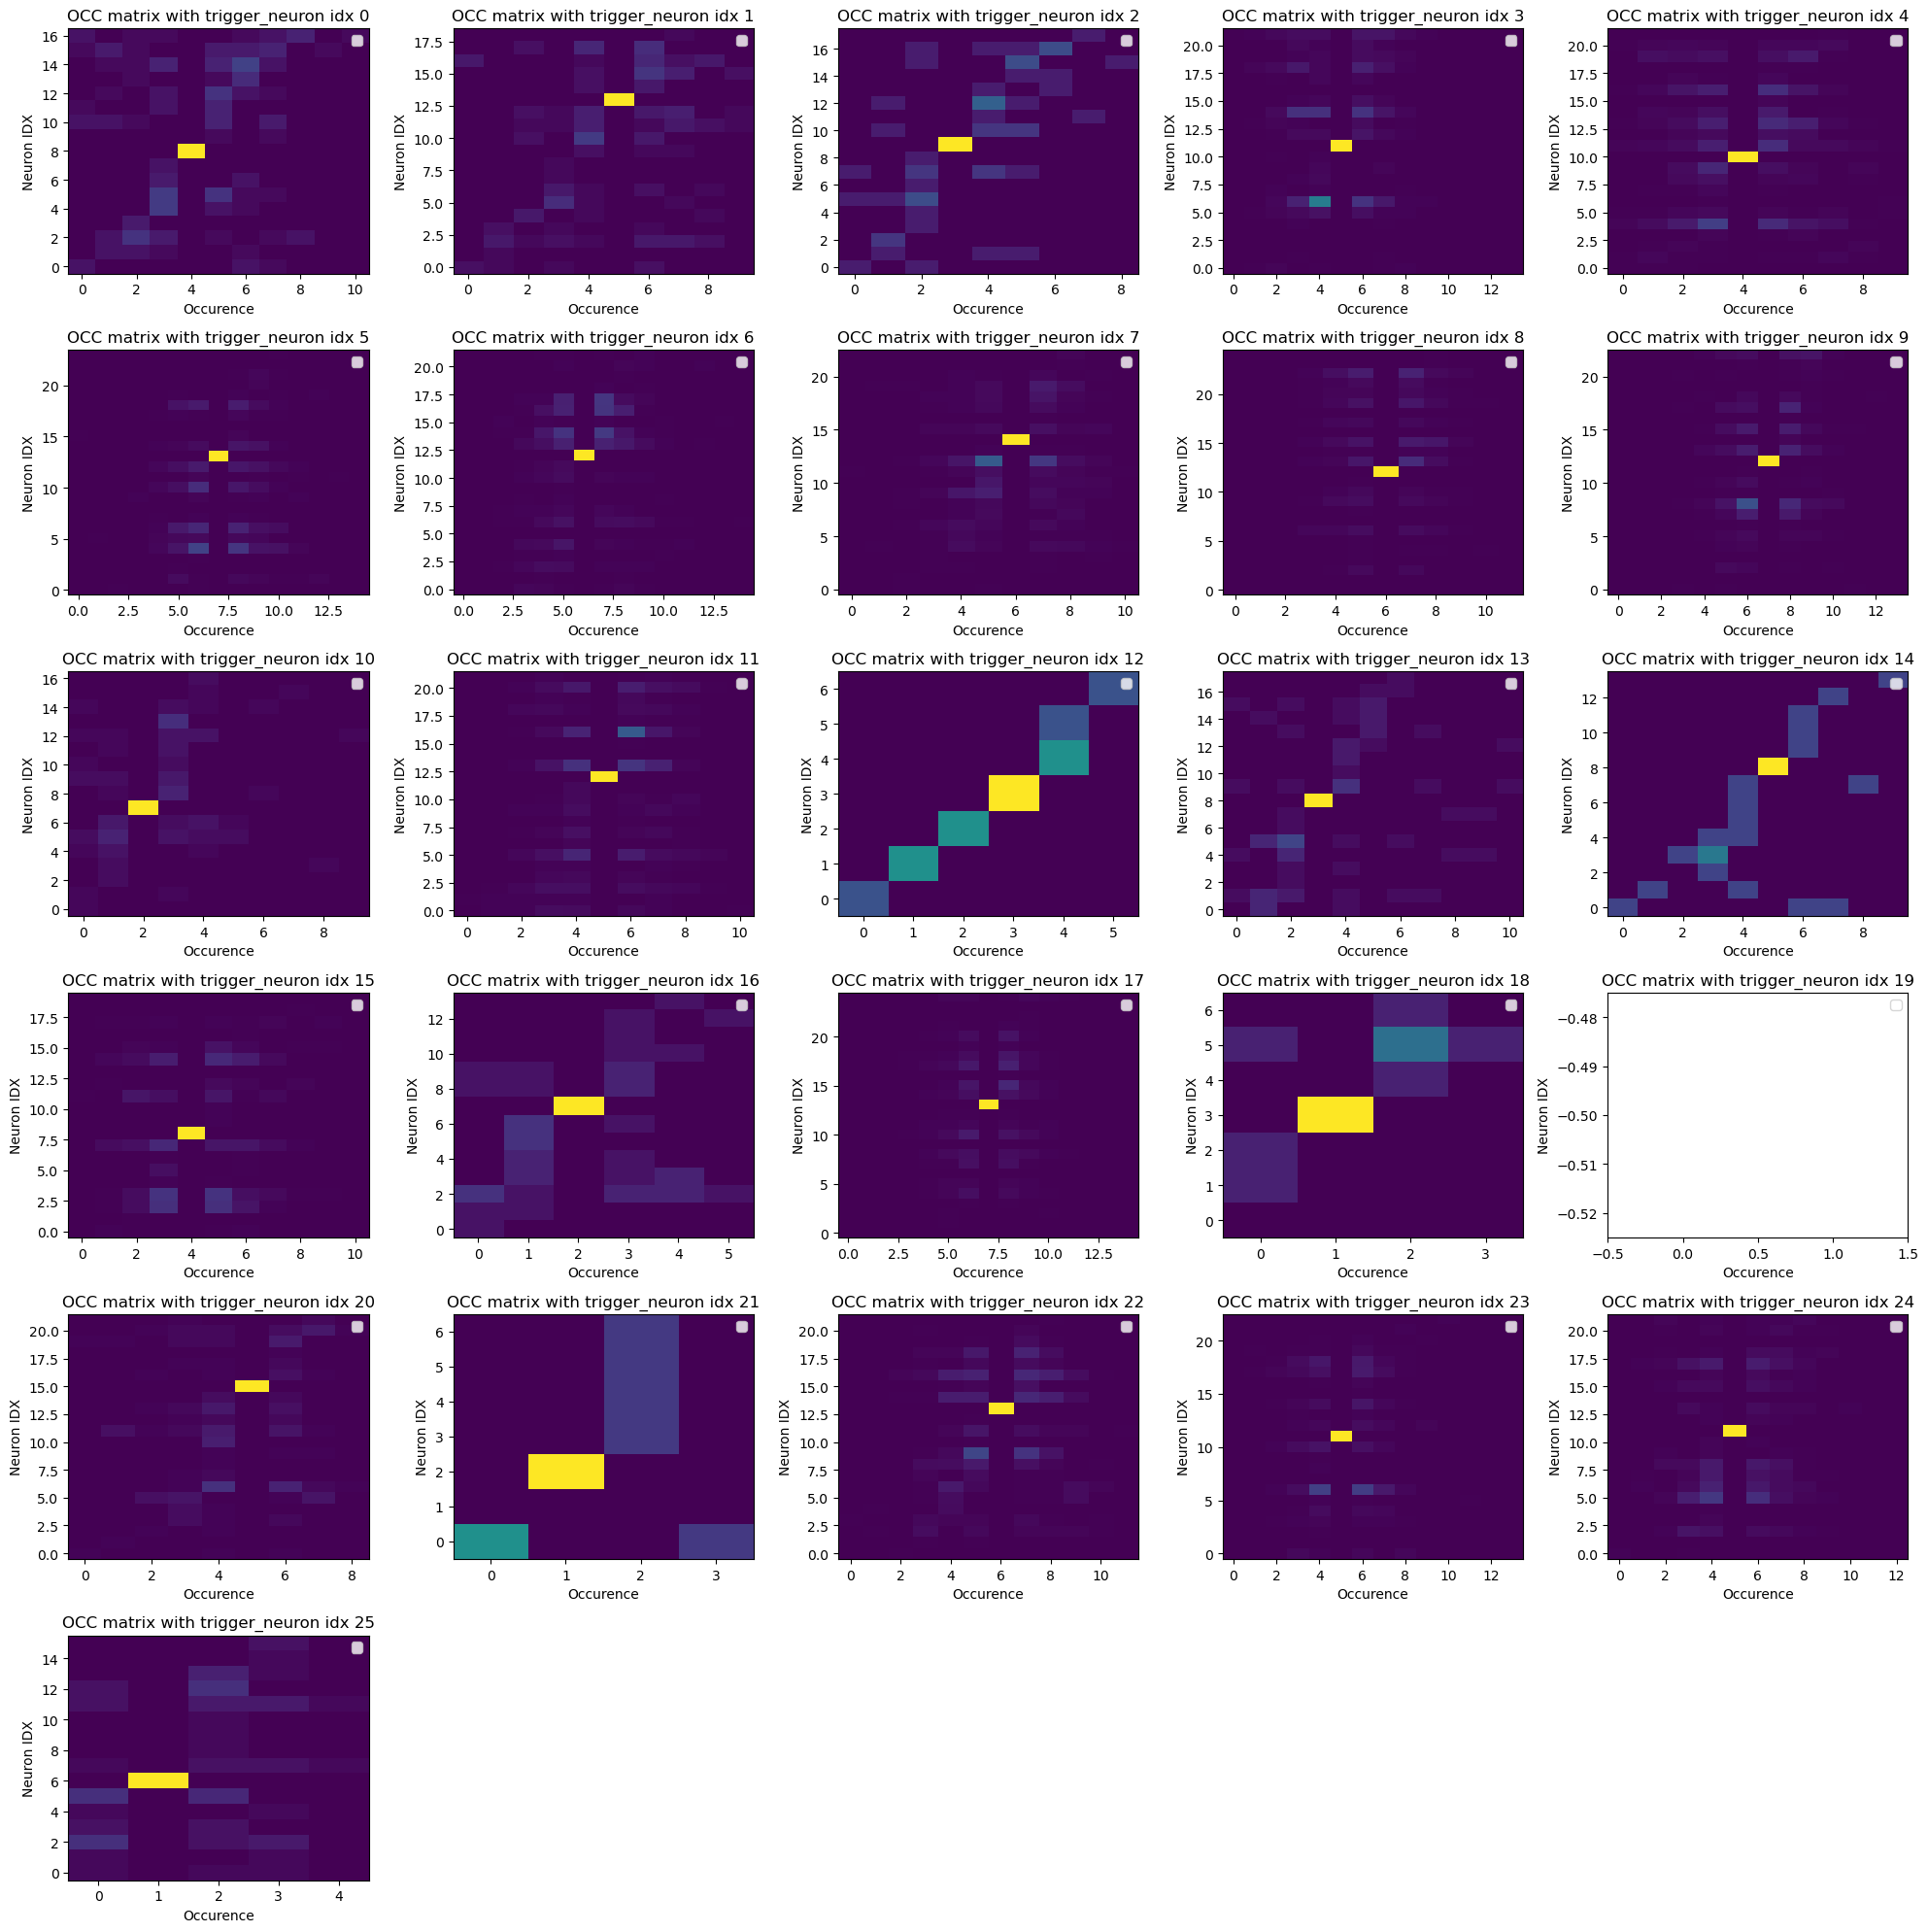

Rat10-20140701


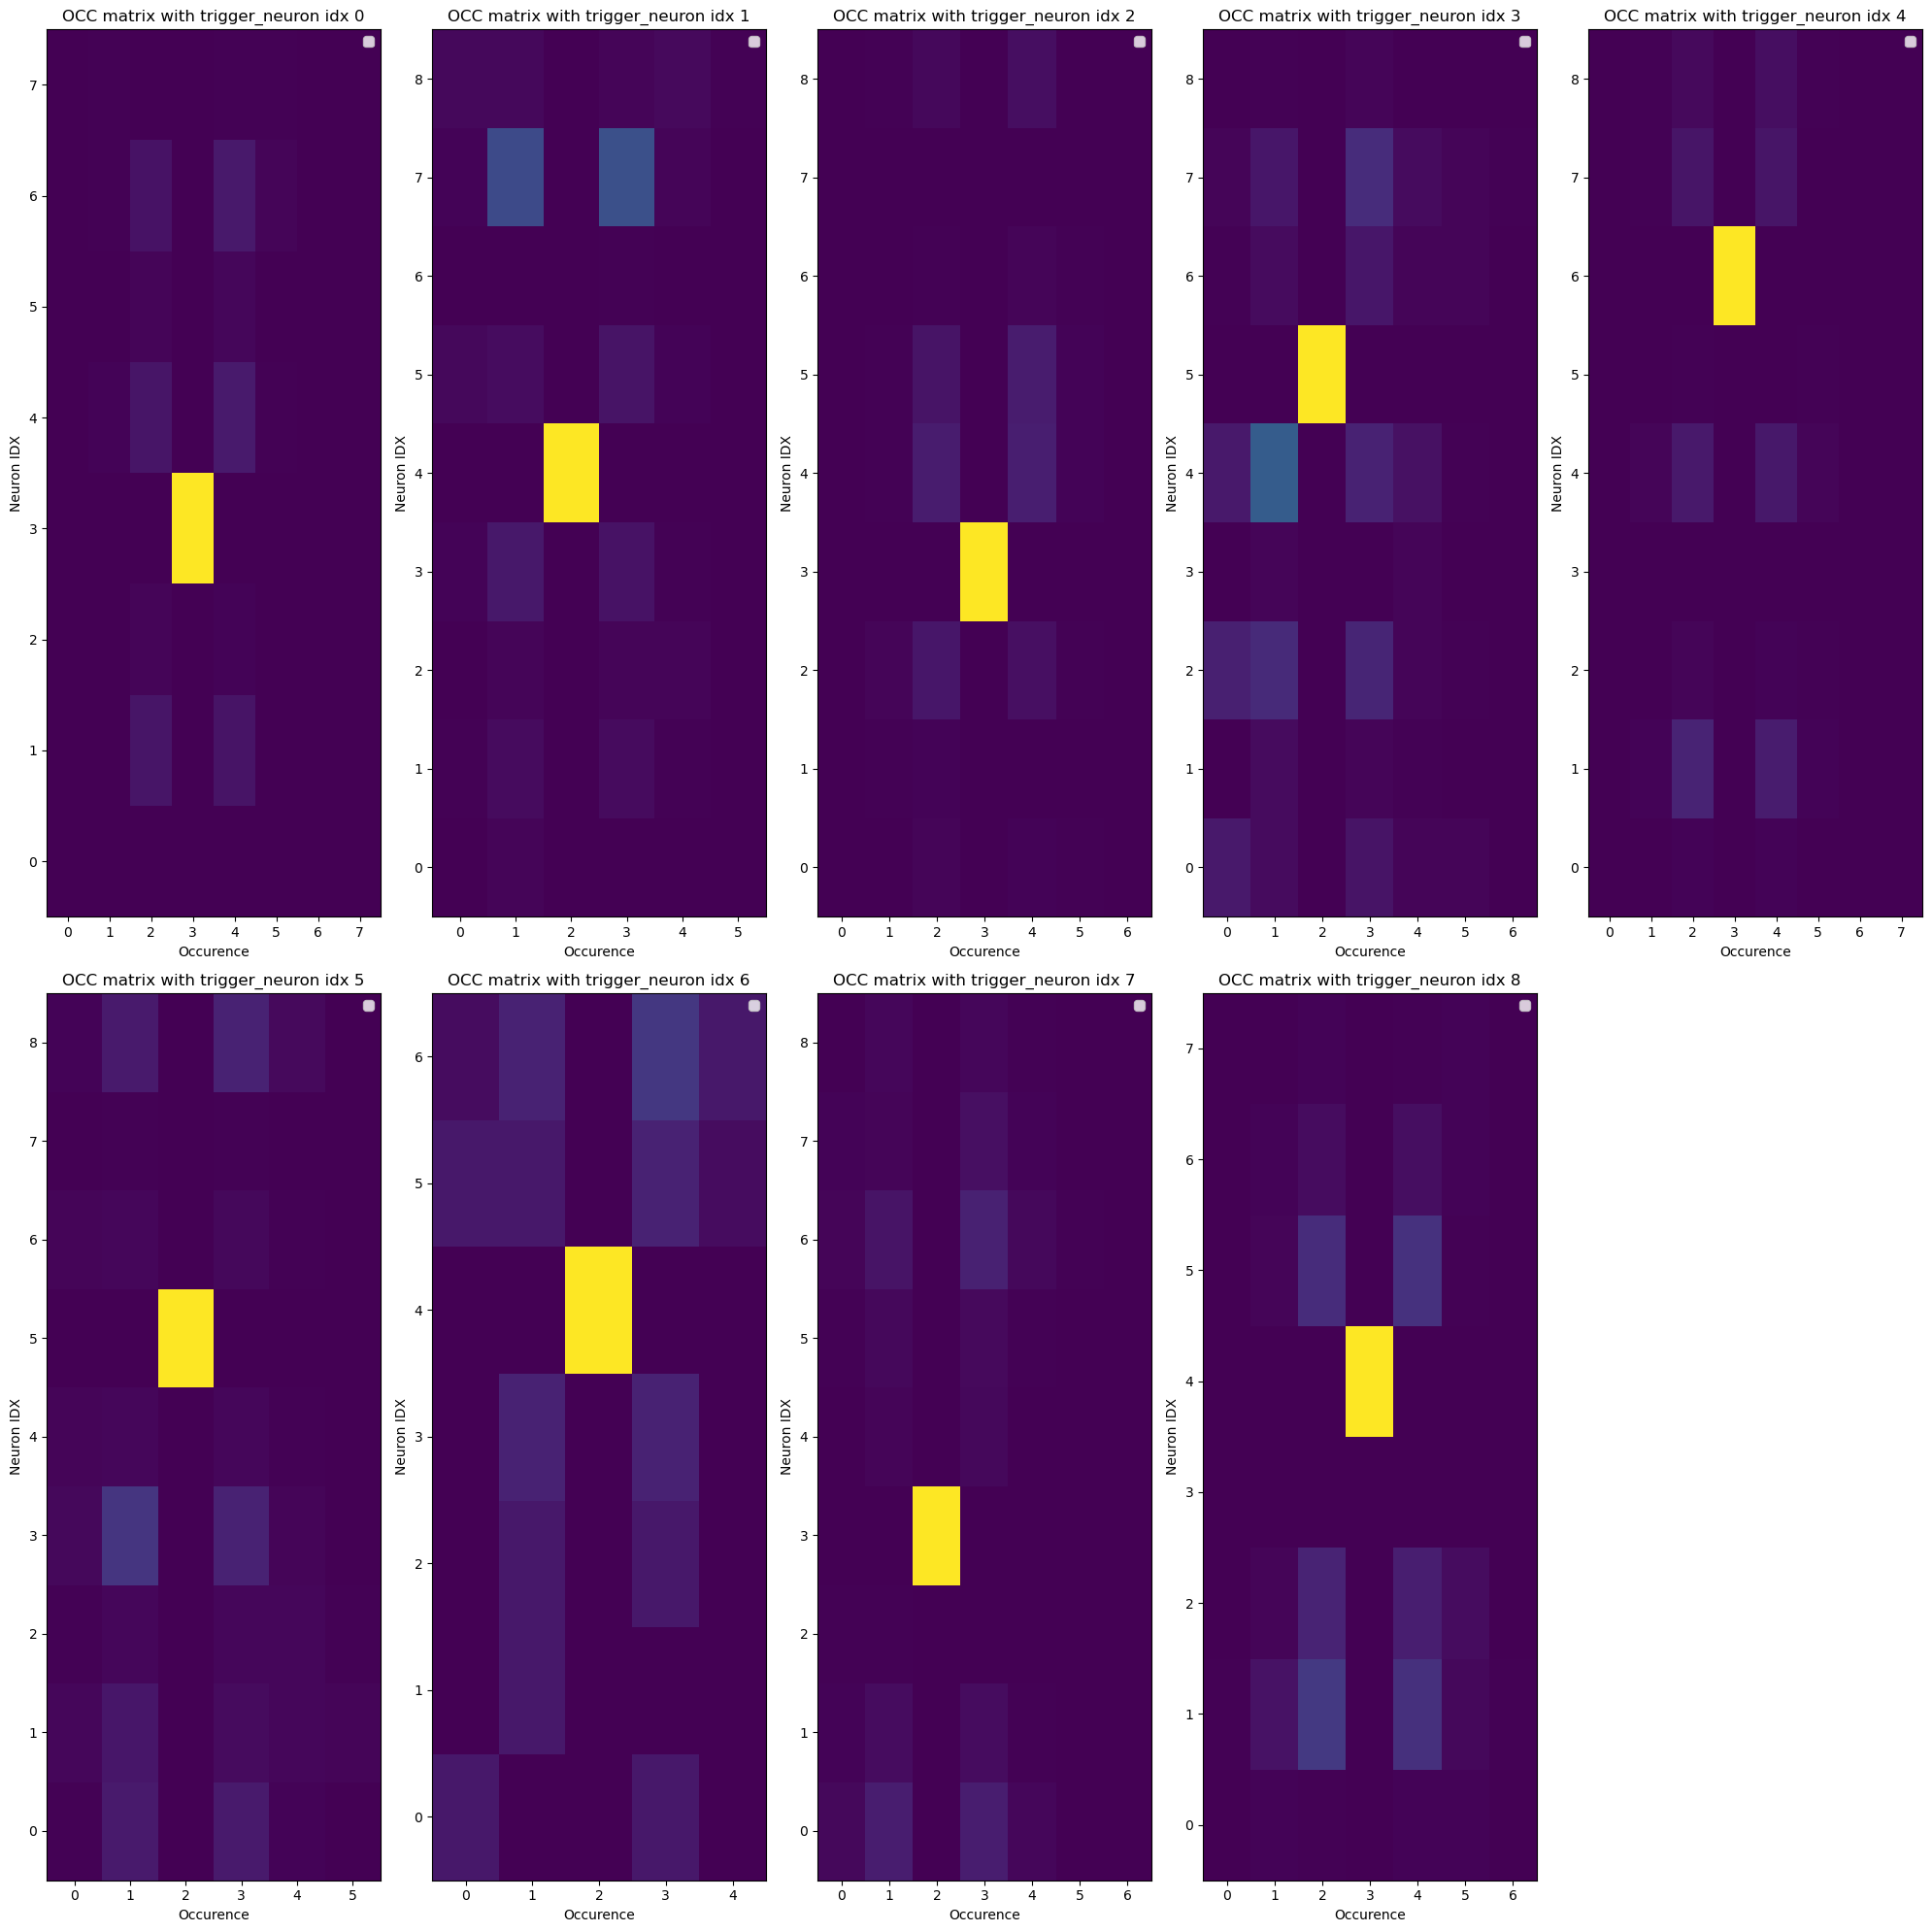

Rat10-20140702


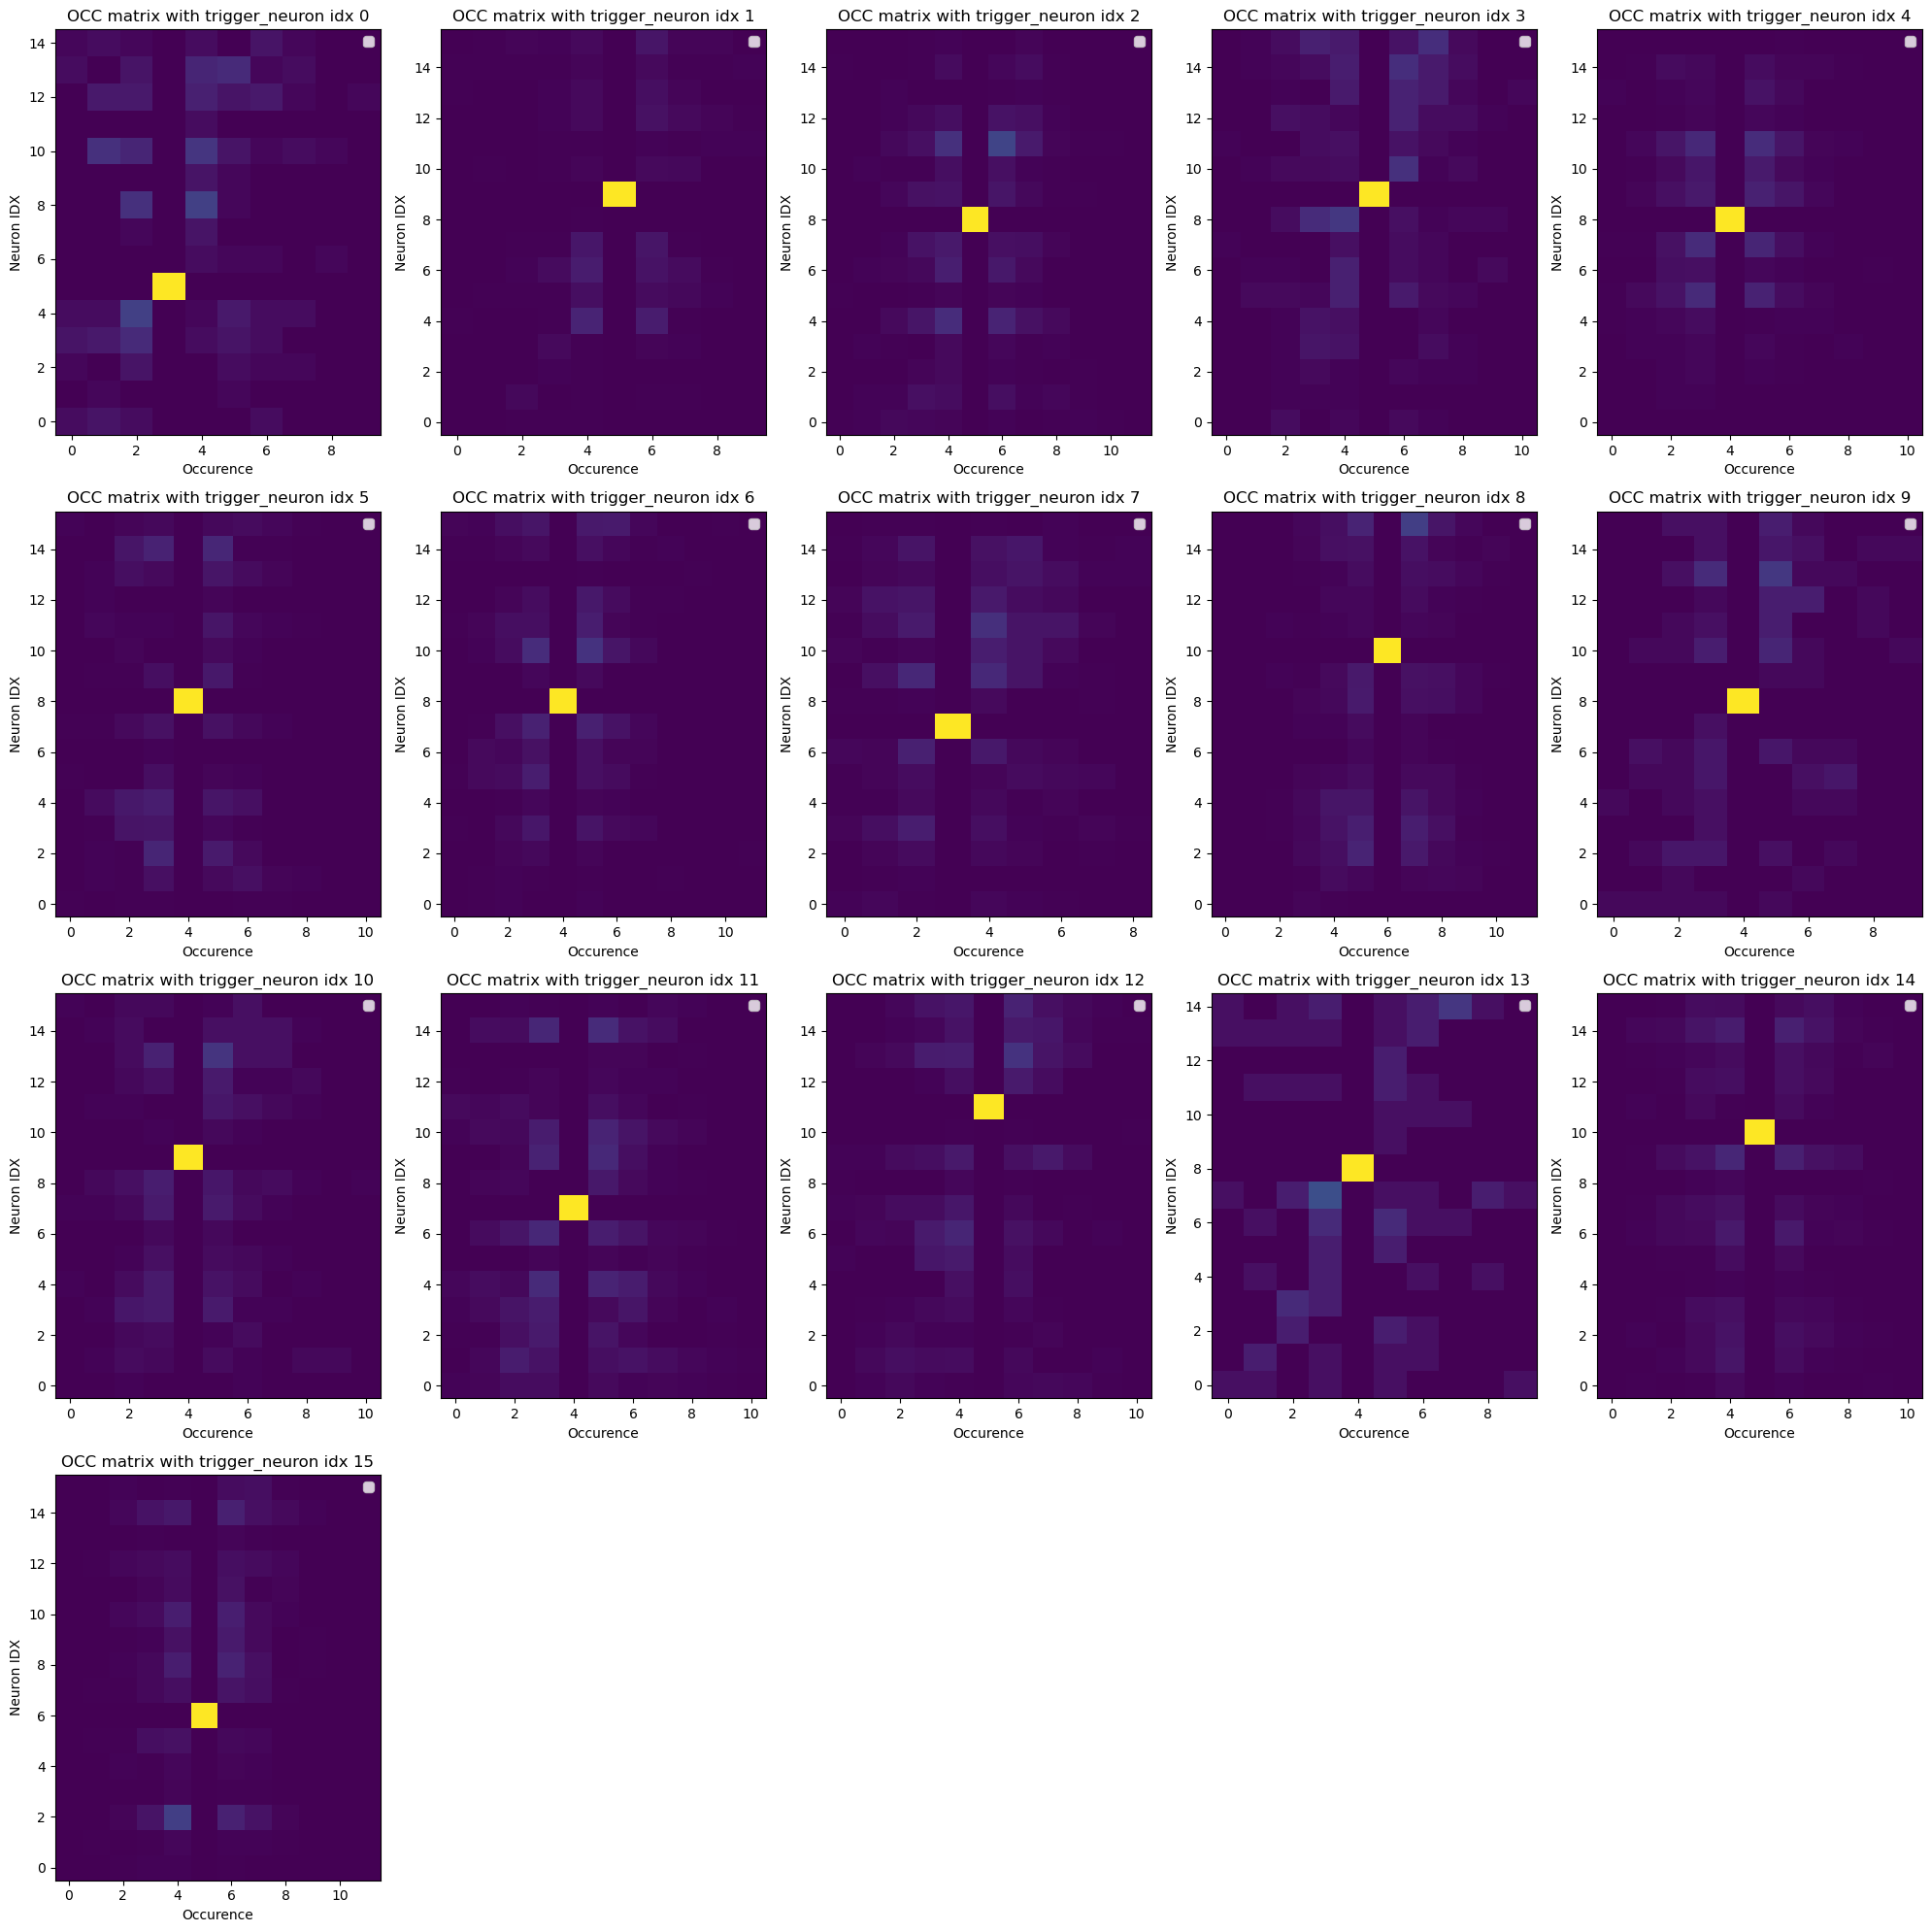

Rat10-20140703


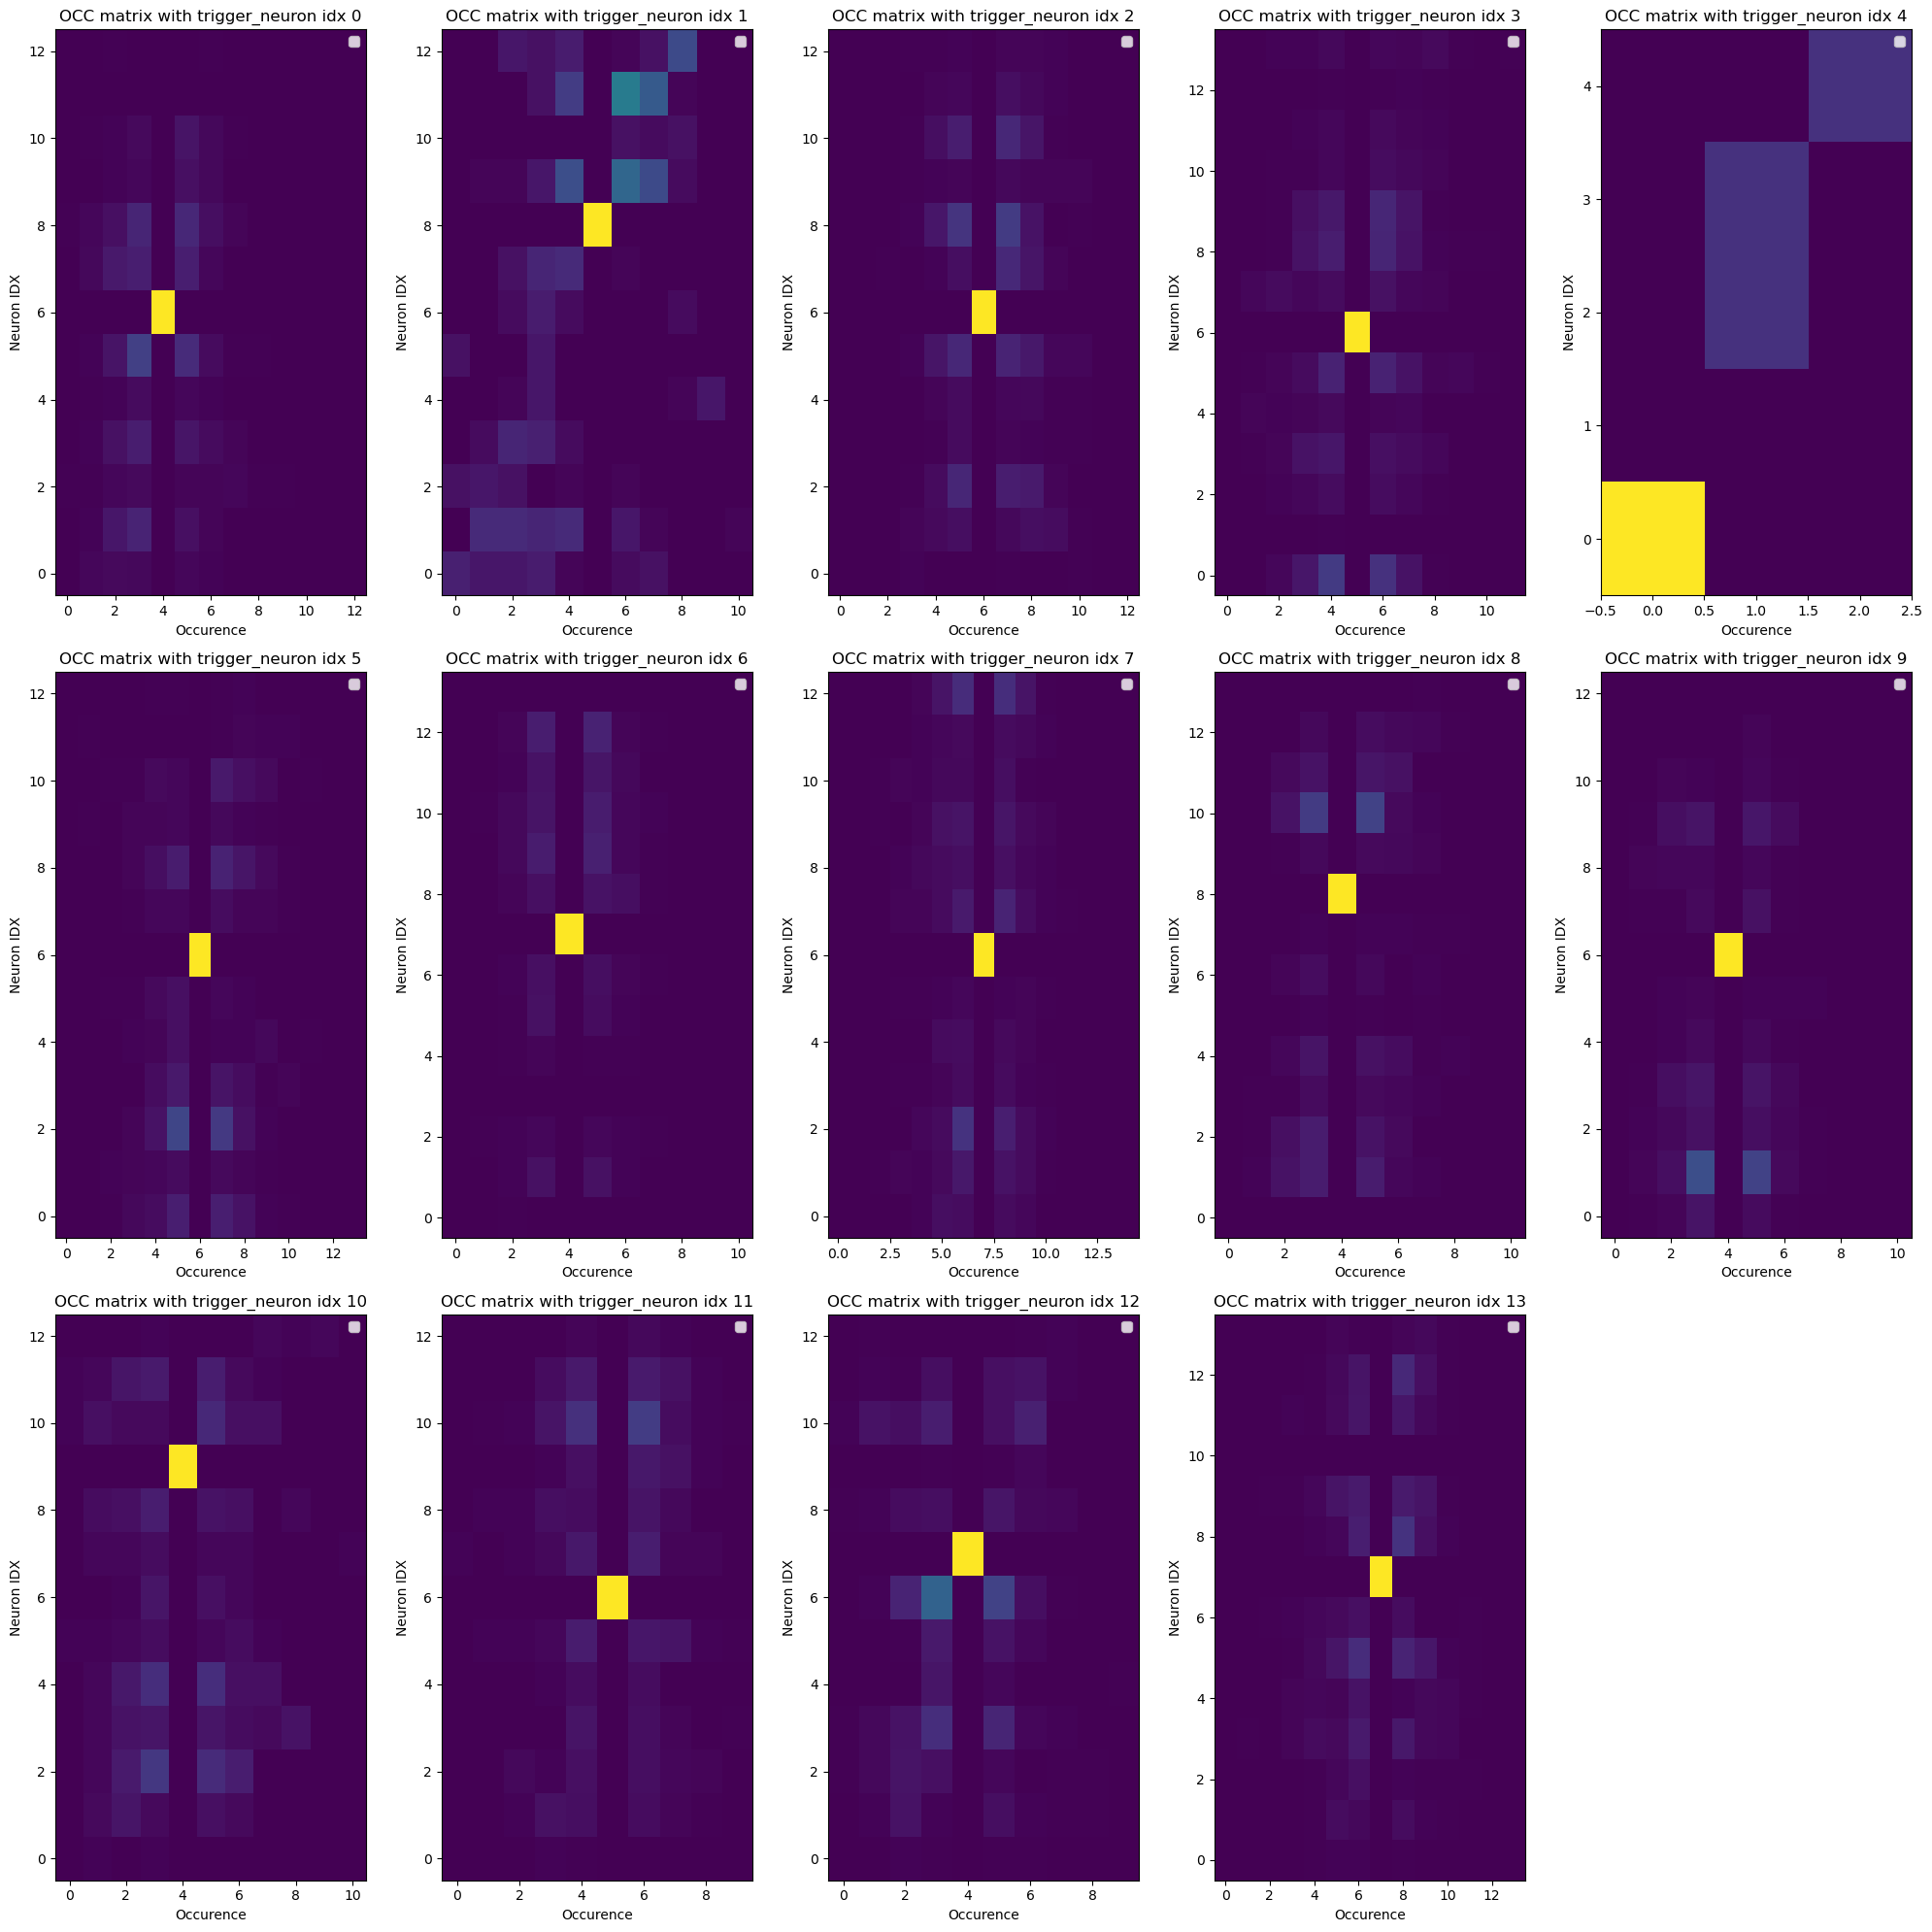

Rat10-20140707


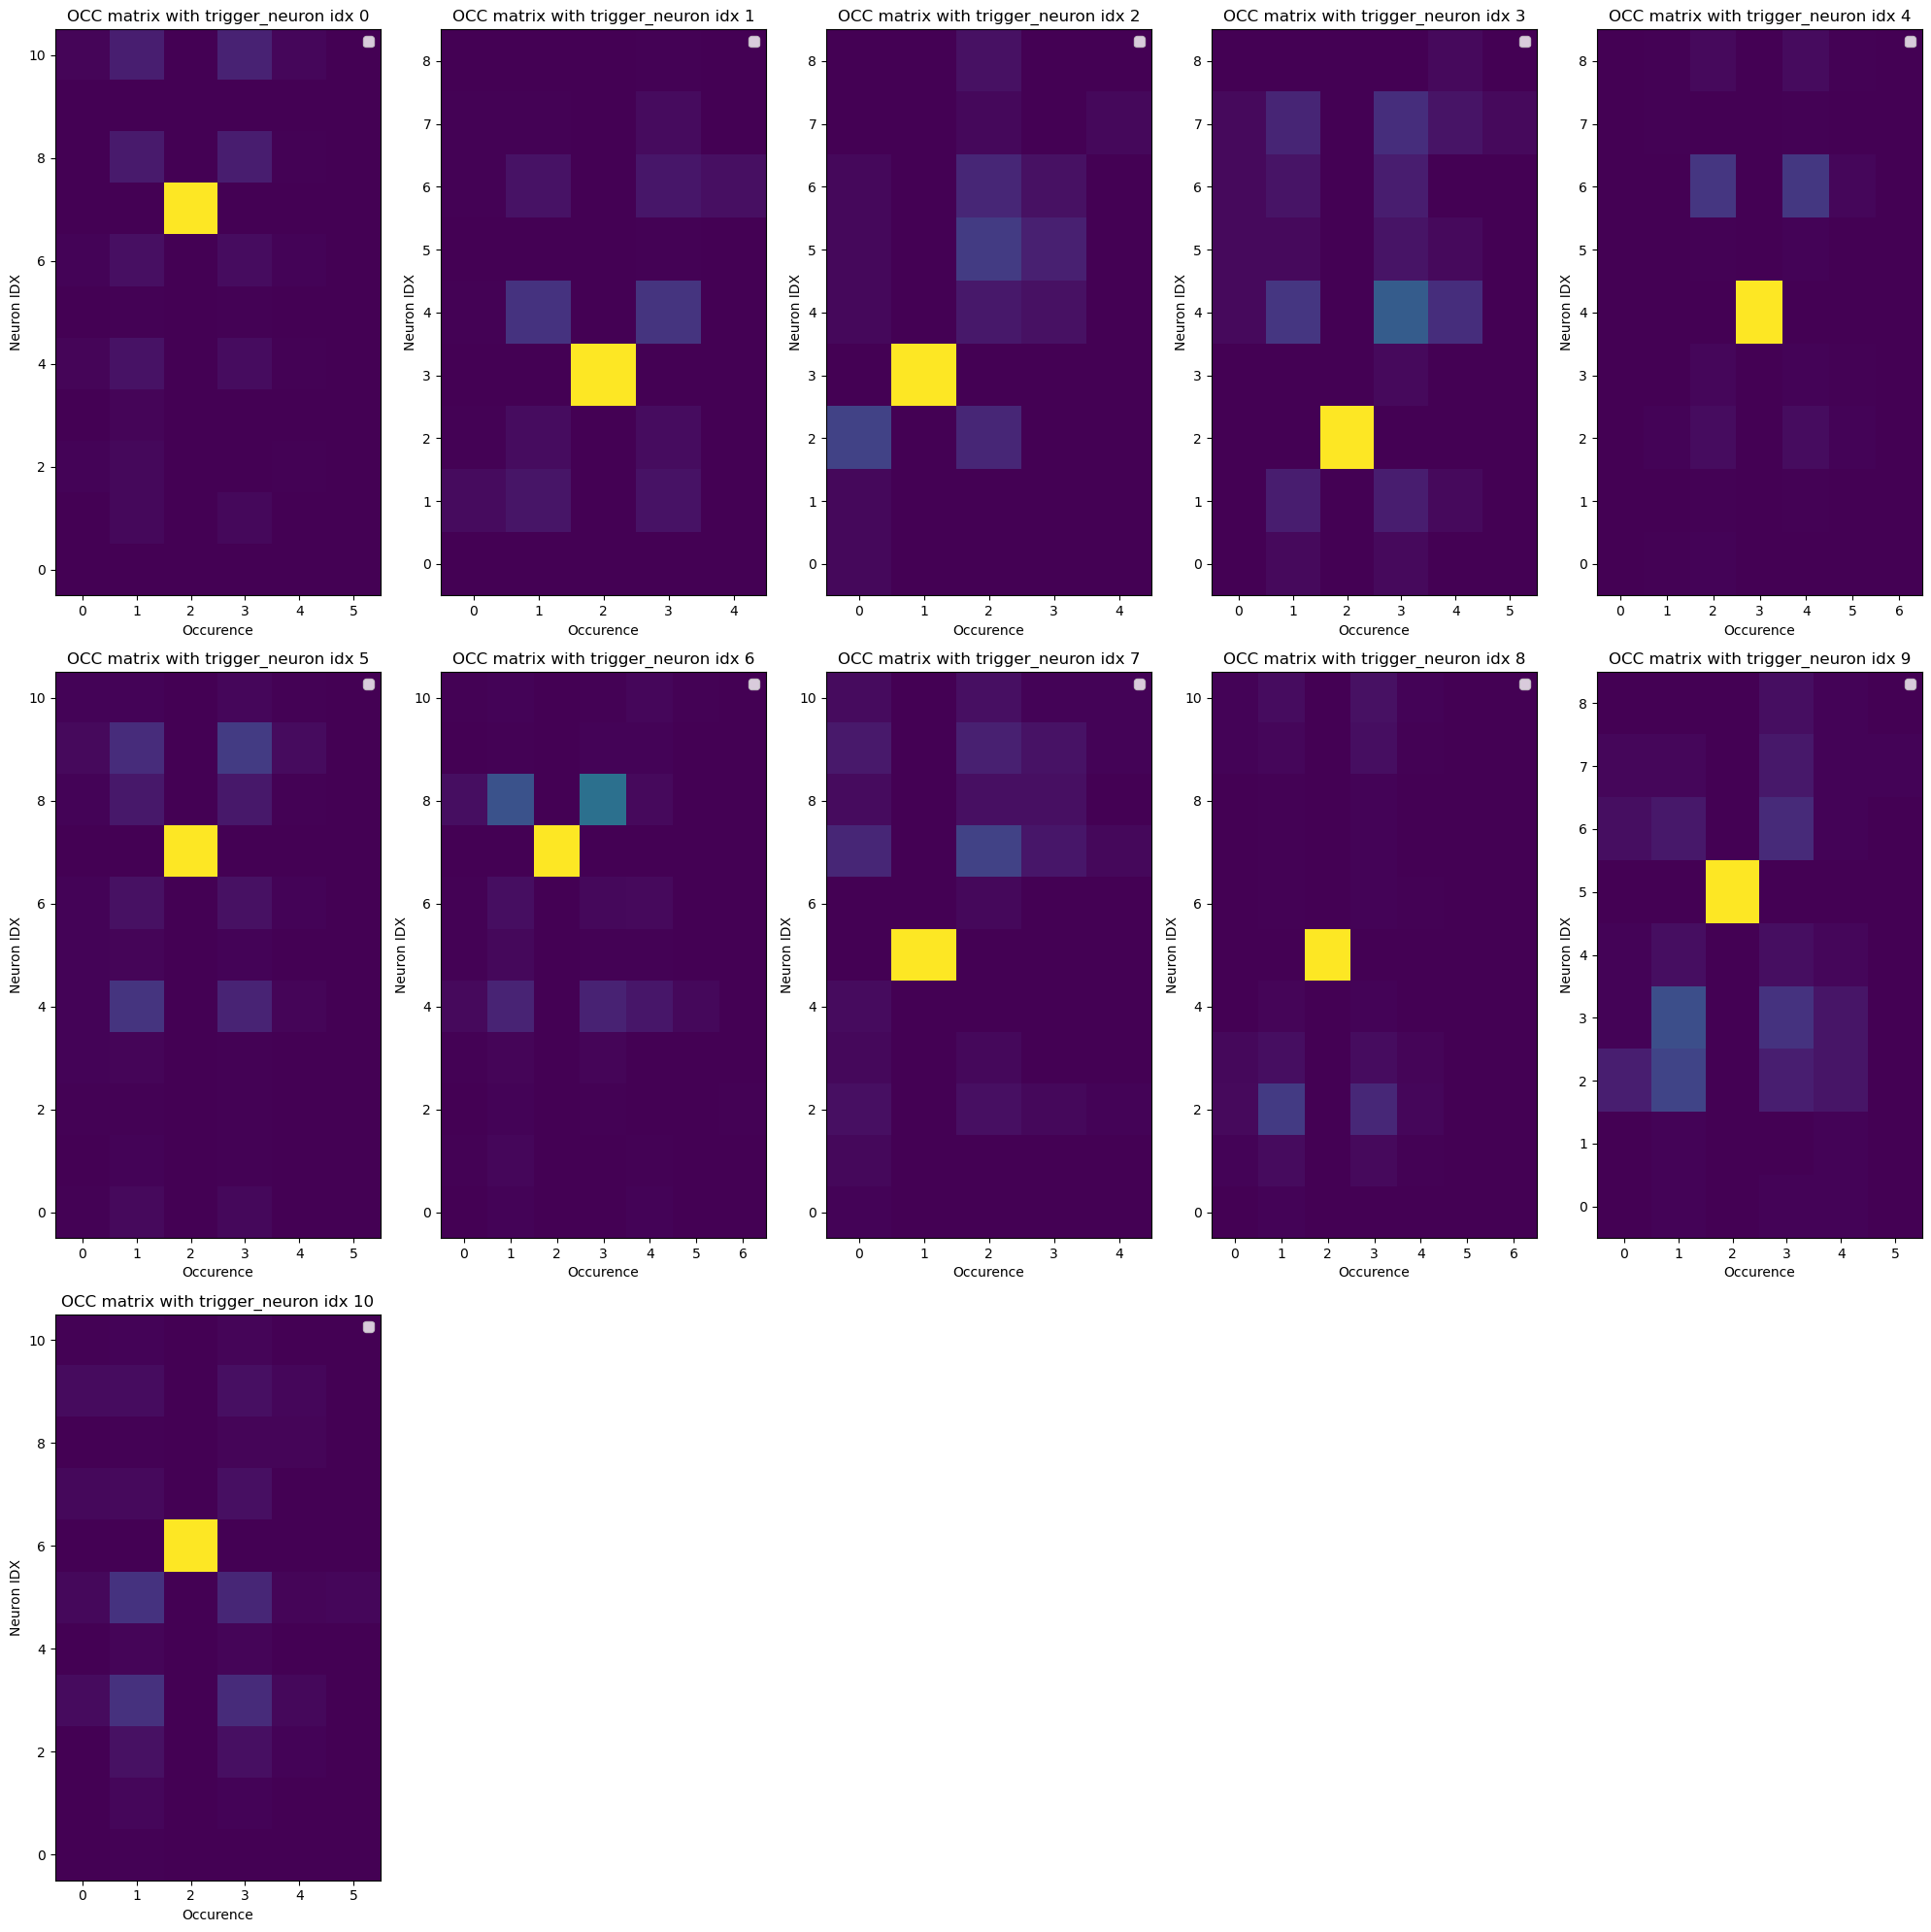

Rat10-20140708


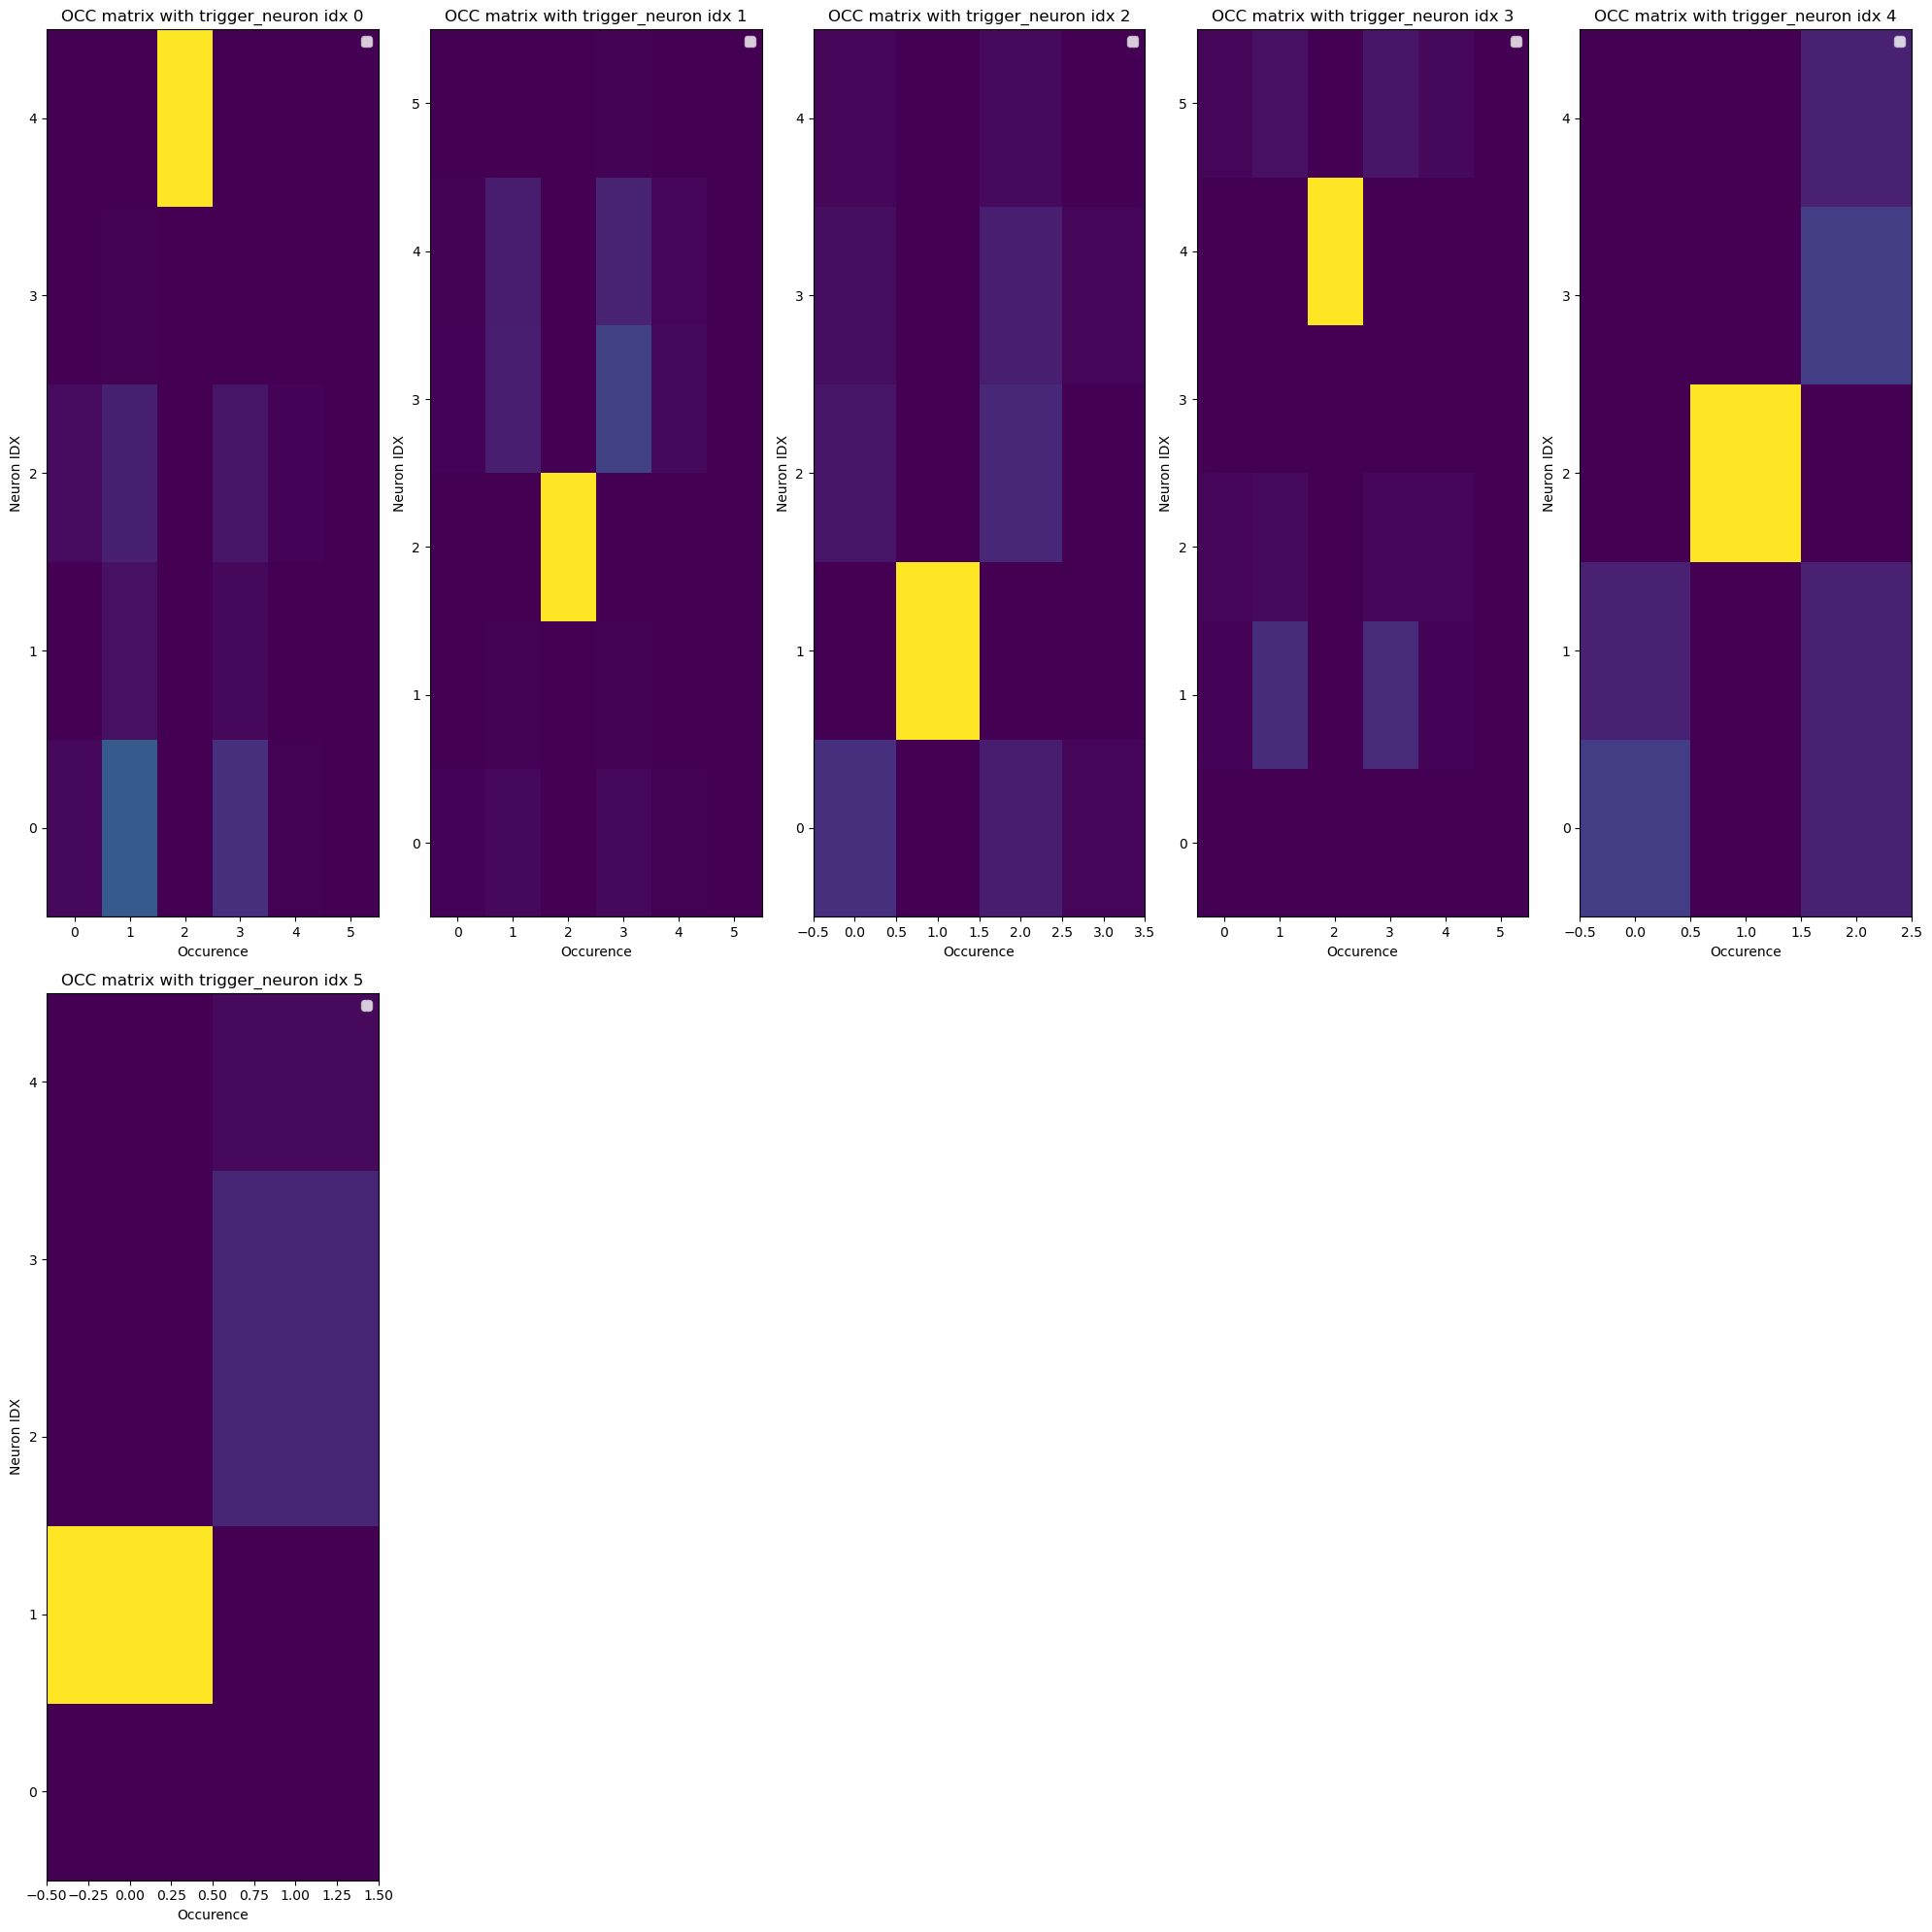

In [38]:
for session, matrices in results_per_session_rat10_third_split.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    print(session)
    def plot_occs(occ_matrix, ax, neuron_idx):
        ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')
        ax.set_xlabel('Occurence')
        ax.set_ylabel('Neuron IDX')
        ax.set_title(f'OCC matrix with trigger_neuron idx {neuron_idx}')
        ax.legend()

    num_plots = len(occ)
    cols = 5
    rows = (num_plots + cols - 1) // cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
    axes = axes.flatten()  # Flatten to make indexing easier
    
    # Loop through and plot
    for i in range(len(occ)):
        plot_occs(occ[i], axes[i], i)
    
    # Hide unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [48]:
def plot_ranks_distribution(mean_ranks, indices, session):
    plt.figure(figsize=(10, 4))
    y_position = 0  # All points share the same y-axis value
    
    plt.scatter(mean_ranks, [y_position] * len(mean_ranks), color='blue', zorder=2)
    
    # Annotate each point with its index
    for i, (x, idx) in enumerate(zip(mean_ranks, indices)):
        plt.text(x, y_position + 0.05, f"{idx}", fontsize=6, ha='center', color='black')
    
    plt.xlabel('Rank with Highest Occurrence', fontsize=12)
    plt.title(f'Highest Occurrence Ranks of Significant Neurons for {session}', fontsize=14)
    plt.yticks([y_position], [''])  # Only one y-tick for alignment
    plt.axhline(y_position, color='gray', linestyle='--', zorder=1)  # Horizontal line for reference
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [22]:
%run Results_analysis_functions.ipynb

In [127]:
results_analysis_rat10_third_split= {}

In [128]:
for session, matrices in results_per_session_rat10_third_split.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    test_matrix = session_data_rat10_third_split[session]["test_matrix"]
    n_neurons = len(boundary)
    significant_neurons = get_significant_neurons(mi_real, boundary)
    print(session)

    if np.all(np.isnan(significant_neurons)):
        print(f'There are no significant neurons for session {session}')
        continue
       
    else: 
        rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
        print(len(indices_sig_neur))
        mean_ranks = np.nanmean(rank_distribution, axis=1)
        # plot_ranks_distribution(mean_ranks, indices_sig_neur, session)
        mean_ranks_sequence, neurons_idx_sequence = mean_ranks_to_seq(mean_ranks, indices_sig_neur)
    
        pattern_template_ = create_occ_pattern_template(occ, significant_neurons, neurons_idx_sequence)
        #slice it to the number of neurons
        pattern_template = pattern_template_[:n_neurons]
        values_first_half, time_points_first_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = True)
        values_second_half, time_points_second_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = False)
        
        results_analysis_rat10_third_split[session] = {
        "pattern_template": pattern_template,
        "values_first_half": values_first_half,
        "time_points_first_half": time_points_first_half,
        "time_points_second_half": time_points_second_half,
        "values_second_half" : values_second_half
        }
    

Rat10-20140622
26
Test run 1: 524 empty spike matrices out of 889 total time points. Fraction of empty: 0.5894
Test run 2: 827 empty spike matrices out of 1198 total time points. Fraction of empty: 0.6903
Test run 3: 1787 empty spike matrices out of 3166 total time points. Fraction of empty: 0.5644
Test run 4: 1085 empty spike matrices out of 2105 total time points. Fraction of empty: 0.5154
Test run 5: 1432 empty spike matrices out of 2325 total time points. Fraction of empty: 0.6159
Test run 6: 2339 empty spike matrices out of 3010 total time points. Fraction of empty: 0.7771
Test run 7: 2268 empty spike matrices out of 2402 total time points. Fraction of empty: 0.9442
Test run 8: 3821 empty spike matrices out of 4028 total time points. Fraction of empty: 0.9486
Test run 9: 1403 empty spike matrices out of 1577 total time points. Fraction of empty: 0.8897
Test run 10: 3474 empty spike matrices out of 4144 total time points. Fraction of empty: 0.8383
Test run 11: 1840 empty spike matr

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6350/1199866095.py:18: RuntimeWarning: Mean of empty slice
  mean_ranks = np.nanmean(rank_distribution, axis=1)


Test run 2: 278 empty spike matrices out of 417 total time points. Fraction of empty: 0.6667
Test run 3: 300 empty spike matrices out of 446 total time points. Fraction of empty: 0.6726
Test run 4: 307 empty spike matrices out of 411 total time points. Fraction of empty: 0.7470
Test run 5: 279 empty spike matrices out of 421 total time points. Fraction of empty: 0.6627
Test run 6: 231 empty spike matrices out of 432 total time points. Fraction of empty: 0.5347
Test run 7: 213 empty spike matrices out of 287 total time points. Fraction of empty: 0.7422
Test run 8: 289 empty spike matrices out of 343 total time points. Fraction of empty: 0.8426
Test run 9: 229 empty spike matrices out of 297 total time points. Fraction of empty: 0.7710
Test run 10: 319 empty spike matrices out of 483 total time points. Fraction of empty: 0.6605
Test run 11: 134 empty spike matrices out of 183 total time points. Fraction of empty: 0.7322
Test run 12: 148 empty spike matrices out of 239 total time points. 

In [40]:
len_sig_neurons = []
results_analysis_rat10_middle_split_new= {}

In [41]:
with open("results_per_session_rat10_middle_split", "rb") as pkl_file:
    results_per_session_rat10_middle_split = pickle.load(pkl_file)

In [42]:
for session, matrices in results_per_session_rat10_middle_split.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    test_matrix = session_data_rat10_third_split[session]["test_matrix"]
    n_neurons = len(boundary)
    significant_neurons = get_significant_neurons(mi_real, boundary)
    print(session)

    if np.all(np.isnan(significant_neurons)):
        print(f'There are no significant neurons for session {session}')
        continue
       
    else: 
        rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
        len_sig_neurons.append((len(indices_sig_neur)))
        mean_ranks = np.nanmean(rank_distribution, axis=1)
        # plot_ranks_distribution(mean_ranks, indices_sig_neur, session)
        mean_ranks_sequence, neurons_idx_sequence = mean_ranks_to_seq(mean_ranks, indices_sig_neur)
        
        pattern_template_ = create_occ_pattern_template(occ, significant_neurons, neurons_idx_sequence)
        #slice it to the number of neurons
        pattern_template = pattern_template_[:n_neurons]
        values_first_half, time_points_first_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = True)
        values_second_half, time_points_second_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = False)
        
        results_analysis_rat10_middle_split_new[session] = {
        "pattern_template": pattern_template,
        "values_first_half": values_first_half,
        "time_points_first_half": time_points_first_half,
        "time_points_second_half": time_points_second_half,
        "values_second_half" : values_second_half,
        "significant_neurons" : significant_neurons
        }

Rat10-20140622
Test run 1: 524 empty spike matrices out of 889 total time points. Fraction of empty: 0.5894
Test run 2: 827 empty spike matrices out of 1198 total time points. Fraction of empty: 0.6903
Test run 3: 1787 empty spike matrices out of 3166 total time points. Fraction of empty: 0.5644
Test run 4: 1085 empty spike matrices out of 2105 total time points. Fraction of empty: 0.5154
Test run 5: 1432 empty spike matrices out of 2325 total time points. Fraction of empty: 0.6159
Test run 6: 2339 empty spike matrices out of 3010 total time points. Fraction of empty: 0.7771
Test run 7: 2268 empty spike matrices out of 2402 total time points. Fraction of empty: 0.9442
Test run 8: 3821 empty spike matrices out of 4028 total time points. Fraction of empty: 0.9486
Test run 9: 1403 empty spike matrices out of 1577 total time points. Fraction of empty: 0.8897
Test run 10: 3474 empty spike matrices out of 4144 total time points. Fraction of empty: 0.8383
Test run 11: 1840 empty spike matrice

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_76624/1952033128.py:18: RuntimeWarning: Mean of empty slice
  mean_ranks = np.nanmean(rank_distribution, axis=1)


Test run 1: 374 empty spike matrices out of 530 total time points. Fraction of empty: 0.7057
Test run 2: 278 empty spike matrices out of 417 total time points. Fraction of empty: 0.6667
Test run 3: 300 empty spike matrices out of 446 total time points. Fraction of empty: 0.6726
Test run 4: 307 empty spike matrices out of 411 total time points. Fraction of empty: 0.7470
Test run 5: 279 empty spike matrices out of 421 total time points. Fraction of empty: 0.6627
Test run 6: 231 empty spike matrices out of 432 total time points. Fraction of empty: 0.5347
Test run 7: 213 empty spike matrices out of 287 total time points. Fraction of empty: 0.7422
Test run 8: 289 empty spike matrices out of 343 total time points. Fraction of empty: 0.8426
Test run 9: 229 empty spike matrices out of 297 total time points. Fraction of empty: 0.7710
Test run 10: 319 empty spike matrices out of 483 total time points. Fraction of empty: 0.6605
Test run 11: 134 empty spike matrices out of 183 total time points. F

### Example session with outlier values

In [ ]:
session_id_outlier = 'Rat10-20140708'
values_first_half_ol = results_analysis_rat10_middle_split_new["Rat10-20140708"]["values_first_half"]
time_points_first_half_ol = results_analysis_rat10_middle_split_new["Rat10-20140708"]["time_points_first_half"]
values_second_half_ol = results_analysis_rat10_middle_split_new["Rat10-20140708"]["values_second_half"]
time_points_second_half_ol = results_analysis_rat10_middle_split_new["Rat10-20140708"]["time_points_second_half"]

In [139]:
# plot_values_overlaid(values_first_half_ol, time_points_first_half_ol, values_second_half_ol, time_points_second_half_ol )
mean_first_half_value_ol, mean_second_half_value_ol = np.nanmean(values_first_half_ol, axis=1), np.nanmean(values_second_half_ol, axis=1) 
# plot_means_test_runs_means(mean_first_half_value_ol, mean_second_half_value_ol)

mean_first_half_value_og, mean_second_half_value_og = np.nanmean(mean_first_half_value_ol), np.nanmean(mean_second_half_value_ol)
print((mean_first_half_value_og, mean_second_half_value_og))
mean_first_half_value_og, mean_second_half_value_og = np.array(mean_first_half_value_og), np.array(mean_second_half_value_og)



(30.219909047377737, 17.917365581914925)


### Example significant session

In [113]:
session_id_sig = 'Rat10-20140628'
values_first_half_sig = results_analysis_rat10_middle_split_new["Rat10-20140628"]["values_first_half"]
time_points_first_half_sig = results_analysis_rat10_middle_split_new["Rat10-20140628"]["time_points_first_half"]
values_second_half_sig = results_analysis_rat10_middle_split_new["Rat10-20140628"]["values_second_half"]
time_points_second_half_sig = results_analysis_rat10_middle_split_new["Rat10-20140628"]["time_points_second_half"]

In [126]:
# plot_values_overlaid(values_first_half_ol, time_points_first_half_ol, values_second_half_ol, time_points_second_half_ol )
means_first_half_value_sig, means_second_half_value_sig = np.nanmean(values_first_half_sig, axis=1), np.nanmean(values_second_half_sig, axis=1) 
# plot_means_test_runs_means(mean_first_half_value_ol, mean_second_half_value_ol)
mean_first_half_value_sig, mean_second_half_value_sig = np.nanmean(mean_first_half_value_sig), np.nanmean(mean_second_half_value_sig)
print(mean_first_half_value_sig, mean_second_half_value_sig)

# plot_paired_scatter_no_jitter(means_first_half_value_sig, means_second_half_value_sig)
index_sig = np.where(means_second_half_value_sig > 8)
print(index_sig)
# plot_paired_scatter_no_jitter(mean_first_half_value_ol, mean_second_half_value_ol)
means_first_half_value_sig = np.delete(means_first_half_value_sig, index_sig)
means_second_half_value_sig = np.delete(means_second_half_value_sig, index_sig)
plt.savefig("Highlighted_significant_means.svg")
plt.close()

plot_paired_scatter_no_jitter(means_first_half_value_sig, means_second_half_value_sig)
plt.savefig("Highlighted_significant_means.svg")
plt.close()

mean_first_half_value_og, mean_second_half_value_og = np.array(mean_first_half_value_og), np.array(mean_second_half_value_og)

# plot_elementwise_differences_boxplot(mean_first_half_value_ol, mean_second_half_value_ol)
# plt.figure()
# plt.boxplot([mean_first_half_value_ol, mean_second_half_value_ol], labels=["First Half", "Second Half"], patch_artist=True, 
#             boxprops=dict(facecolor="blue", alpha=0.5), medianprops=dict(color="red"), showfliers=False)
# plt.ylabel("Values")
# plt.title("Value Distribution for First and Second Halves")
# plt.show()


2.239504079925636 1.349987107540119
(array([0]),)


In [125]:
plot_mean_run(values_first_half_sig, time_points_first_half_sig,
    values_second_half_sig, time_points_second_half_sig)
plt.savefig("Highlighted_significant_projection.svg")
plt.close()

In [ ]:
rat10_across_sessions = {}

In [191]:
for session, matrices in results_analysis_rat10_middle_split.items():
    values_first_half = matrices["values_first_half"]
    values_second_half = matrices["values_second_half"]
    signif_neurons = matrices["significant_neurons"]
    rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
    number_signif = len (indices_sig_neur)
    ratio_signif = number_signif/len(signif_neurons)
    
    # plot_means_first_second_half(values_first_half, values_second_half)
    mean_first_half_value, mean_second_half_value = np.nanmean(values_first_half, axis=1), np.nanmean(values_second_half, axis=1) 
    mean_first_half =  np.nanmean(mean_first_half_value)
    mean_second_half =  np.nanmean(mean_second_half_value)
    difference = mean_first_half - mean_second_half
    
    stat, p_value = wilcoxon(mean_first_half_value, mean_second_half_value)

    rat10_across_sessions[session] = {
    "ratio_signif_neurons": ratio_signif,
    "significance_neurons": signif_neurons,
    "indices_significant": indices_sig_neur,
    "means_first_middle": mean_first_half,
    "means_second_middle": mean_second_half,
    "difference": difference,
    "mean_first_half_value": mean_first_half_value,
    "mean_second_half_value": mean_second_half_value,
    "wilcoxon_stat_in_session": stat,
    "wilcoxon_p_in_session": p_value
    }

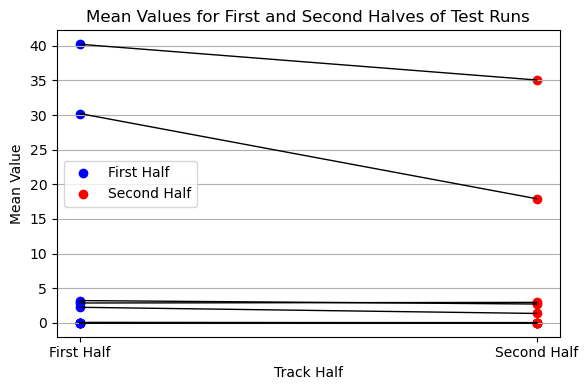

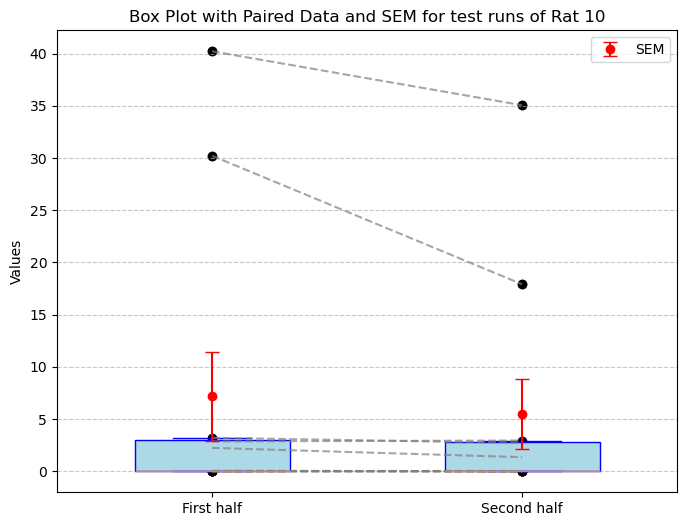

Wilcoxon test statistic: 12.0, p-value: 0.0673828125


In [146]:
plot_means_test_runs_means(means_first_middle, means_second_middle)
boxplot_sem_means(means_first_middle, means_second_middle)
paired_test_mean(means_first_middle, means_second_middle)

In [147]:
import pickle
# Save to file
with open("rat10_means_third_first.pkl", "wb") as pkl_file:
    pickle.dump(means_first_third, pkl_file)

with open("rat10_means_third_second.pkl", "wb") as pkl_file:
    pickle.dump(means_second_third, pkl_file)

with open("rat10_means_middle_first.pkl", "wb") as pkl_file:
    pickle.dump(means_first_middle, pkl_file)

with open("rat10_means_middle_second.pkl", "wb") as pkl_file:
    pickle.dump(means_second_middle, pkl_file)

In [198]:
with open("rat10_results_third_split ", "wb") as pkl_file:
    pickle.dump(results_per_session_rat10_third_split, pkl_file)

with open("rat10_results_middle_split", "wb") as pkl_file:
    pickle.dump(results_per_session_rat10_middle_split, pkl_file)

In [192]:
with open("rat10_results_across_sessions", "wb") as pkl_file:
    pickle.dump(rat10_across_sessions, pkl_file)

In [195]:
with open("results_per_session_rat10_middle_split", "wb") as pkl_file:
    pickle.dump(results_per_session_rat10_middle_split, pkl_file)

In [197]:
with open("rat_10_session_data_middle_split", "wb") as pkl_file:
    pickle.dump(session_data_rat10_middle_split, pkl_file)


In [4]:
import pickle
with open("rat10_results_across_sessions", "rb") as pkl_file:
    rat10_results_across_sessions= pickle.load(pkl_file)
with open("results_per_session_rat10_middle_split", "rb") as pkl_file:
    results_per_session_rat10_middle_split = pickle.load(pkl_file)